# Example 5 Business: Recovery of Alameda Island businesses using R2D damage estimates and third-party infrastructure simulators.

This notebook runs the Alameda Island business resilience simulation. It extends Example 5 with business impact modelling, tracking revenue losses caused by building damage, infrastructure outages, employee availability, local supplier access, and customer base disruption.

Example 5 shows how **pyrecodes** extends NHERI R2D's damage assessment to simulate recovery and integrate third-party infrastructure simulators of water supply systems and transportation systems to assess their interdependencies. Sparse distribution time stepping is used. 

Please refer to the **pyrecodes** [Example 5 page](https://nikolablagojevic.github.io/pyrecodes/html/usage/examples/example_5.html) for further details.

In [1]:
from pyrecodes import main

system = main.run('./Example 5_business/Alameda_Main.json')

system.calculate_resilience()

Removing 4 isolated node(s) not in the largest strongly connected component: {2072, 2071, 2046, 2047}
Time step:  0
Time step:  1
Time step:  2
Time step:  3
Time step:  4
Time step:  5
Time step:  6
Time step:  7
Time step:  8
Time step:  9
Time step:  10
Time step:  11
Time step:  12
Time step:  13
Time step:  14
Time step:  15
Time step:  16
Time step:  17
Time step:  18
Time step:  19
Re-CoDeS Resilience Calculator 
Scope: All
----------------------------- 
Total unmet demand: 
 Shelter: 49192.0
 PotableWater: 0.0
 PlanCheckEngineeringTeam: 0.0
 Money: 0.0
 RepairCrew_Buildings: 589726.0
 RepairCrew_Transportation: 0.0
 RepairCrew_Water: 6348.0
 TransportationService: 83138
 Employee: 0
 InputCommodity: 0

Component Recovery Time Calculator 
-------------------------------- 
EmergencyResponseCenter | AIM ID: None: 0
DS2_Roadway | AIM ID: 317: 10
DS3_Roadway | AIM ID: 372: inf
DS0_Roadway | AIM ID: 373: 0
DS2_Roadway | AIM ID: 374: 10
DS2_Roadway | AIM ID: 375: 10
DS1_Roadway | AIM 

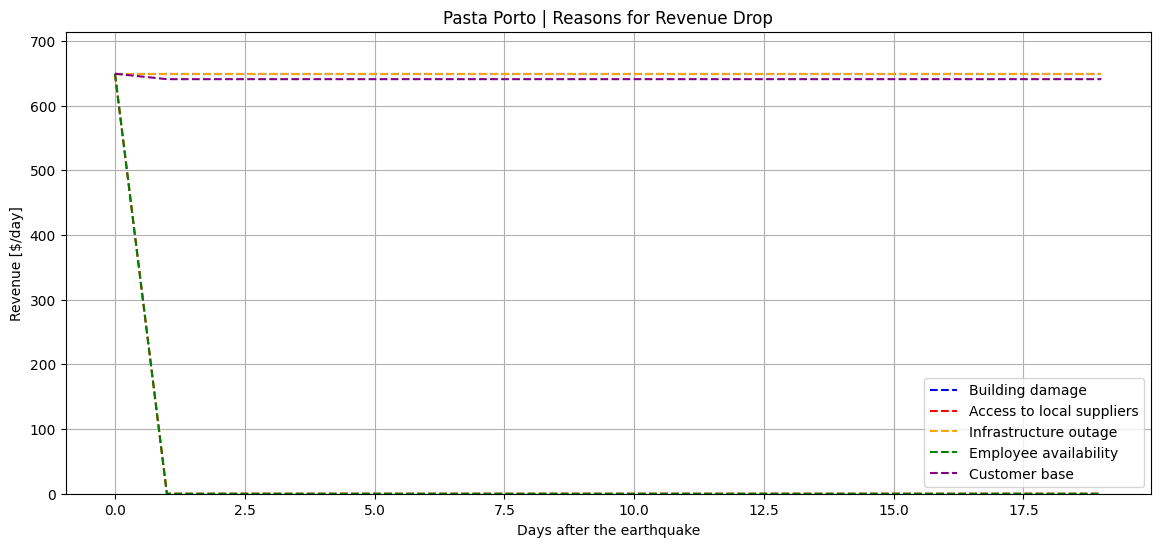

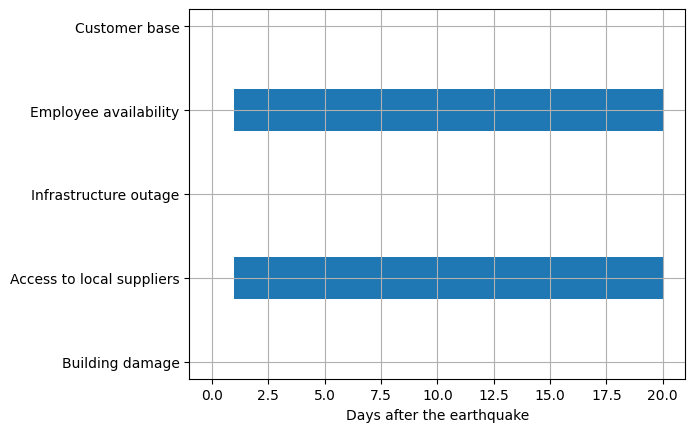

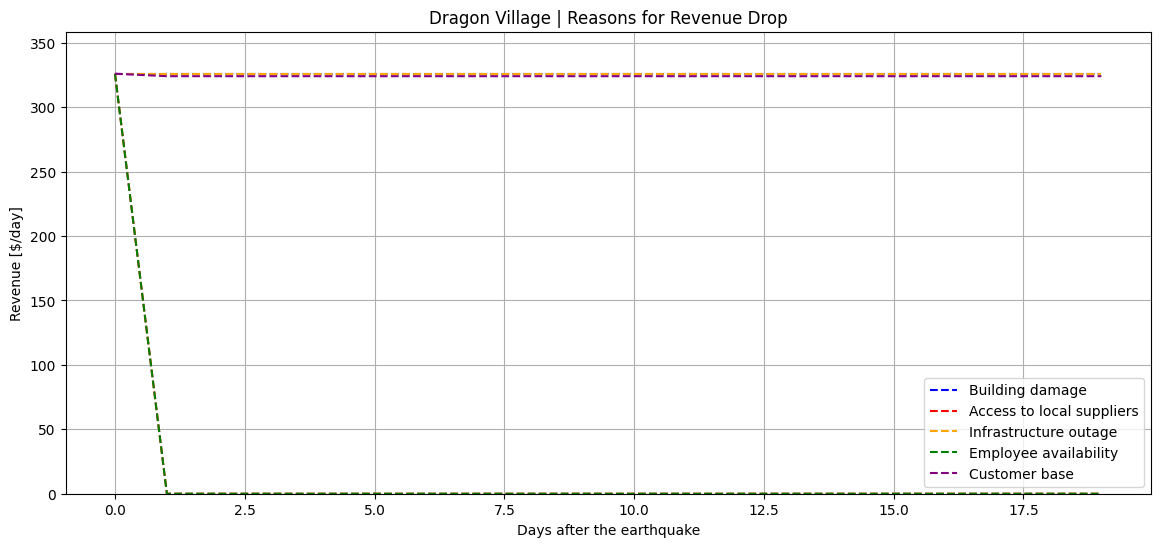

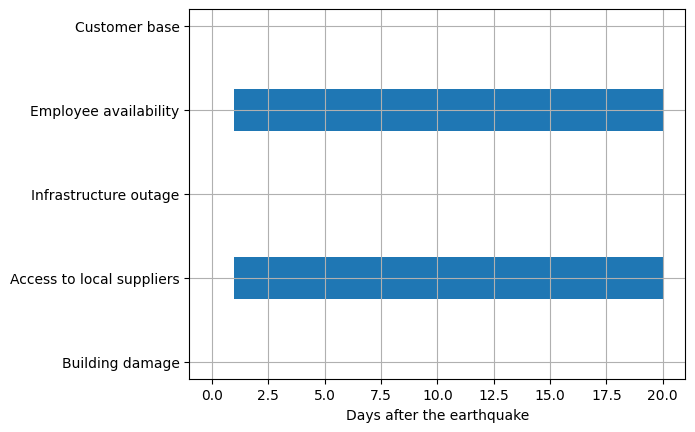

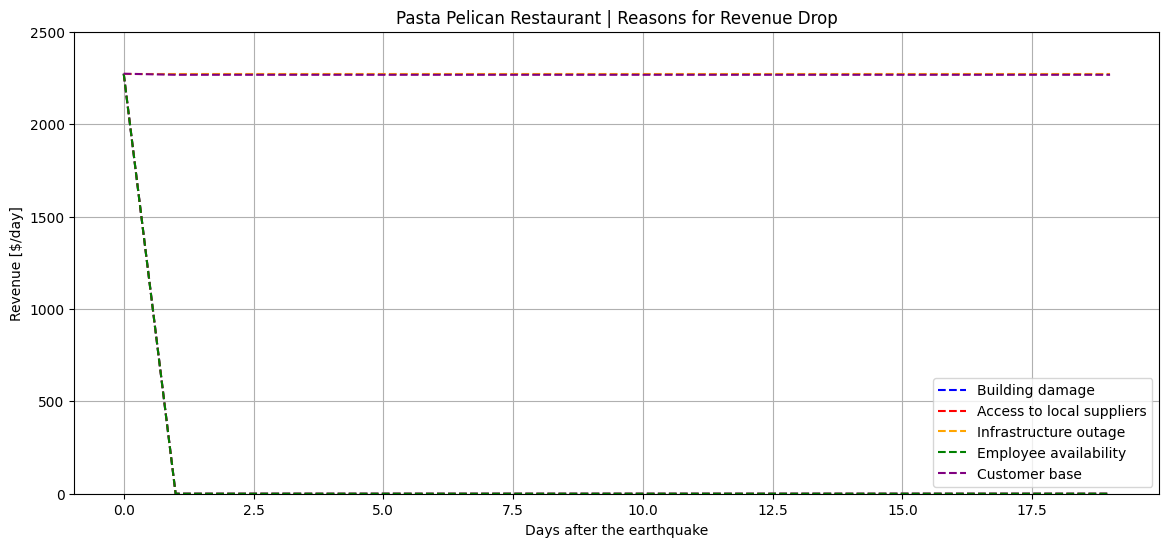

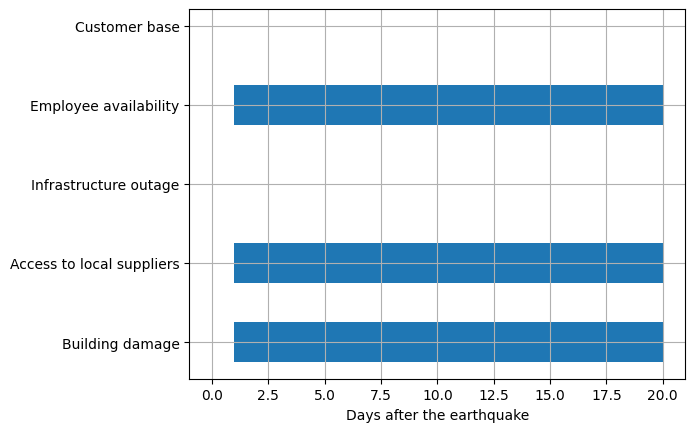

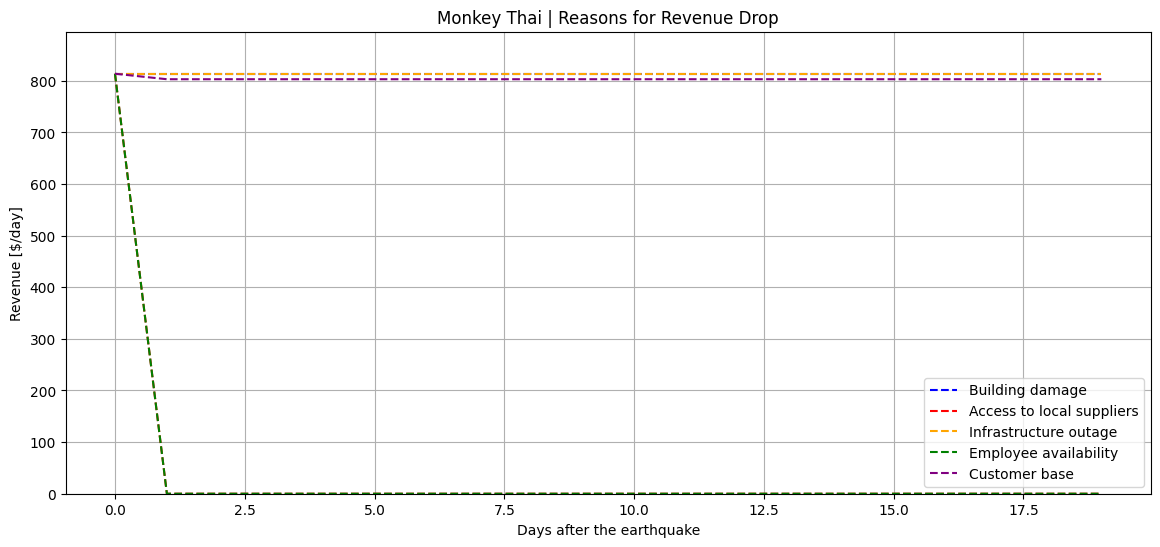

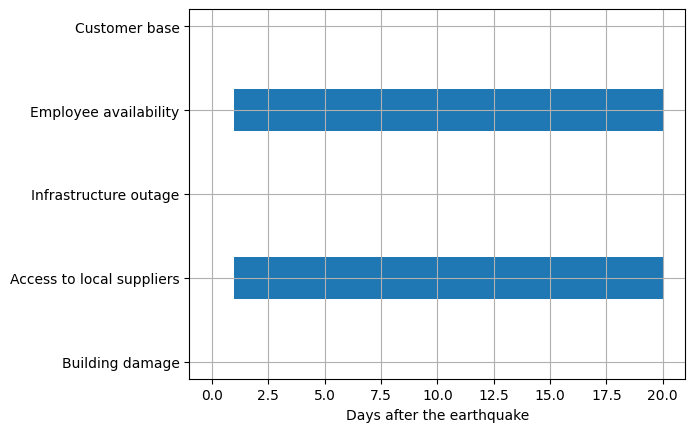

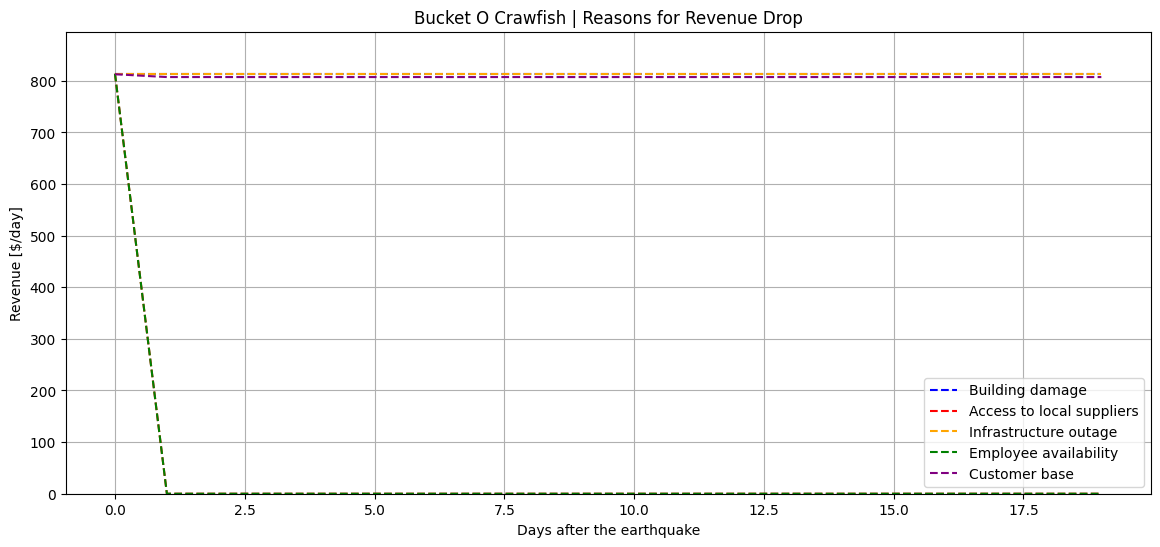

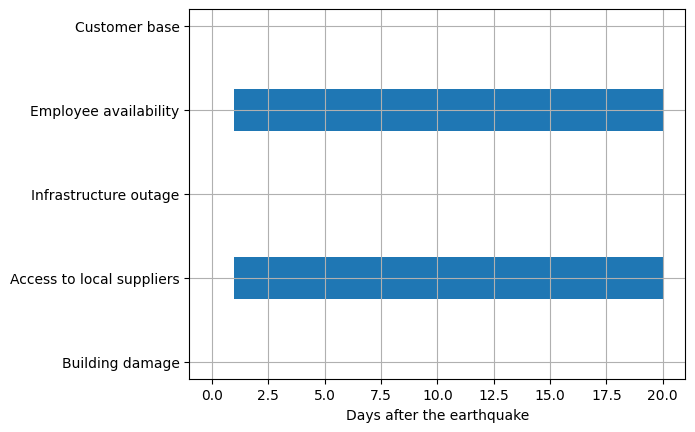

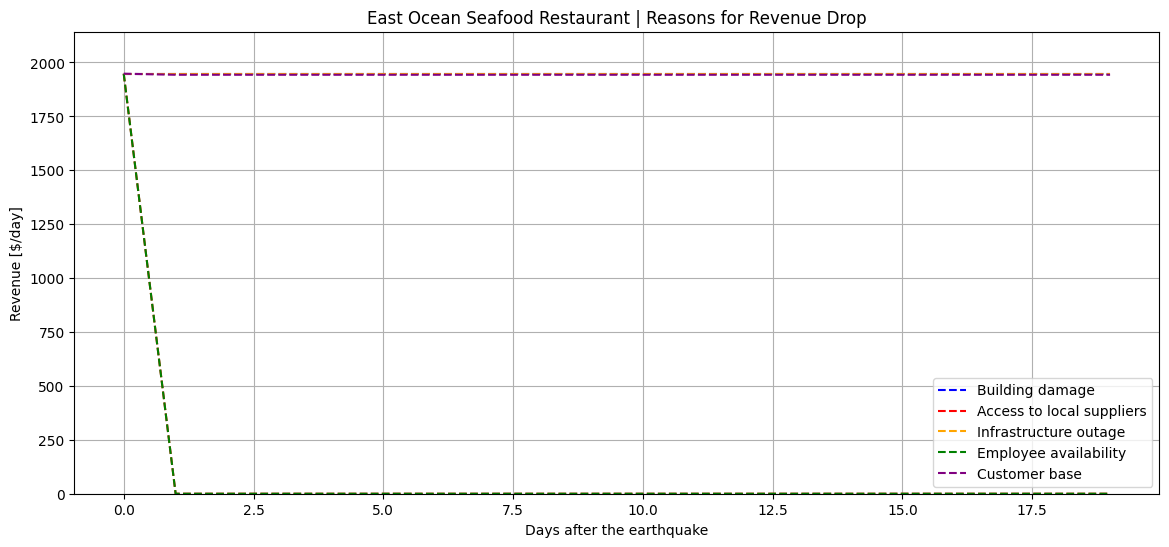

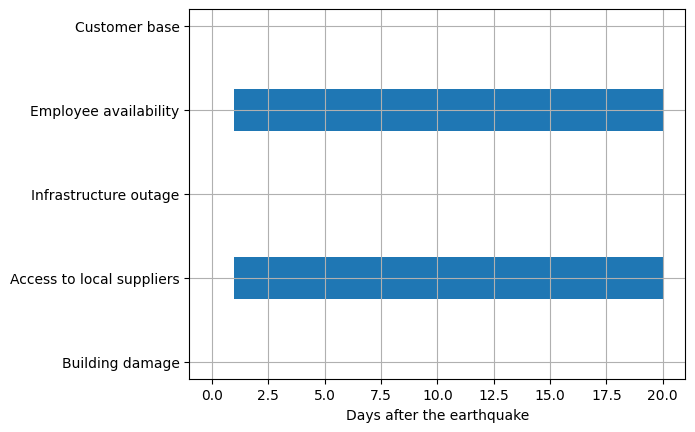

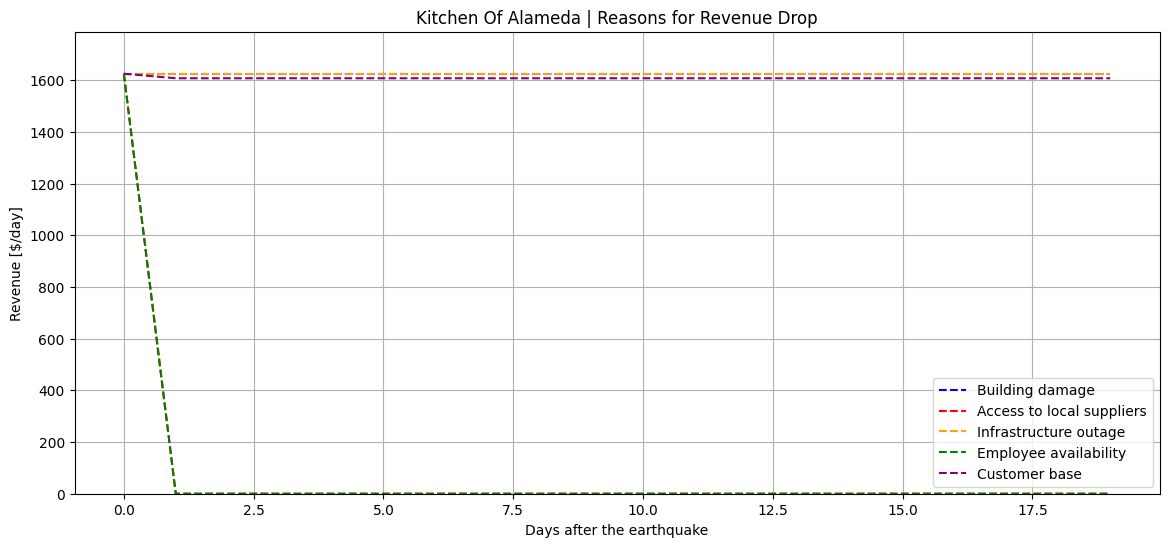

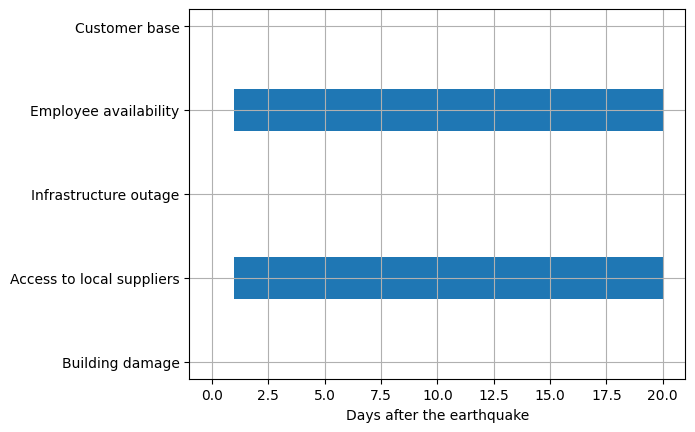

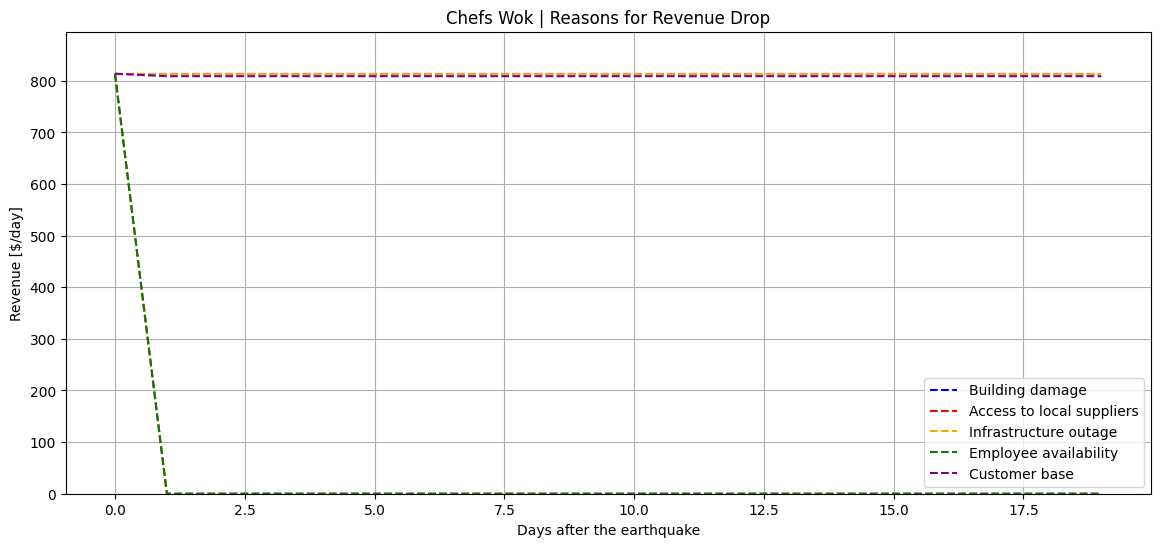

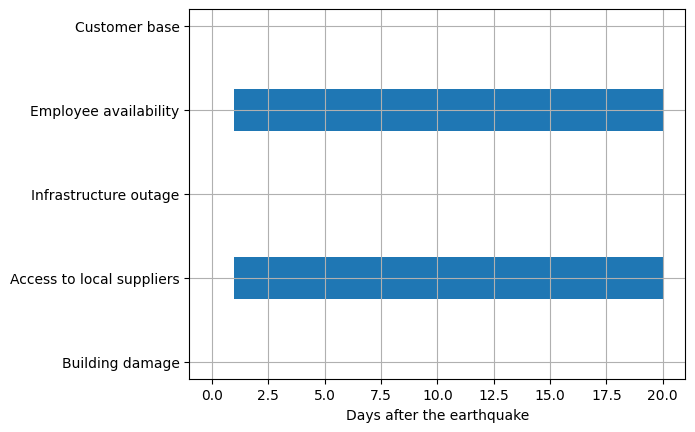

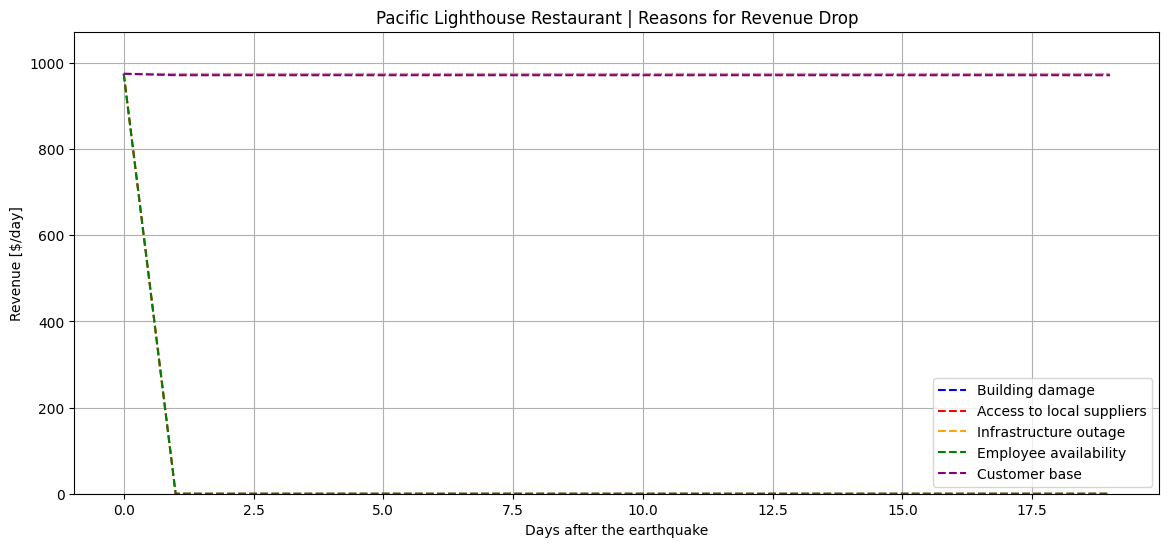

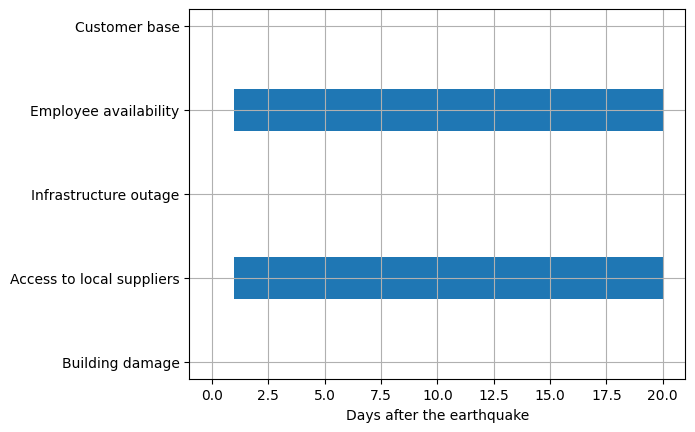

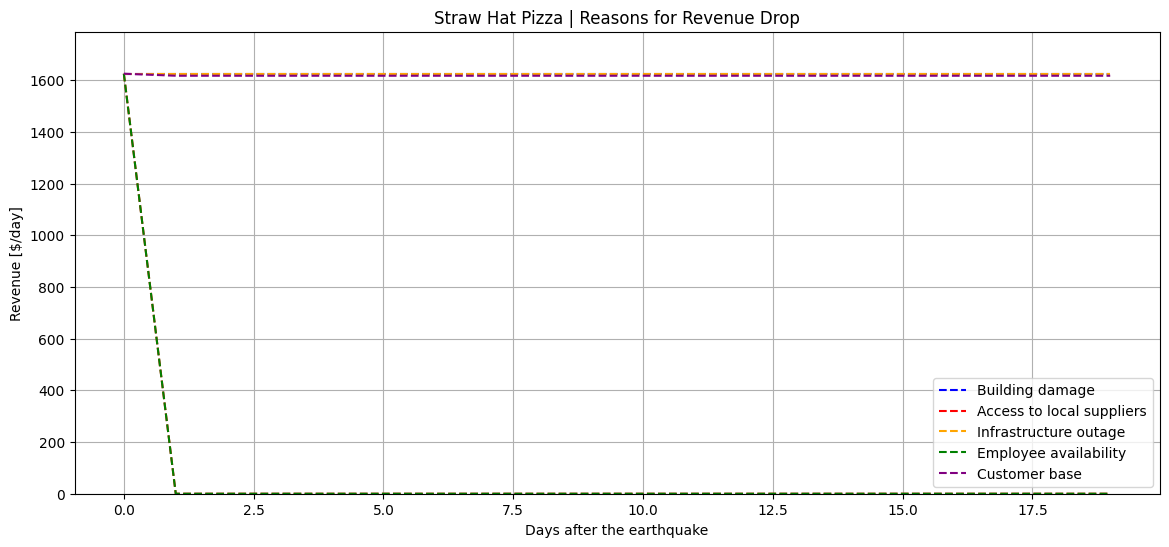

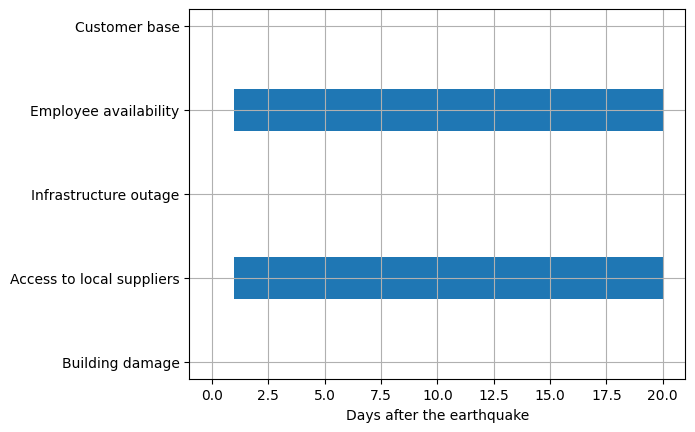

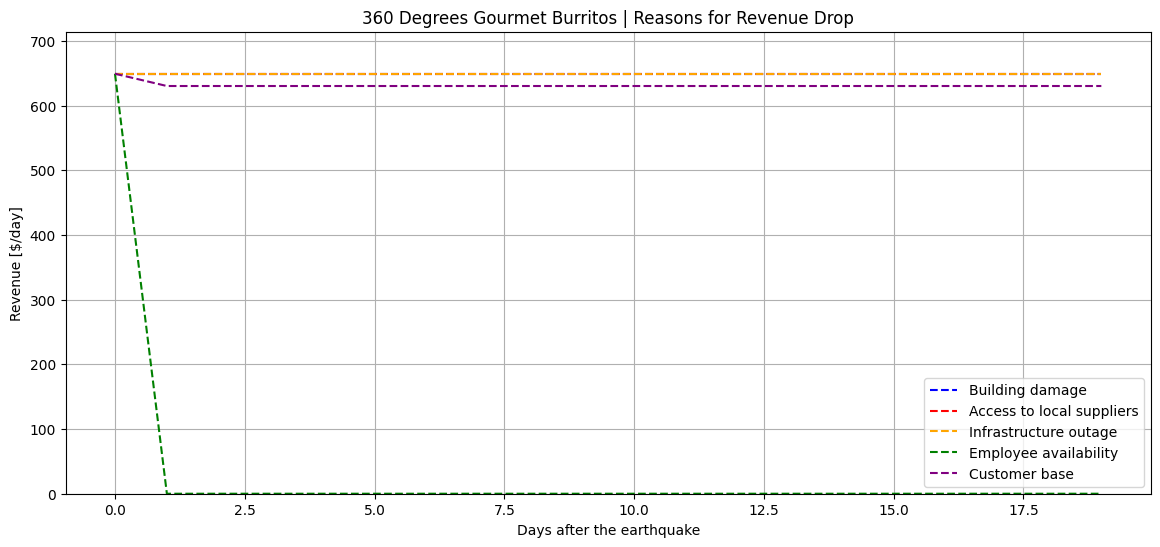

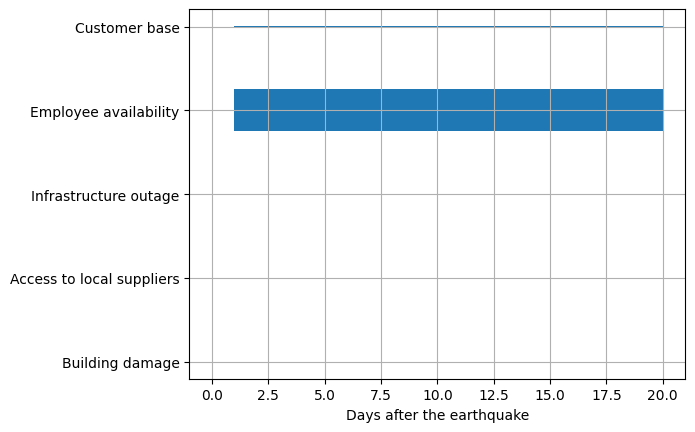

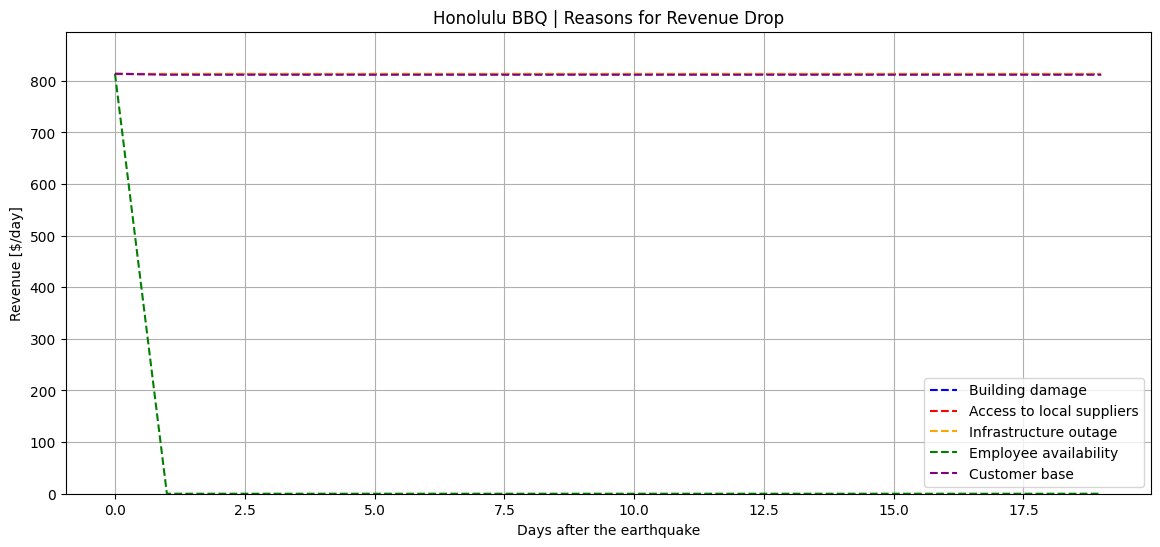

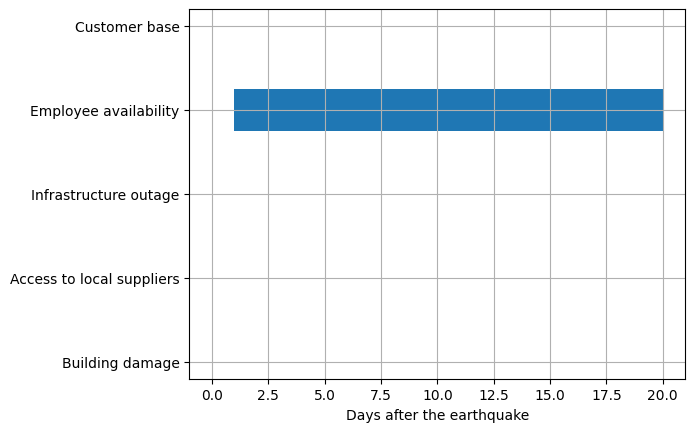

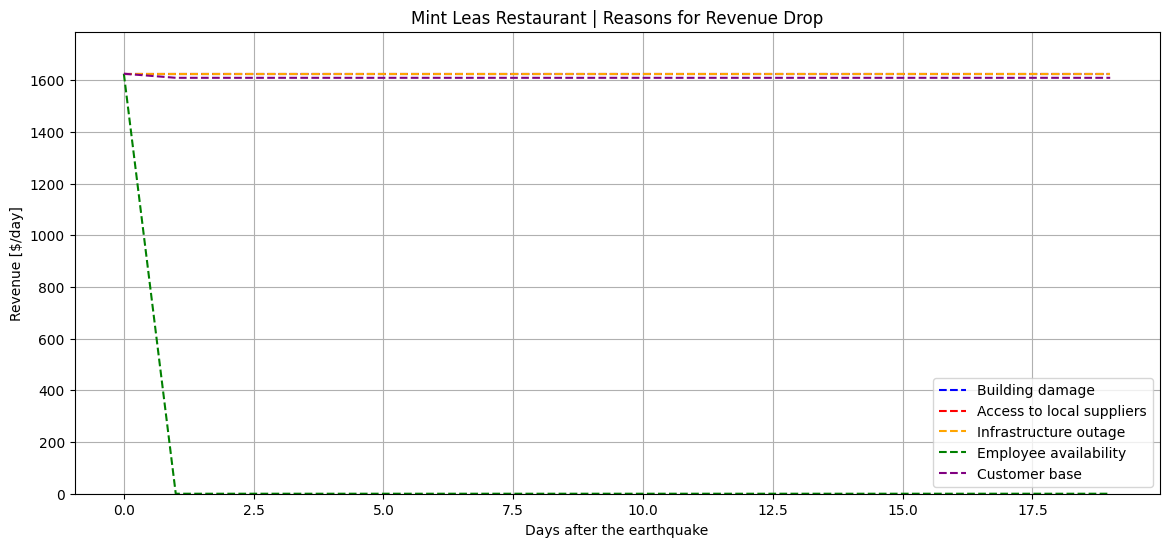

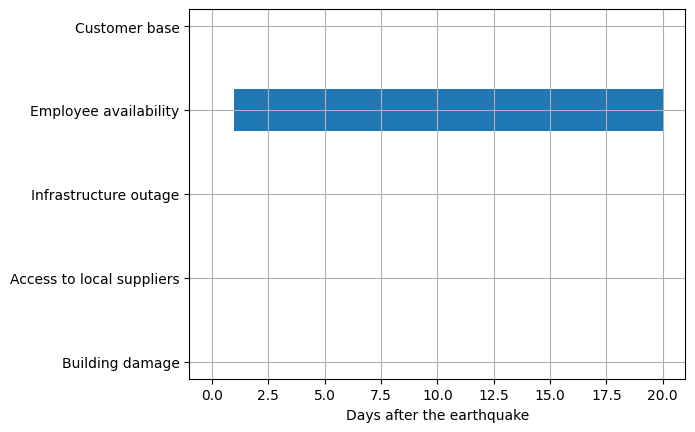

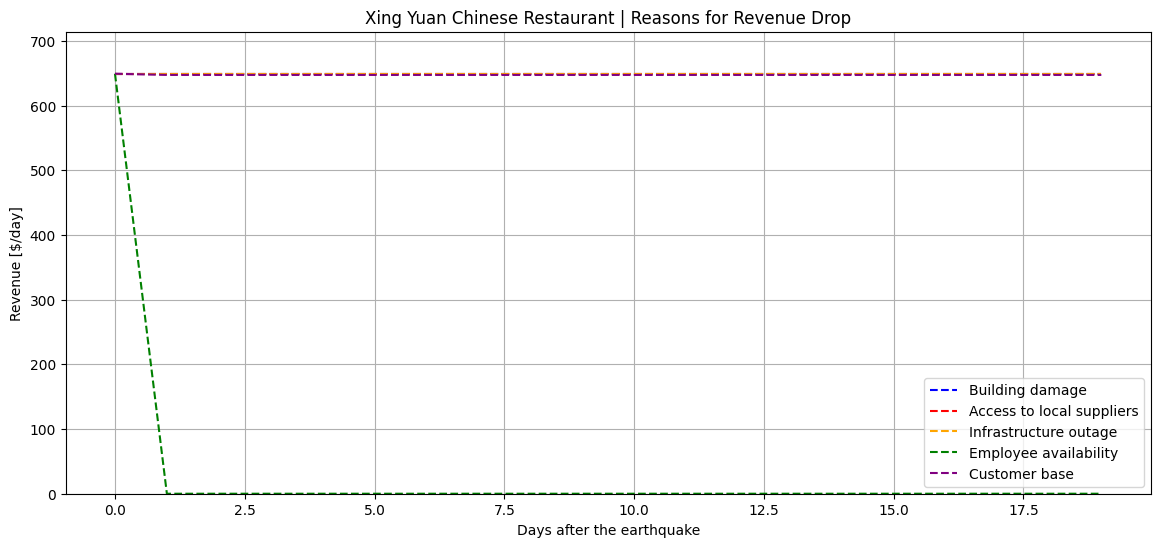

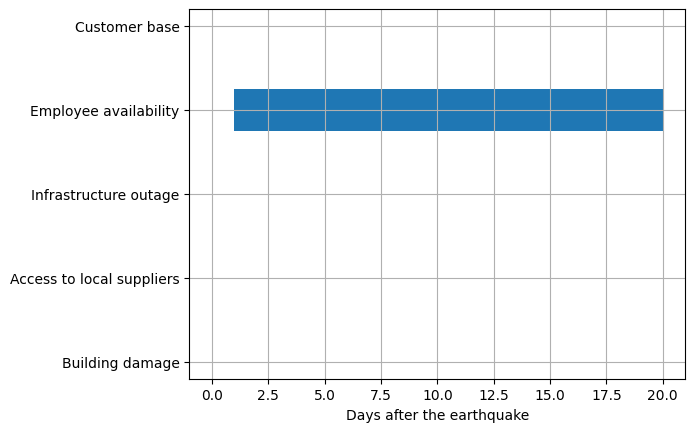

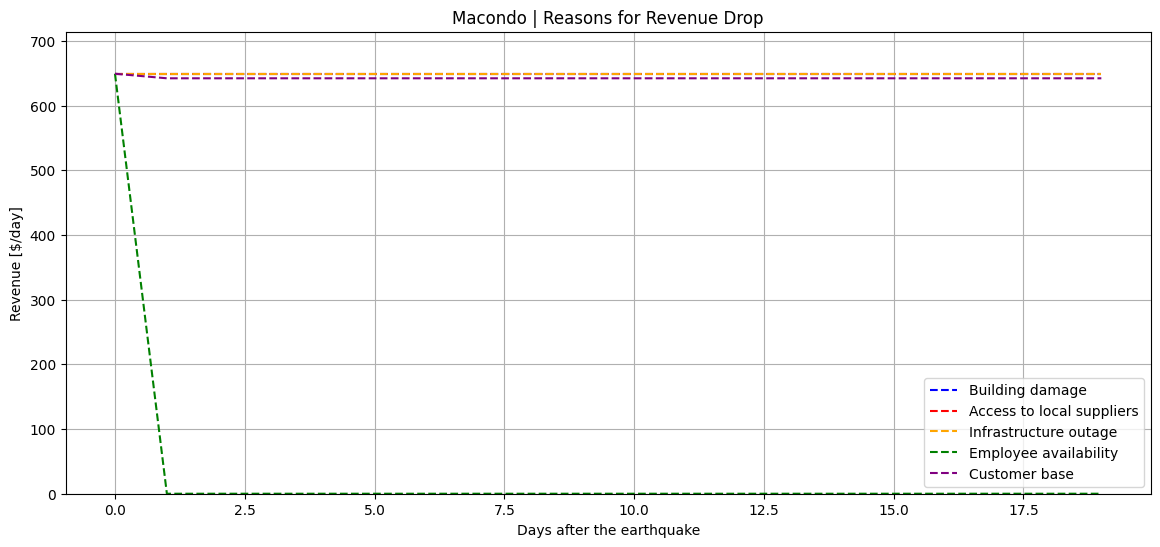

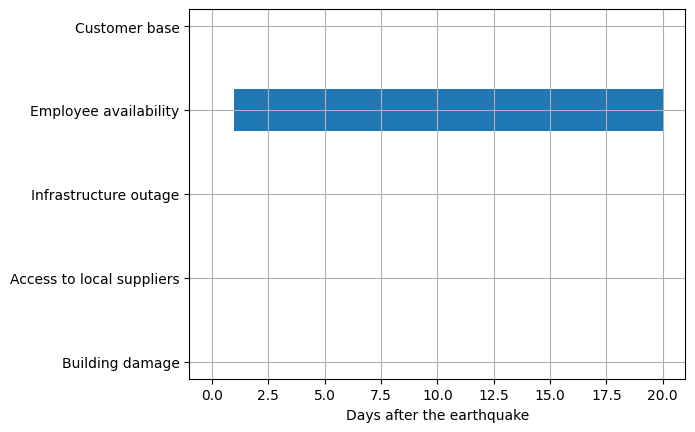

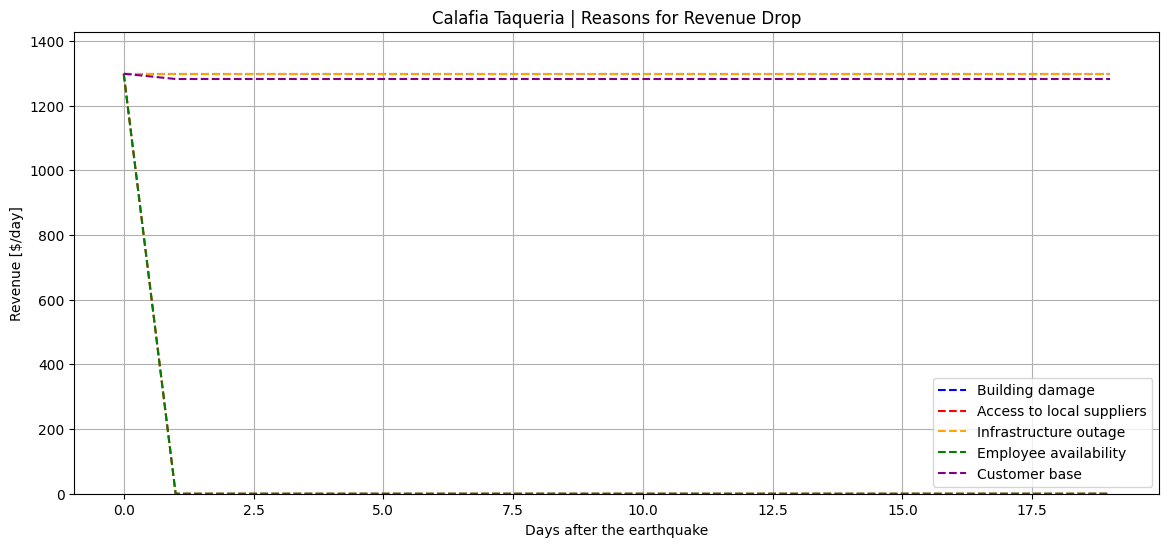

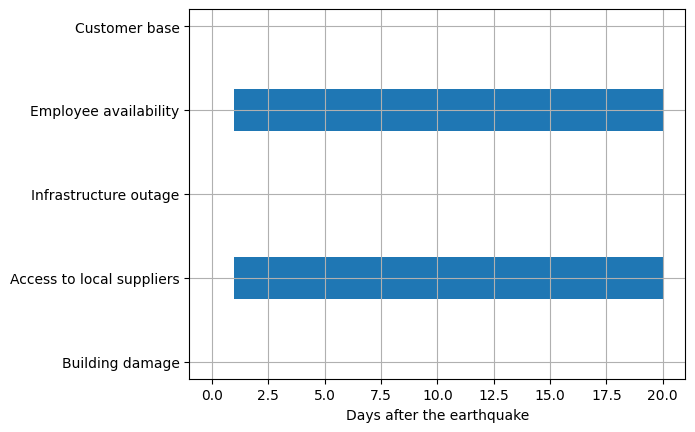

c:\Users\zhut\OneDrive - Stanford\Research\02 Work\05 Commercial downtime\Pyrecodes\20260312\pyrecodes_business\pyrecodes\plotter\business_plotter.py:53: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(bottom=0, top=max(max(data['Revenue']) for data in reasons_as_lines.values()) * 1.1)


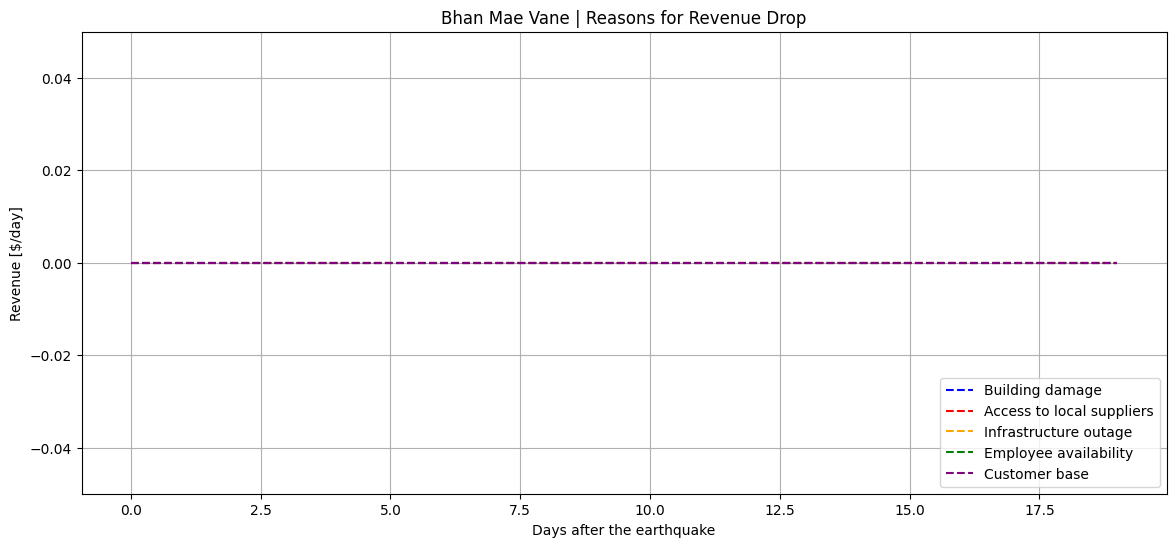

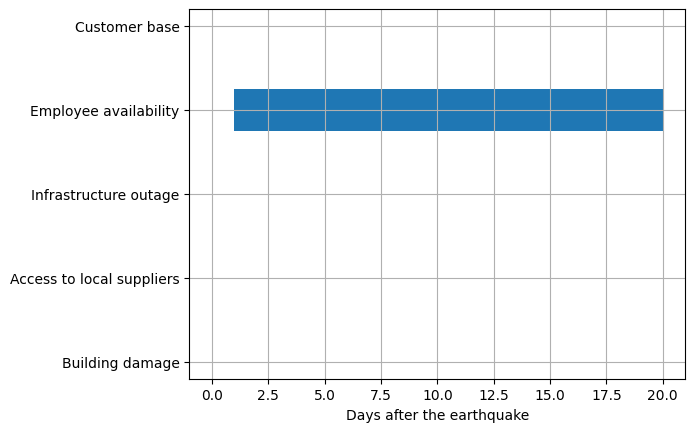

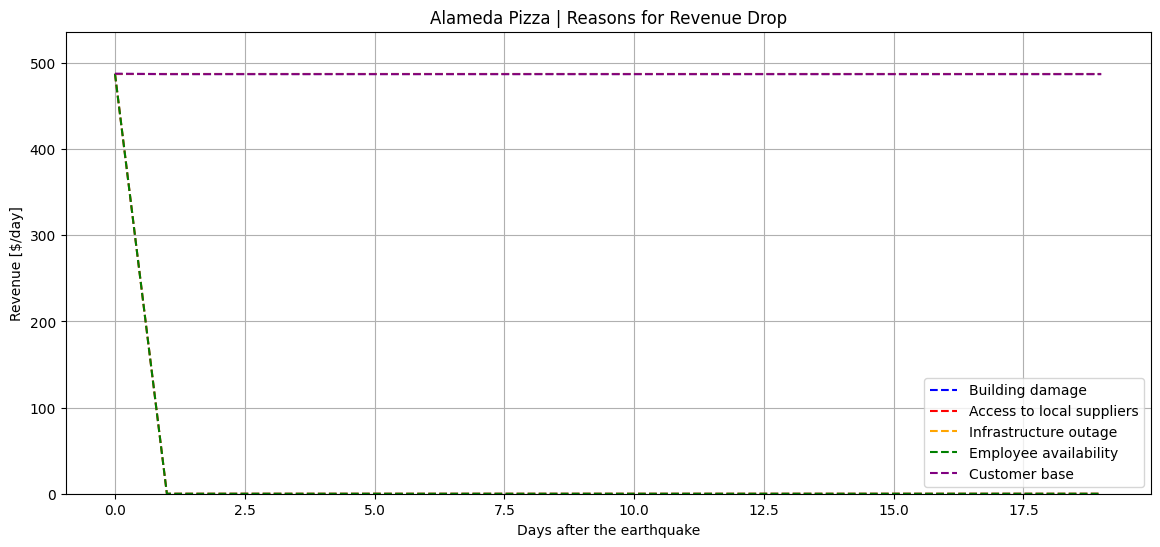

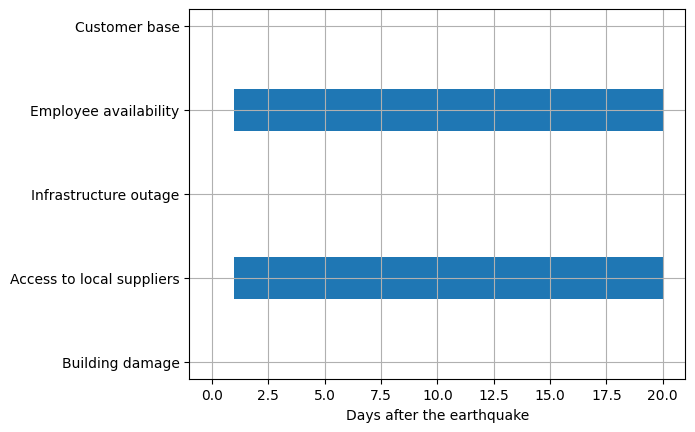

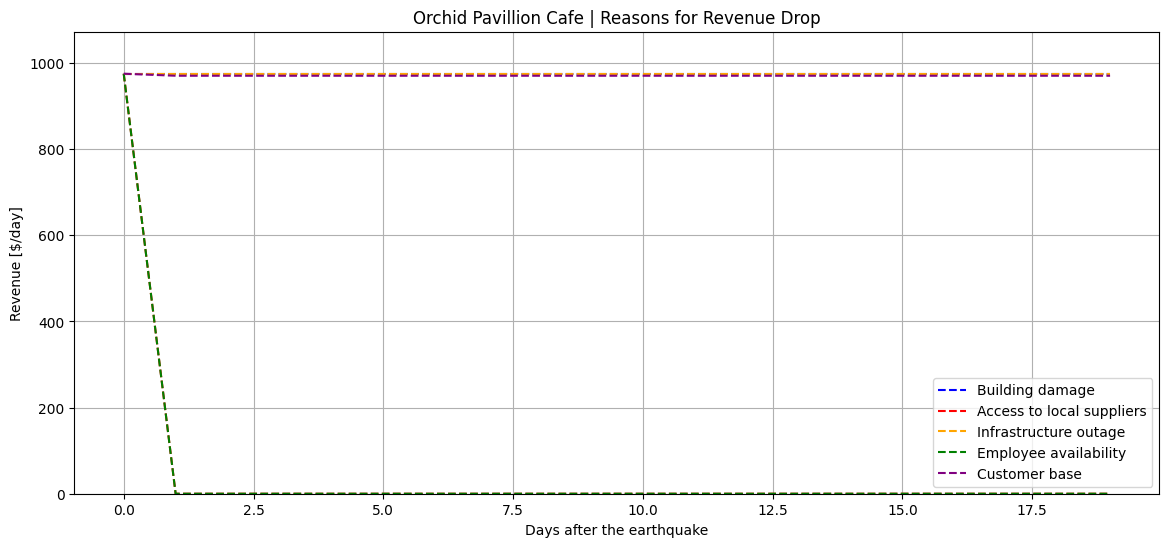

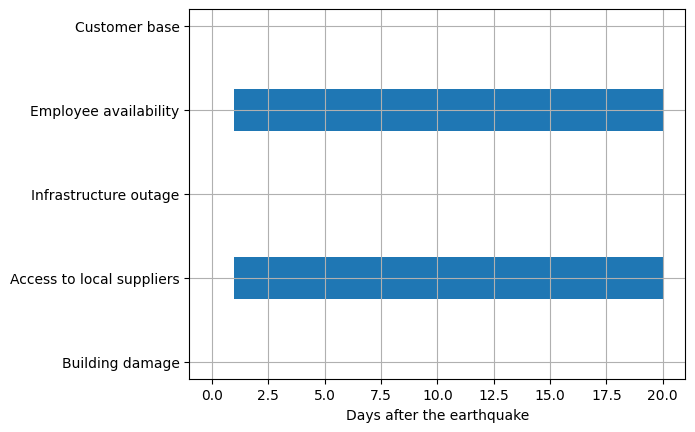

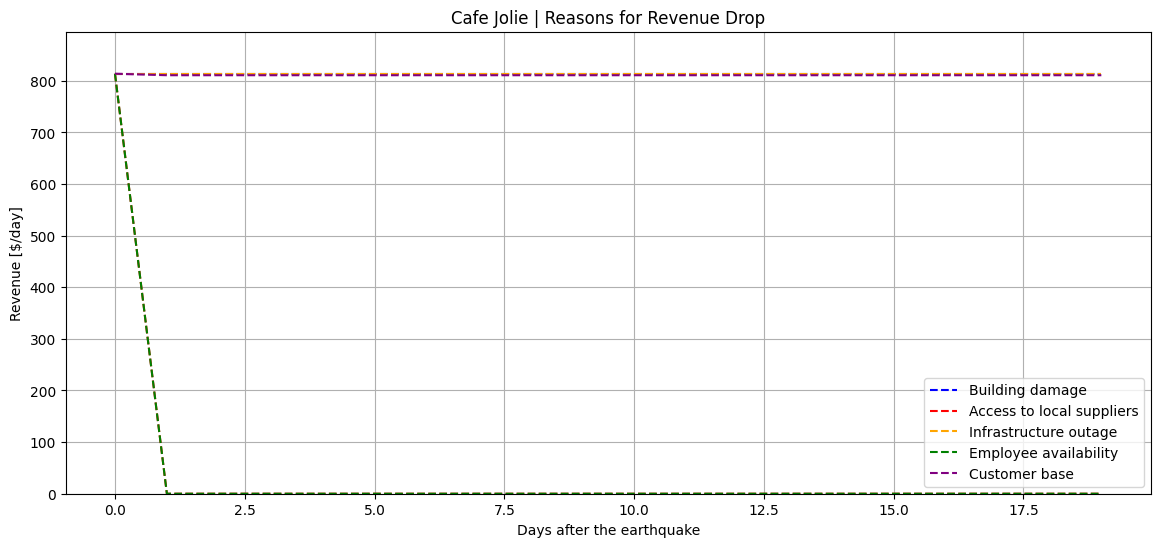

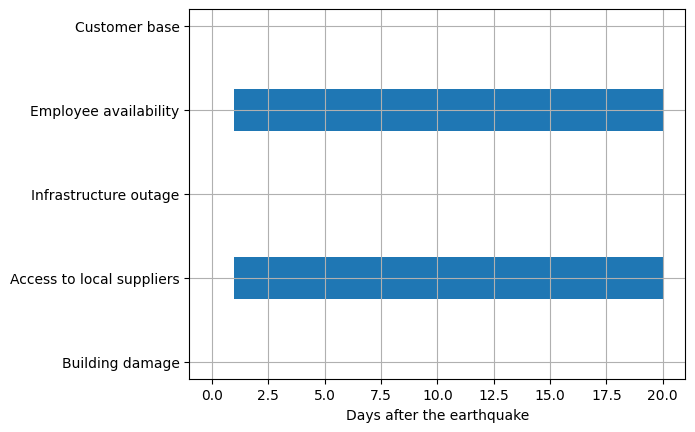

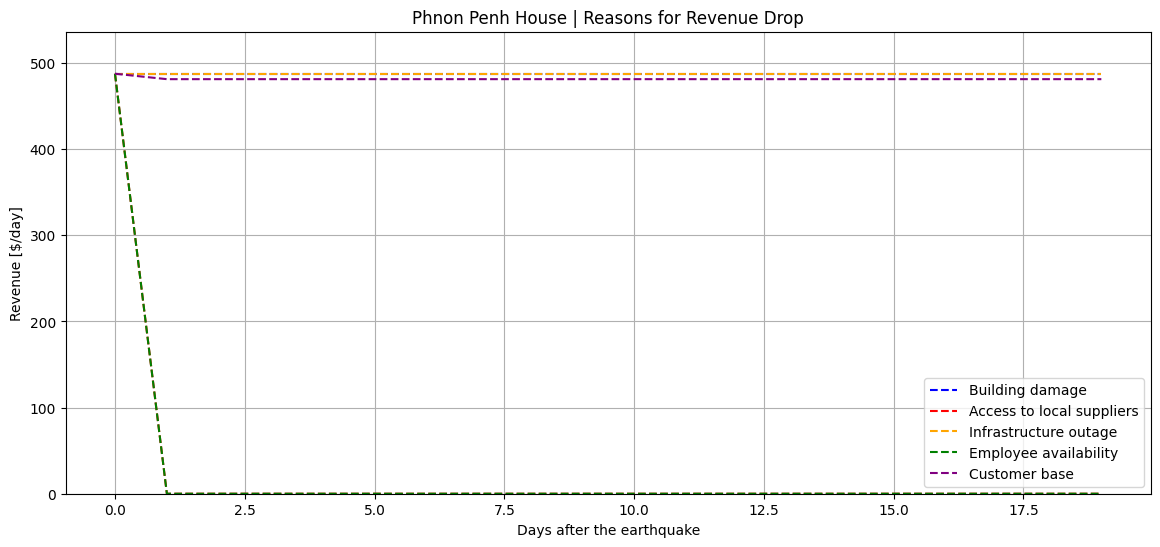

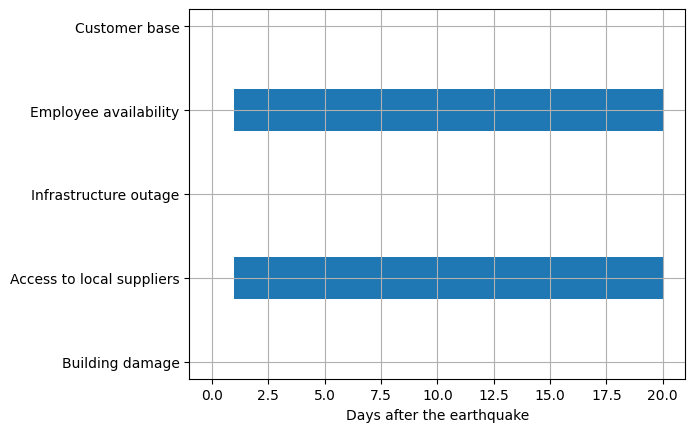

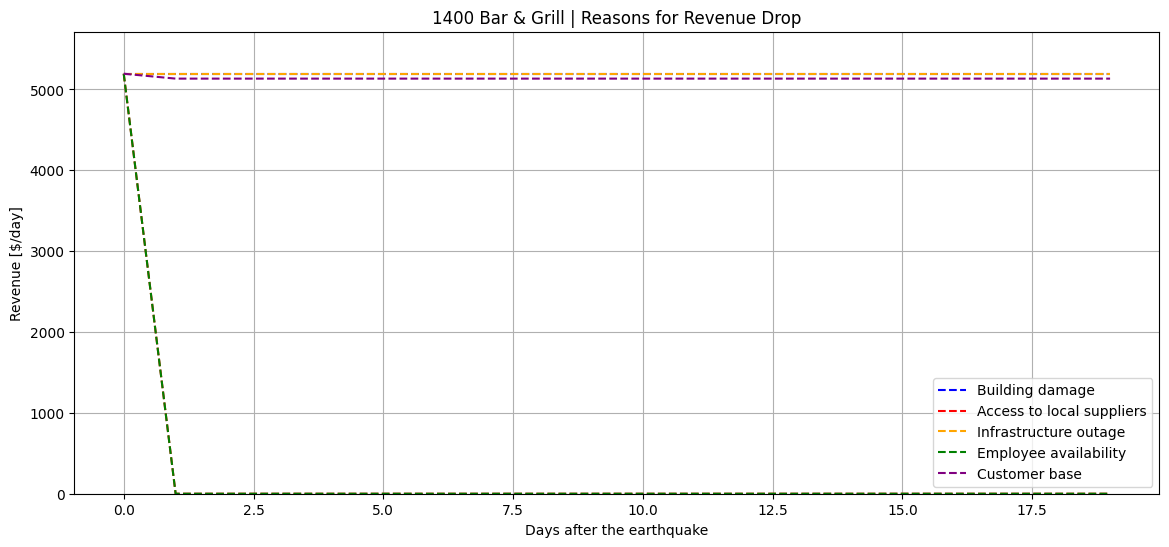

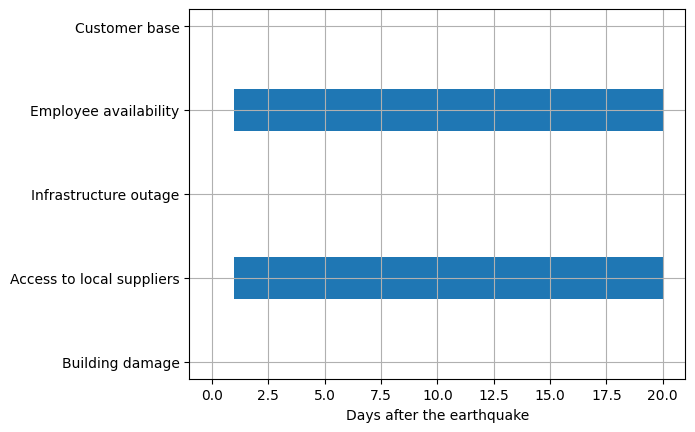

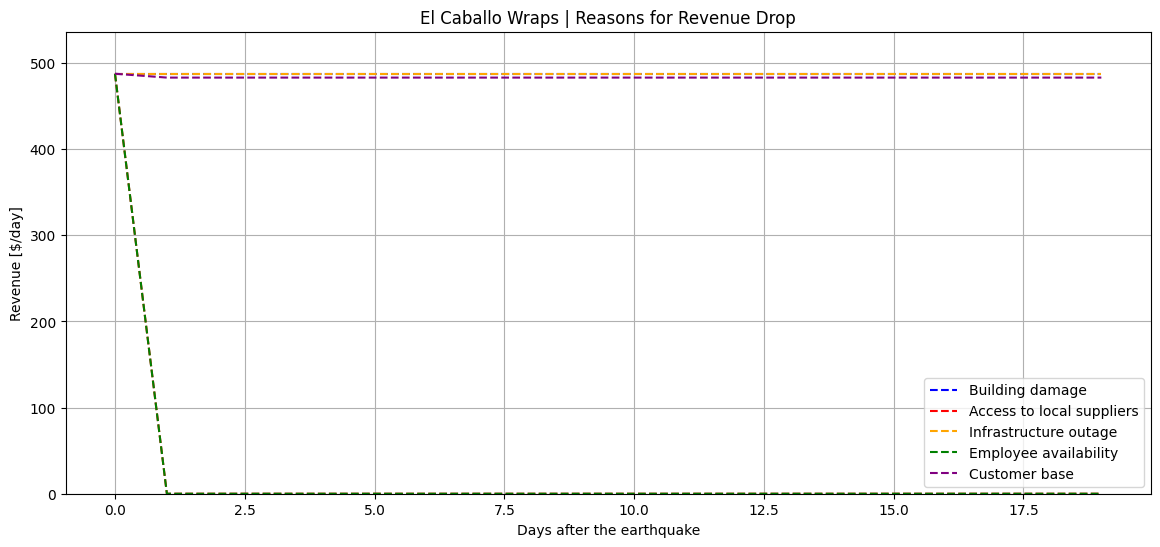

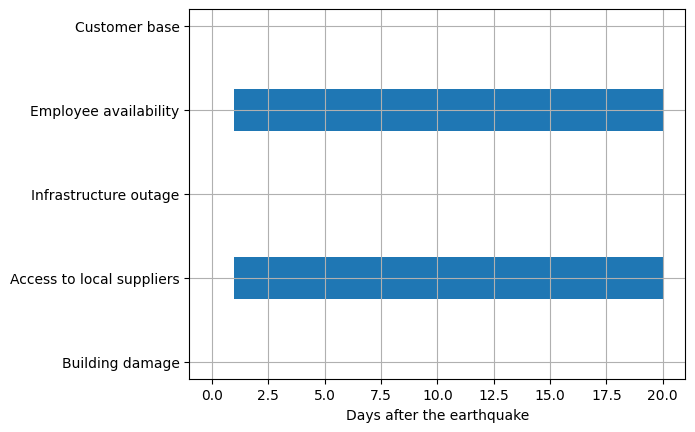

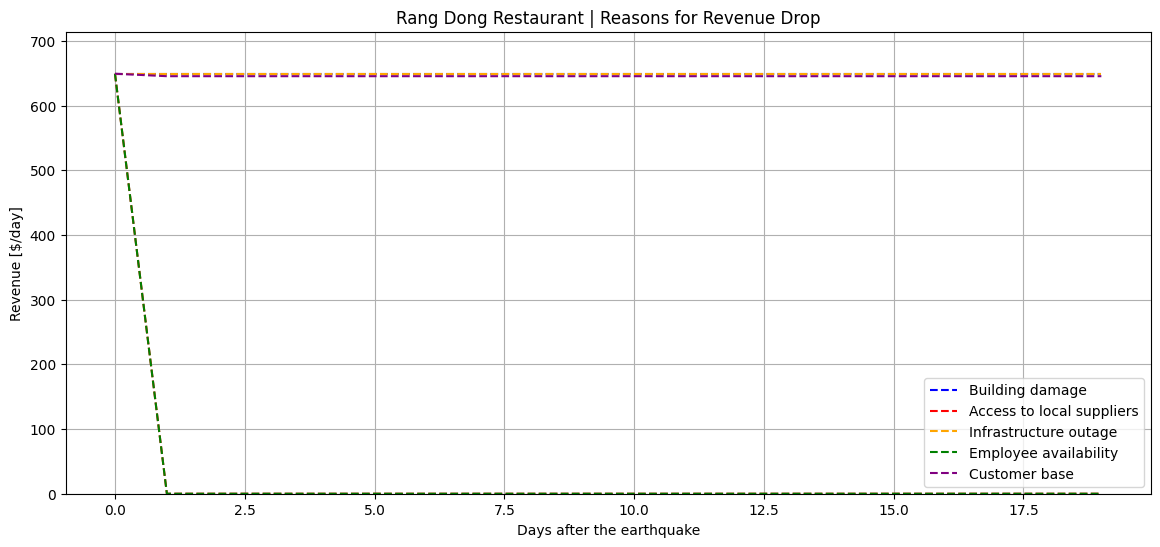

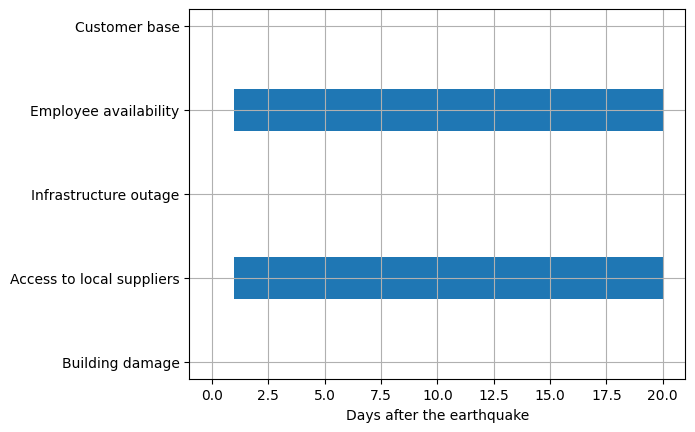

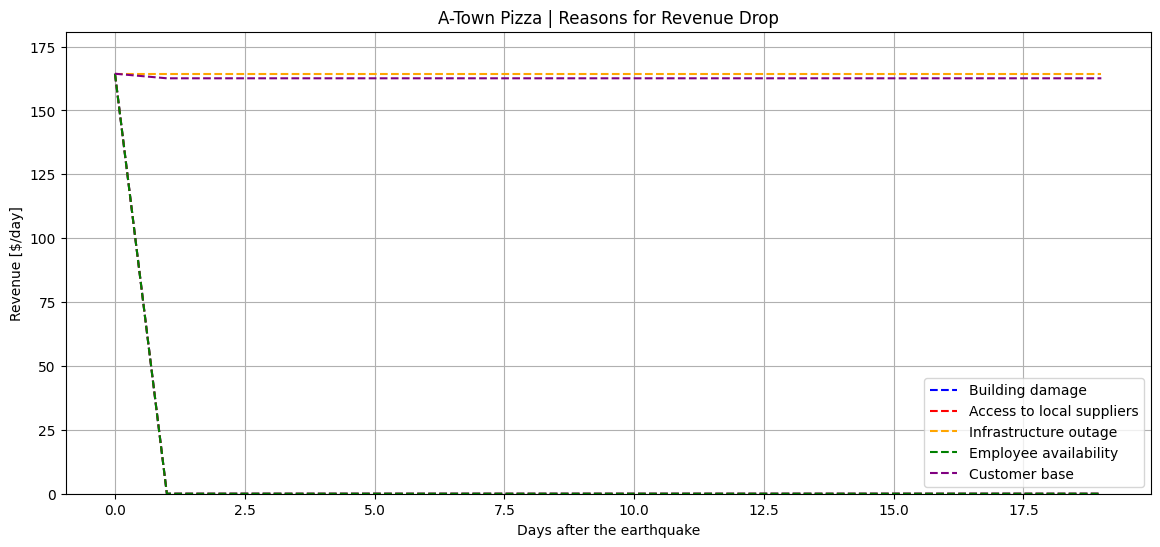

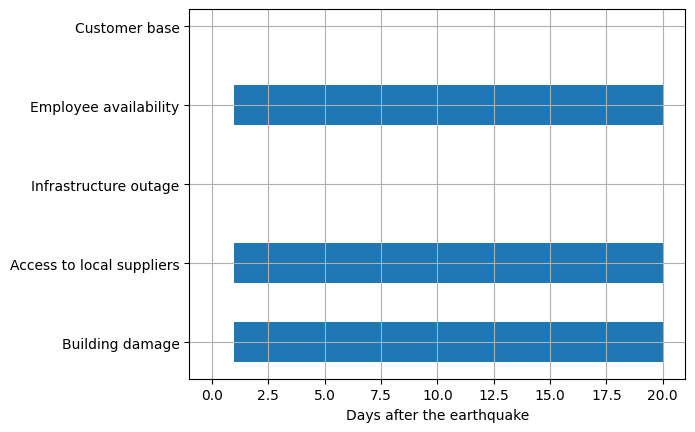

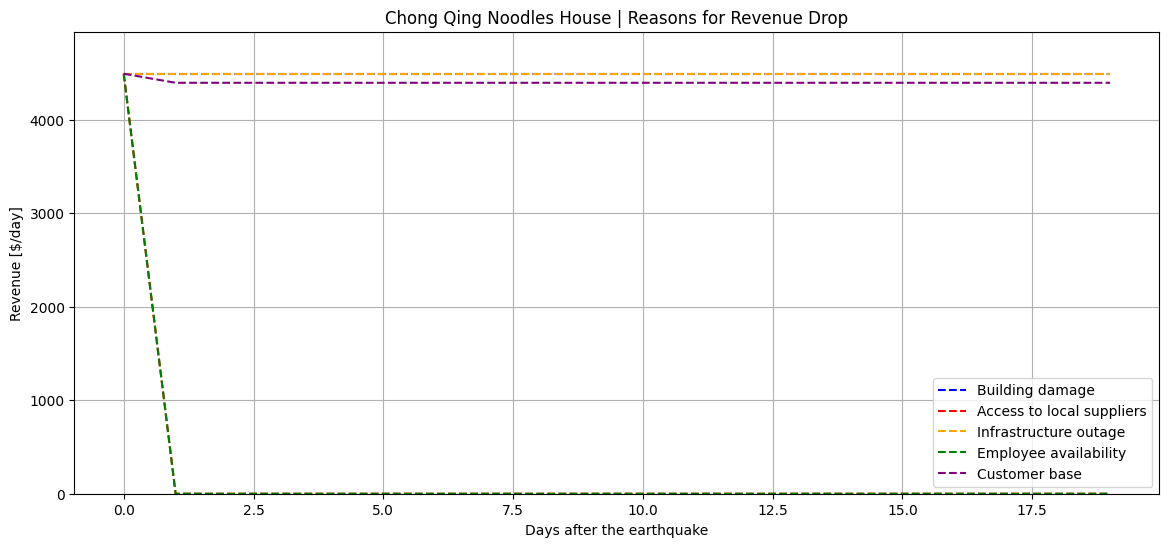

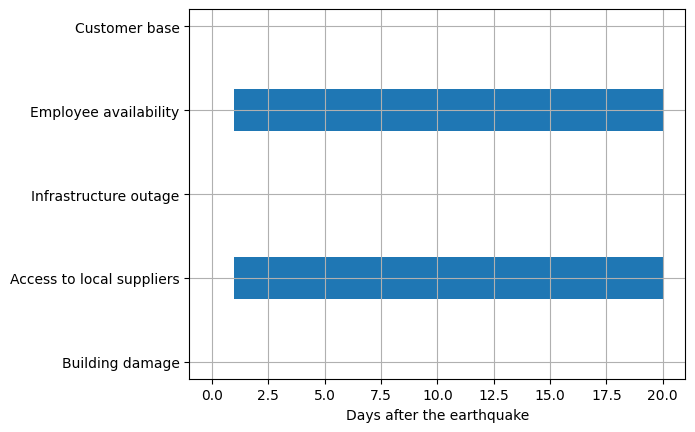

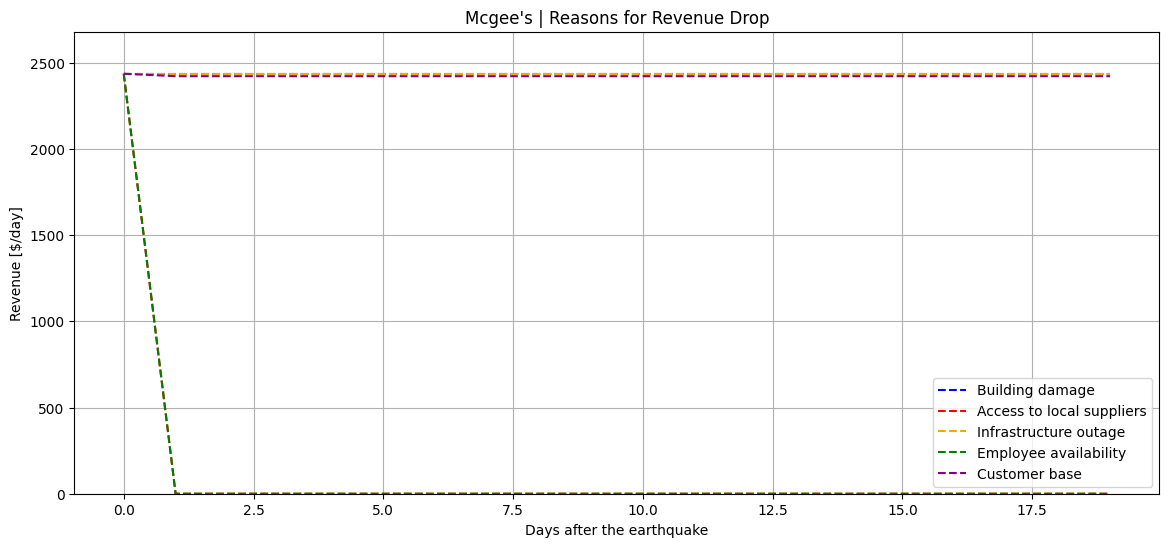

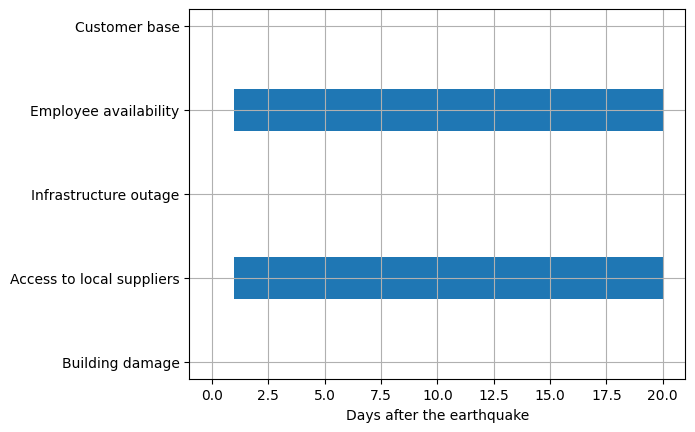

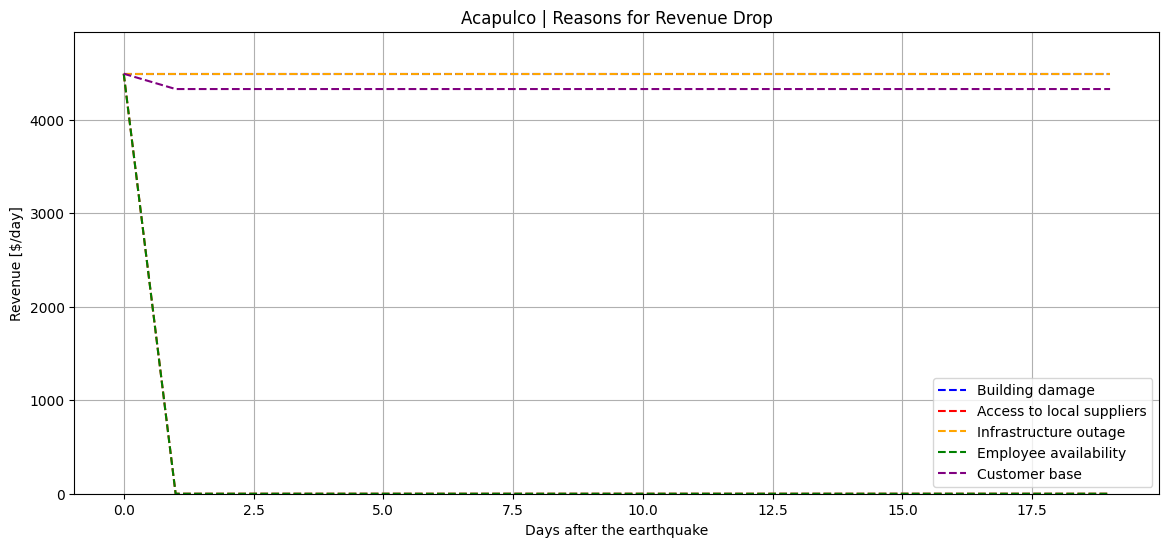

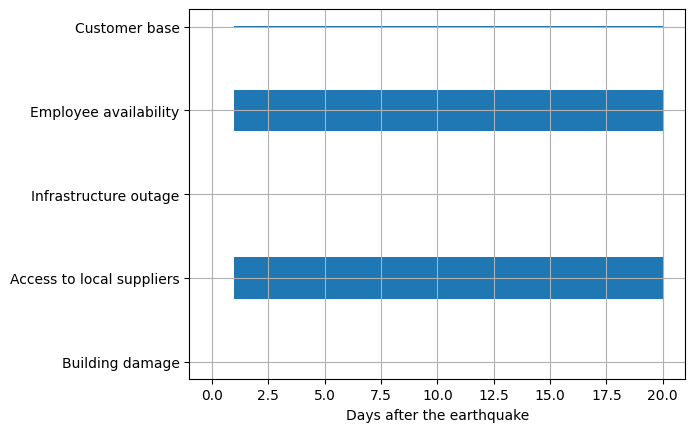

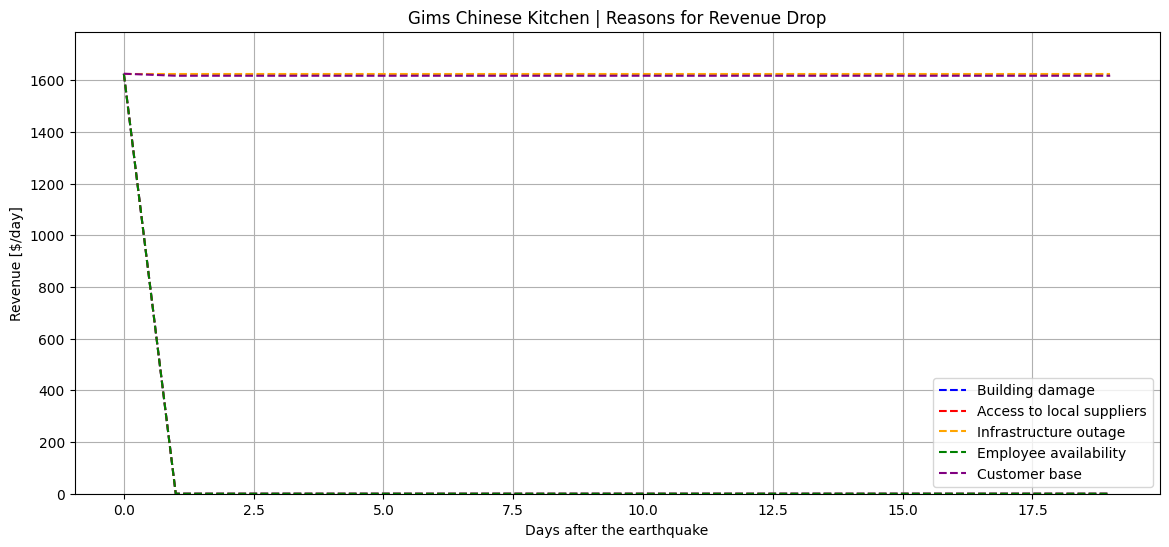

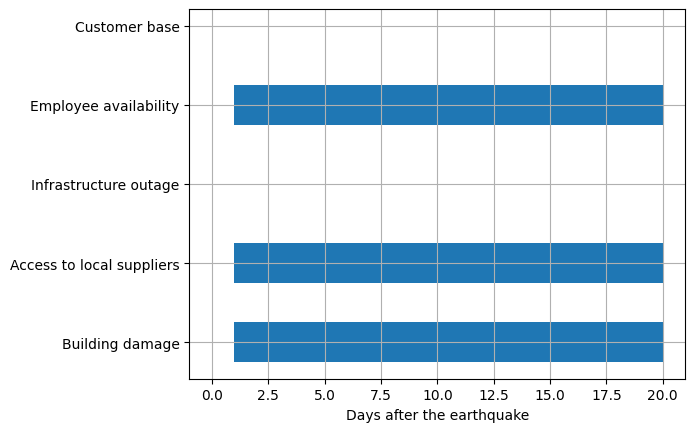

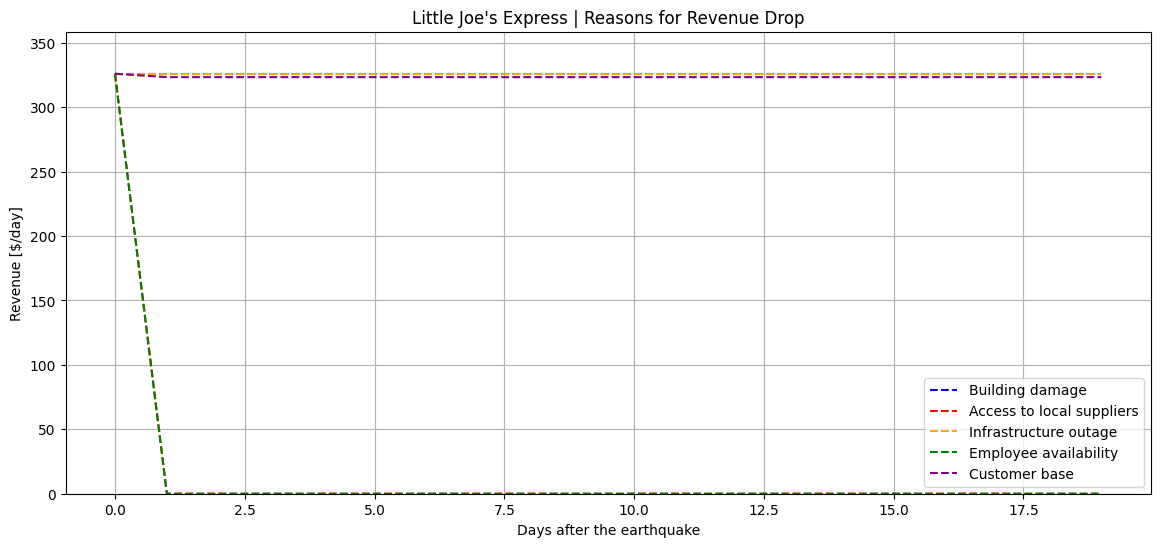

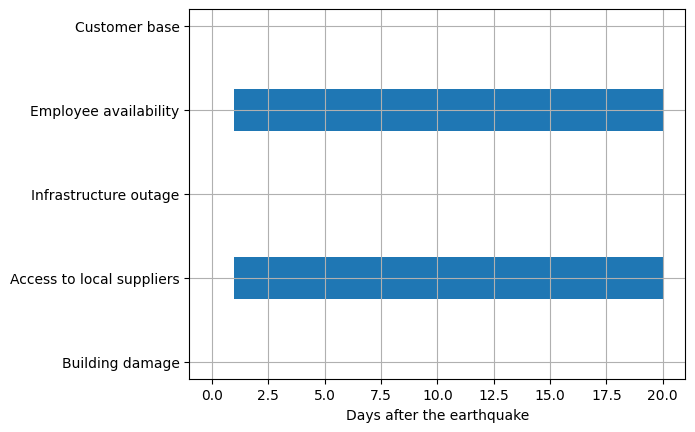

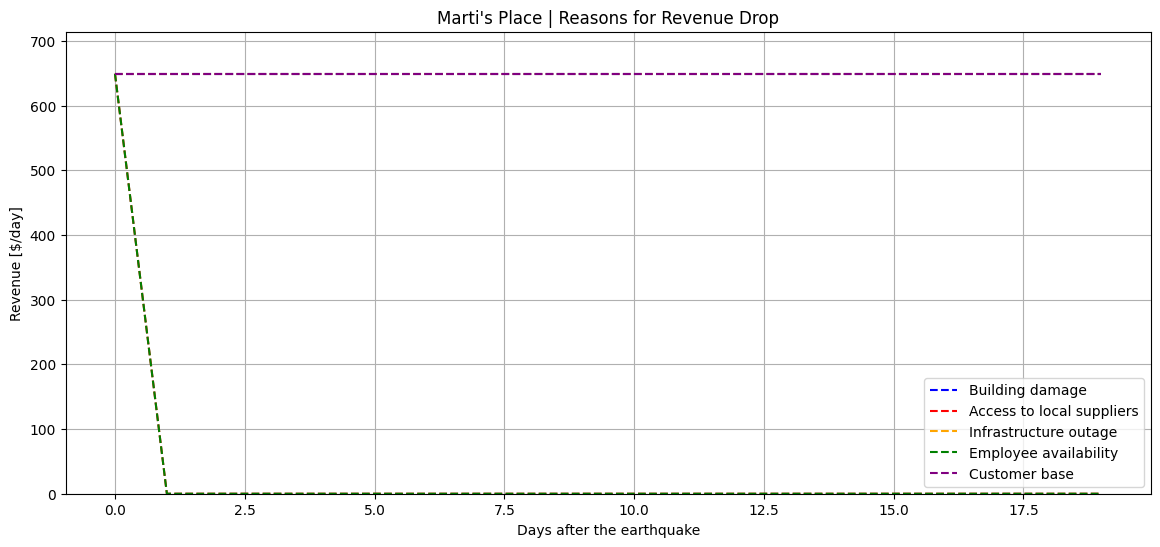

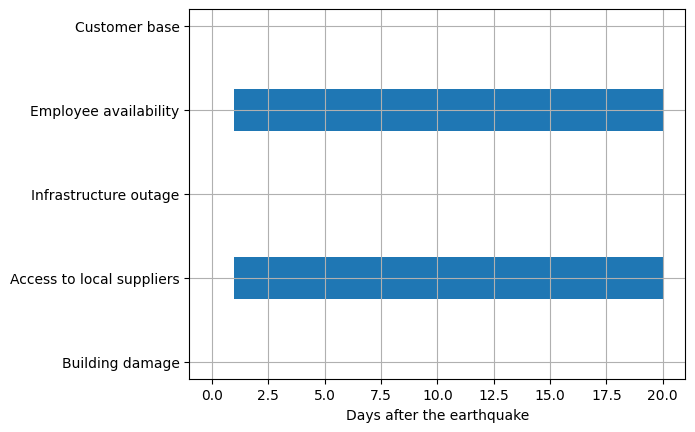

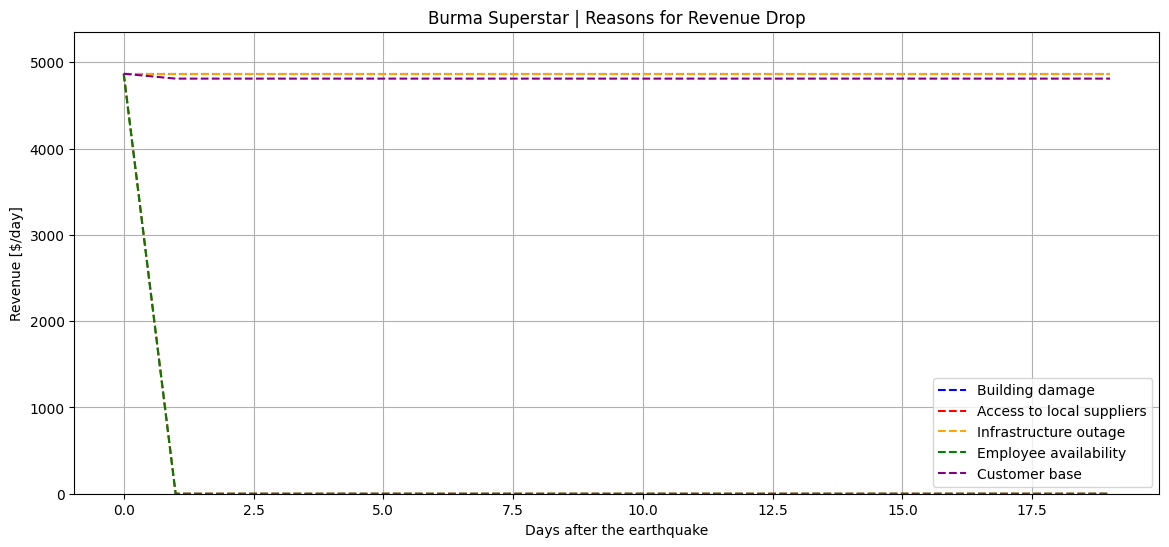

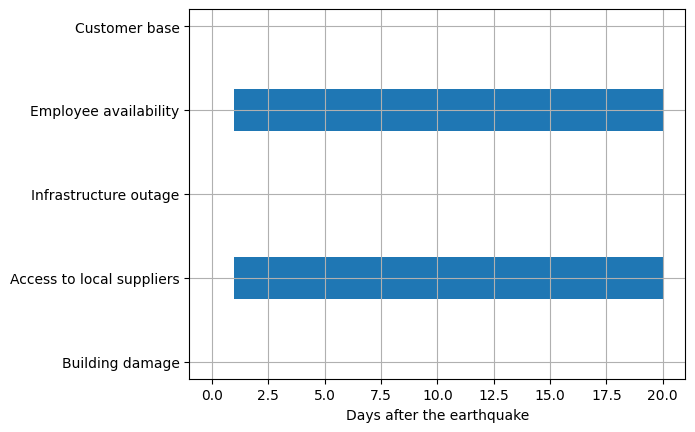

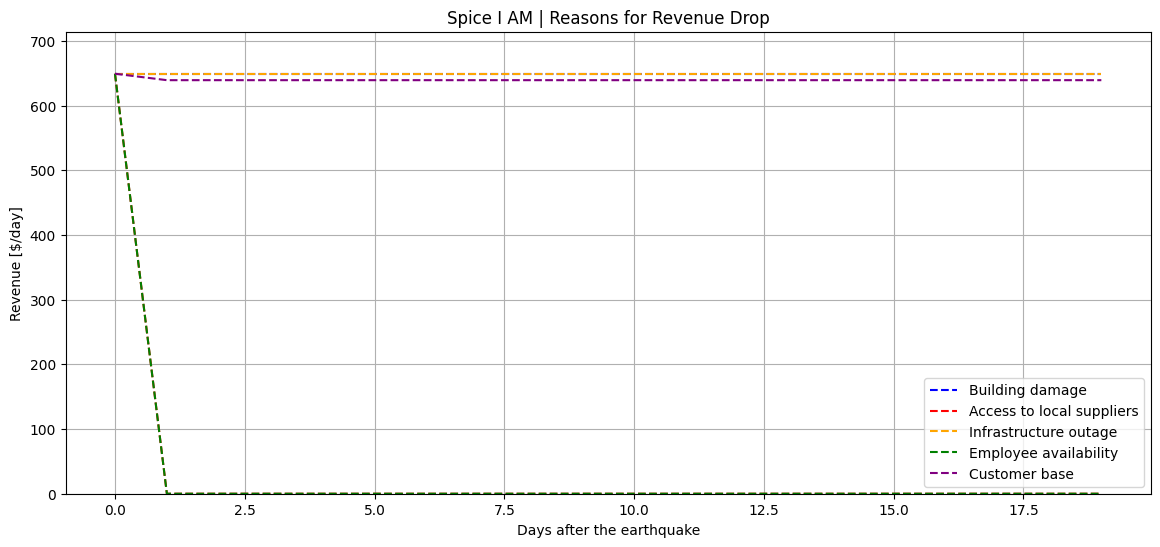

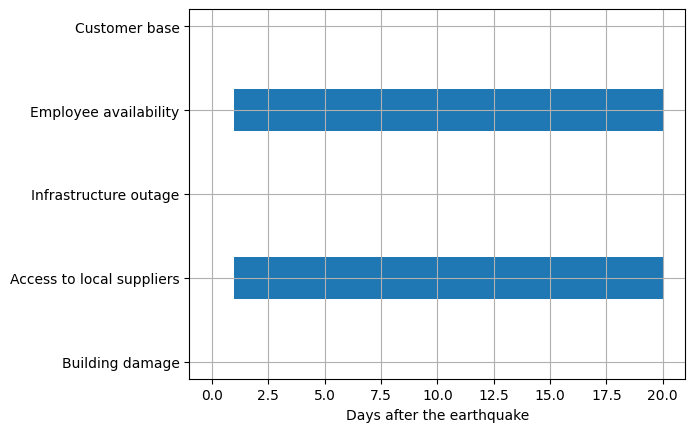

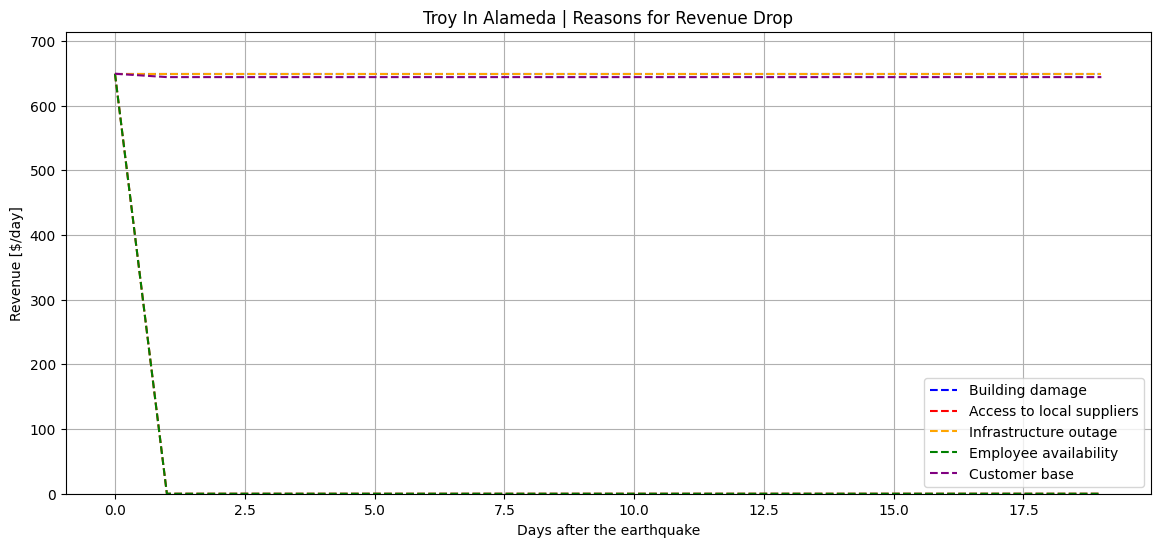

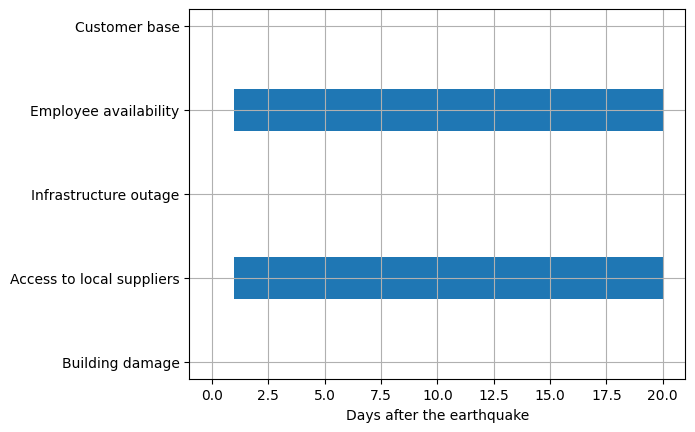

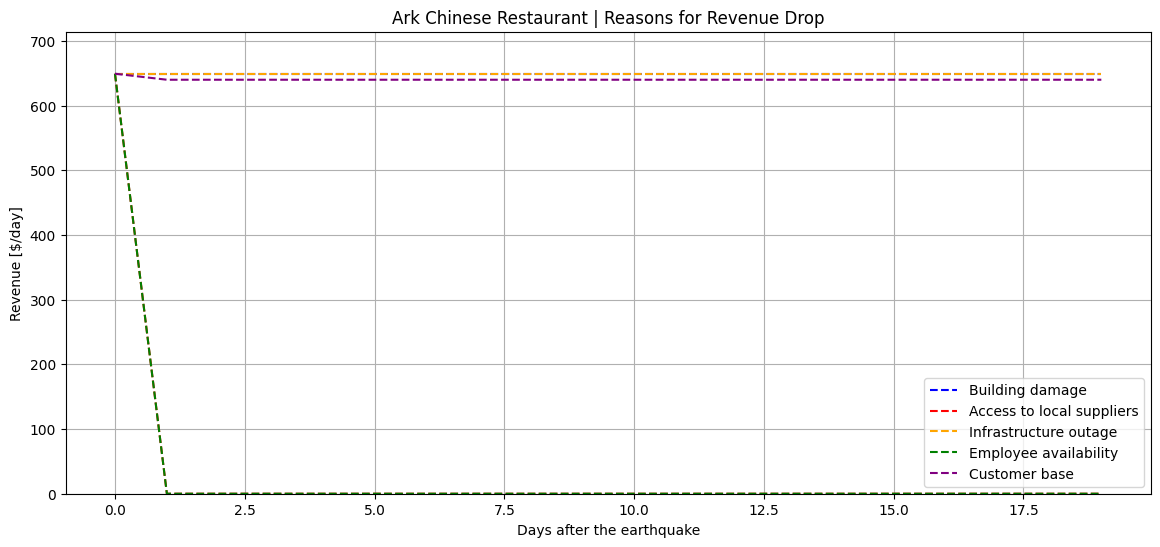

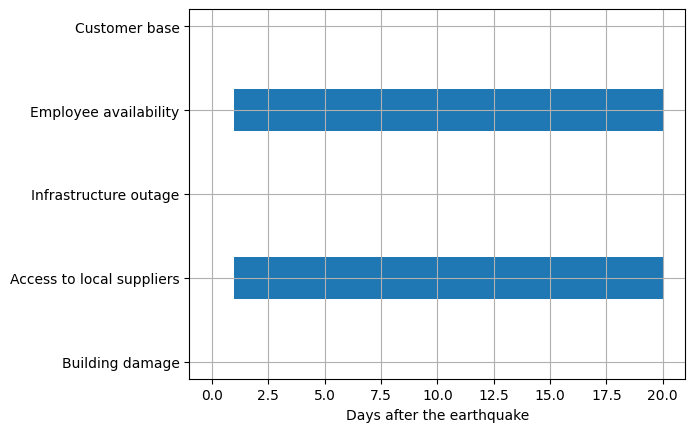

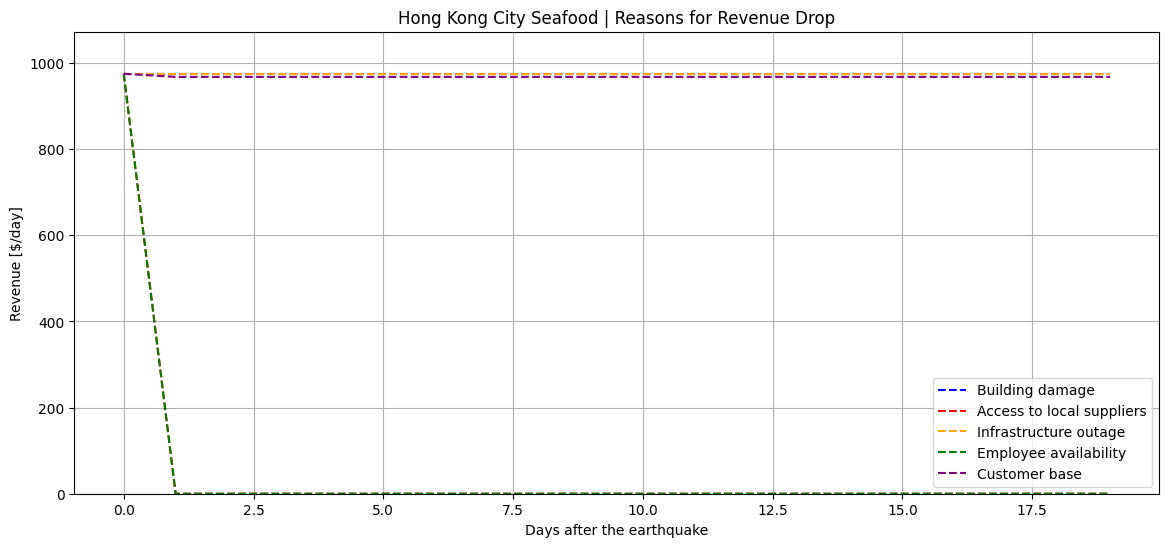

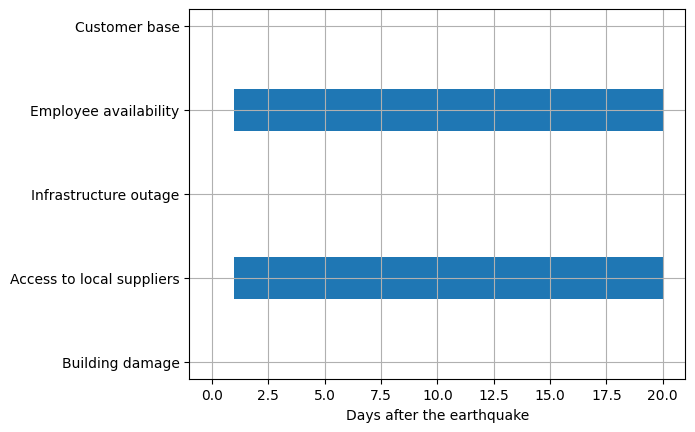

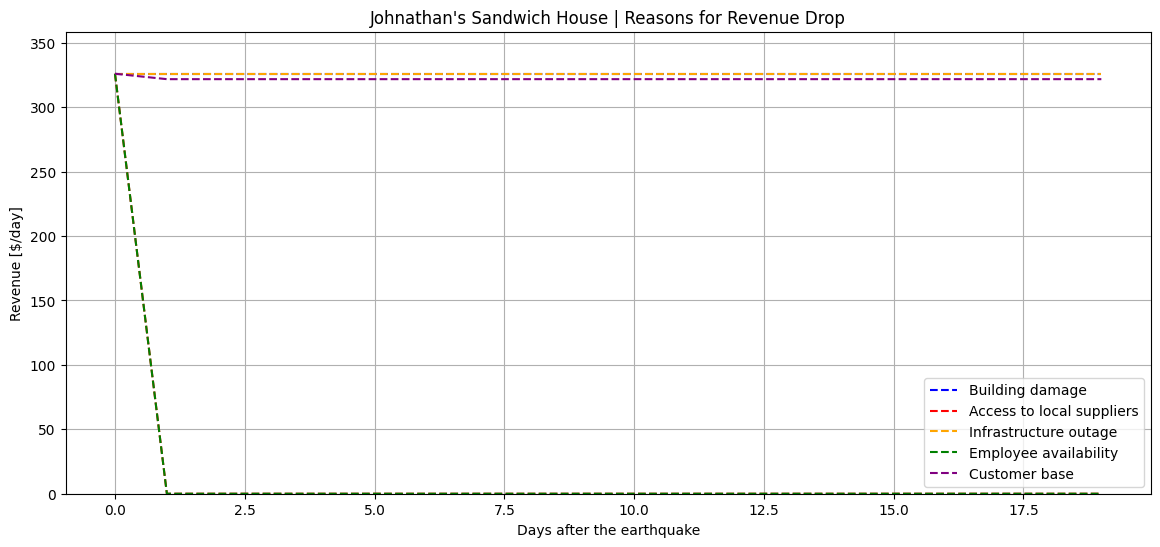

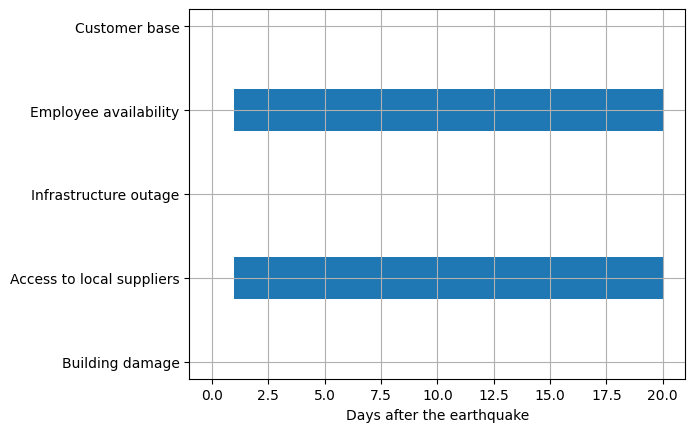

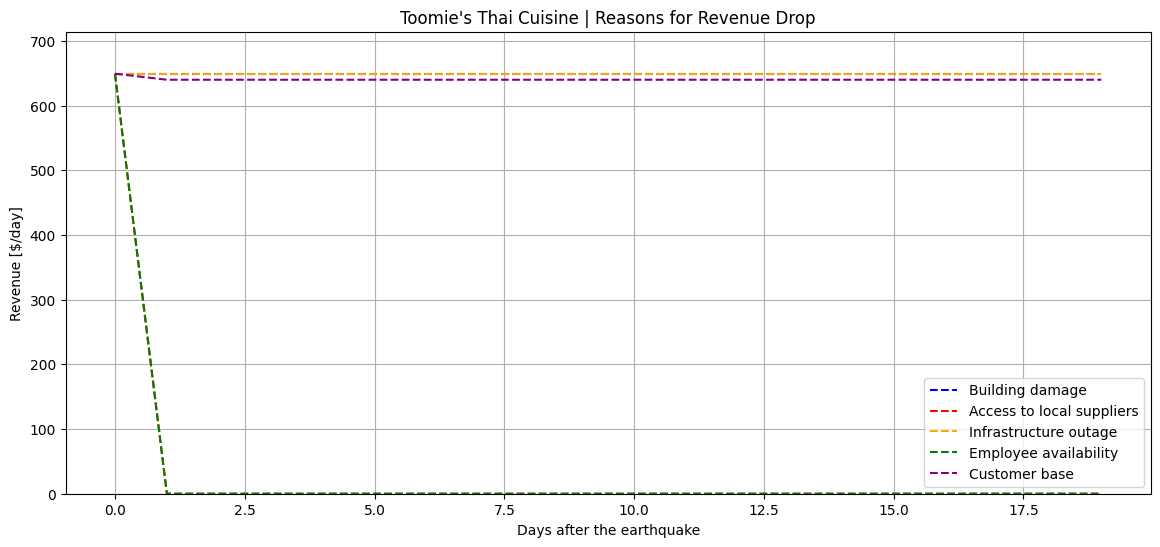

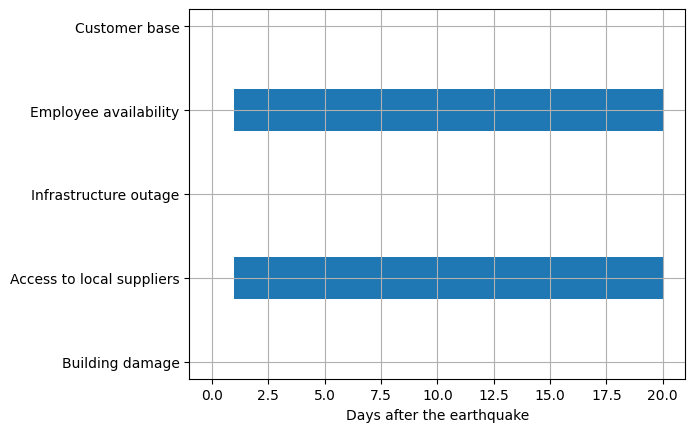

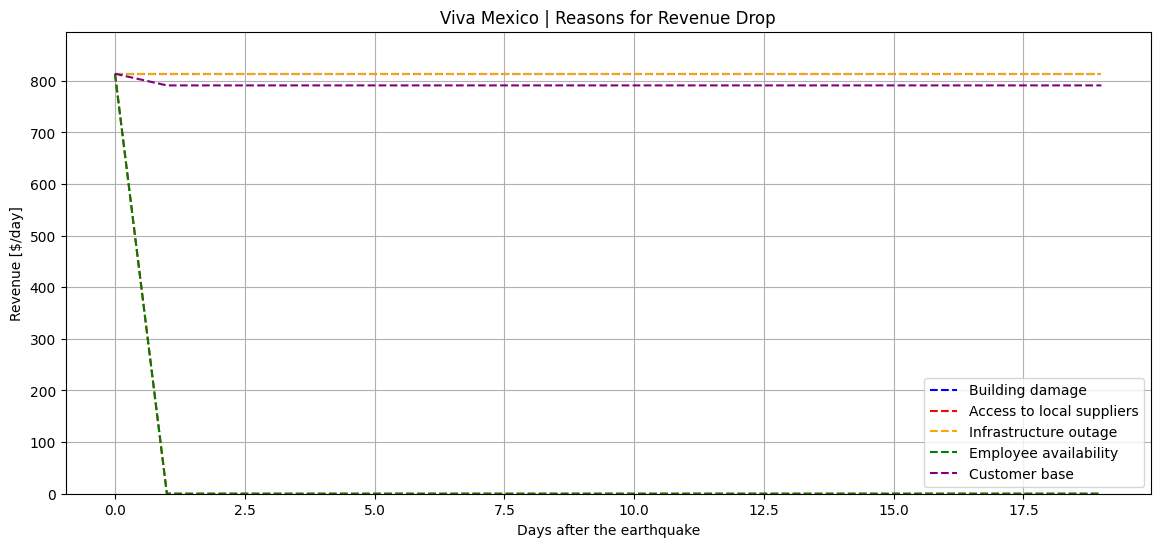

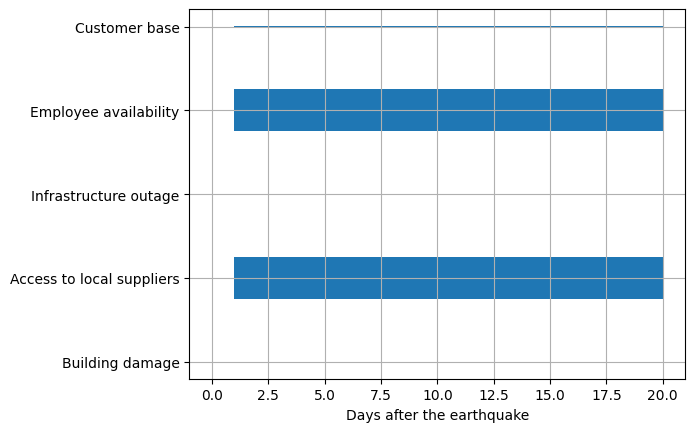

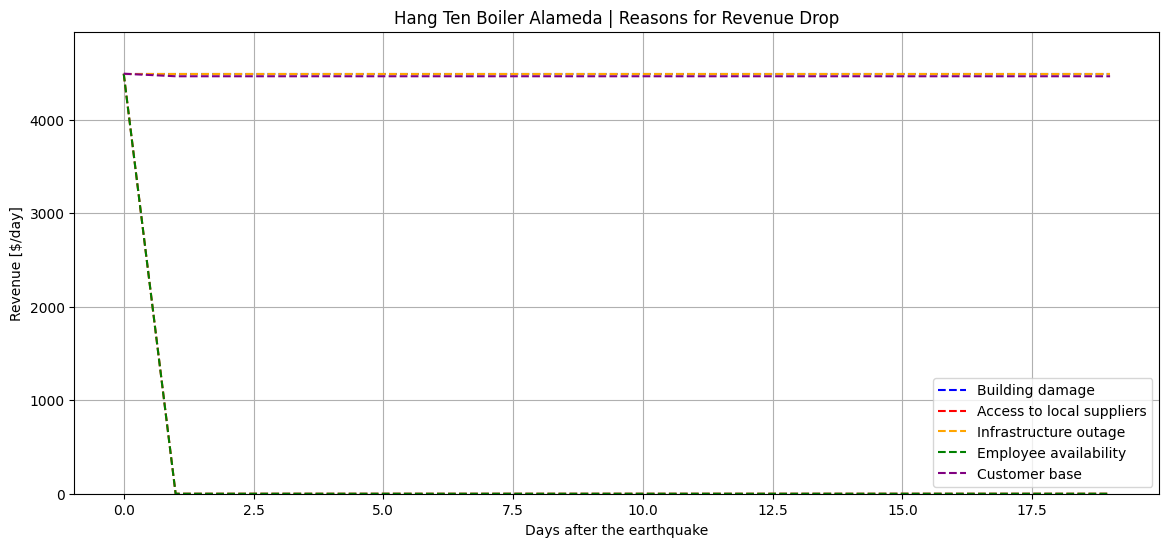

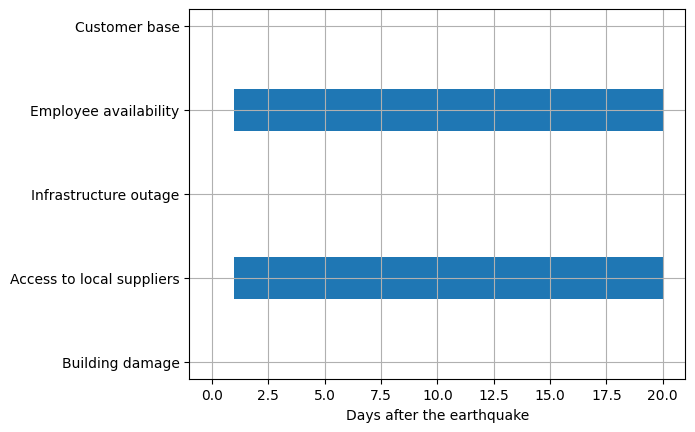

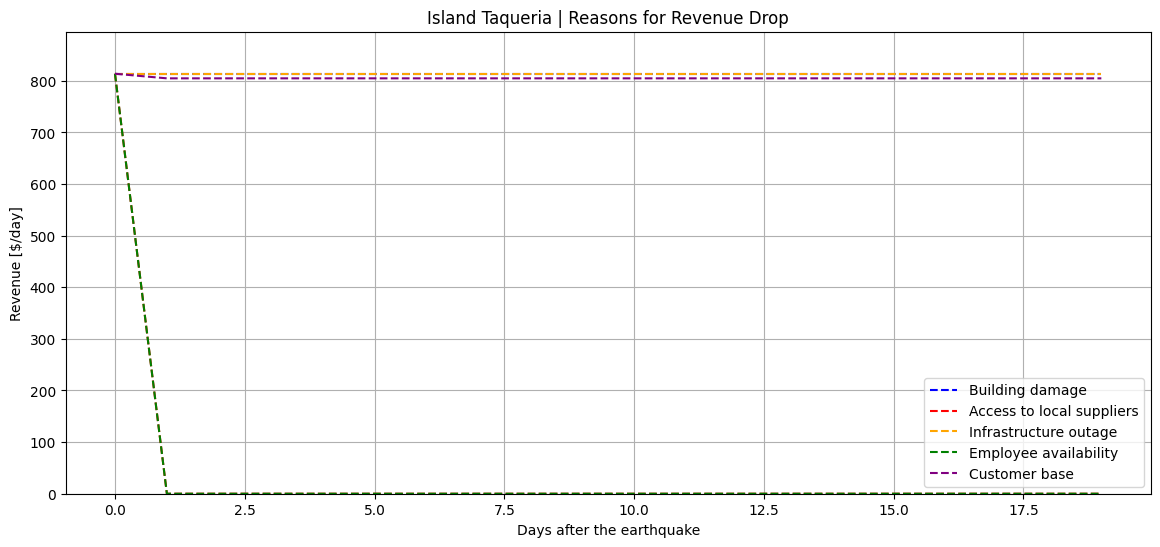

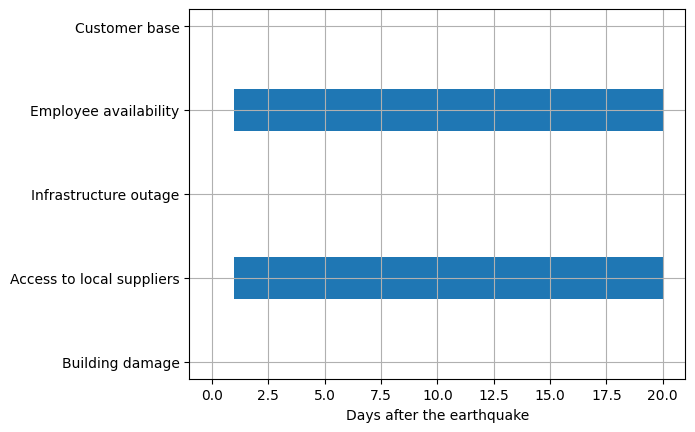

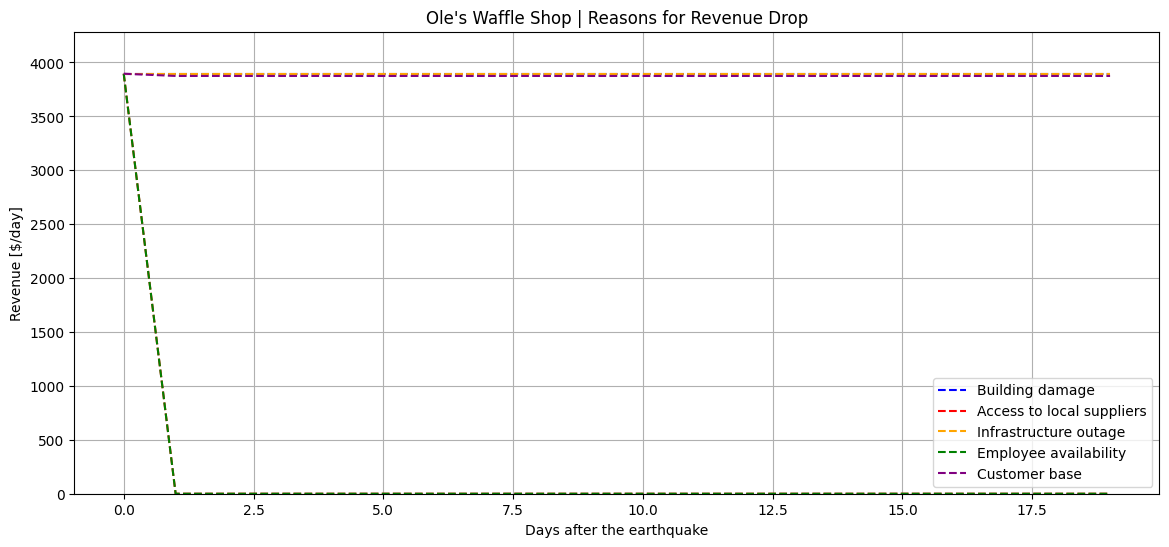

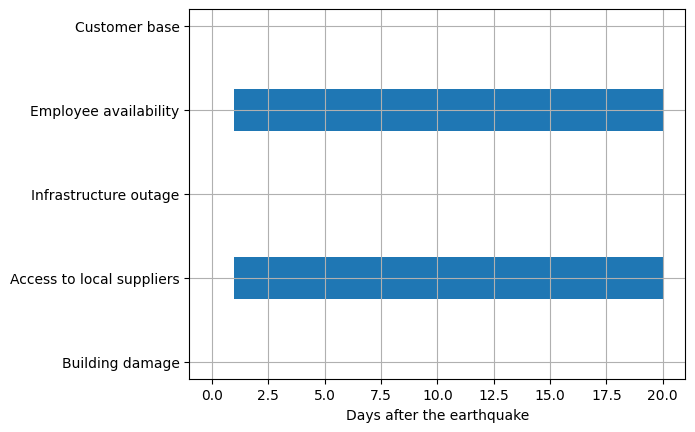

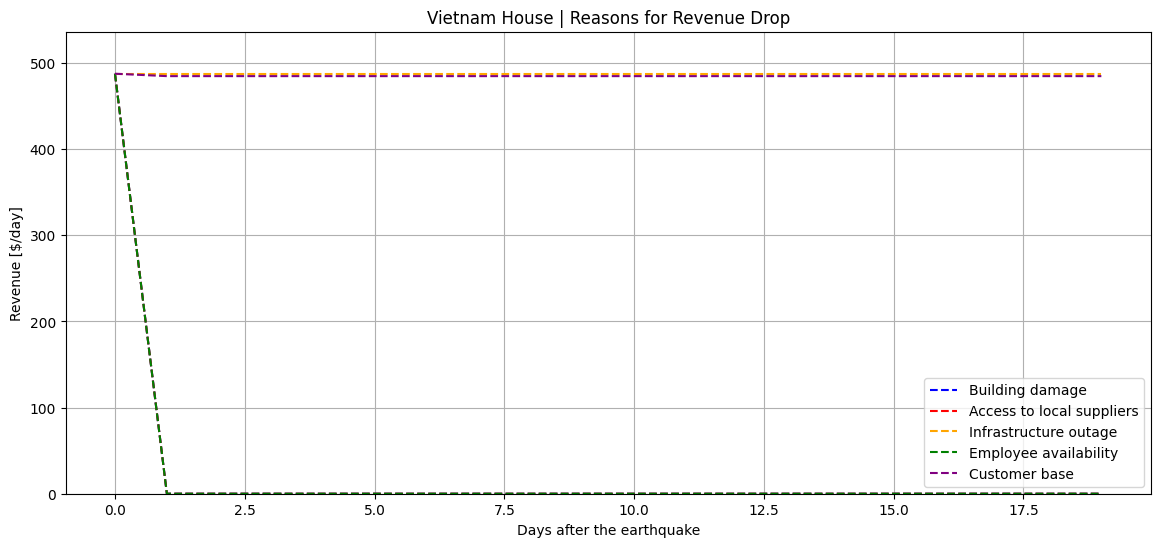

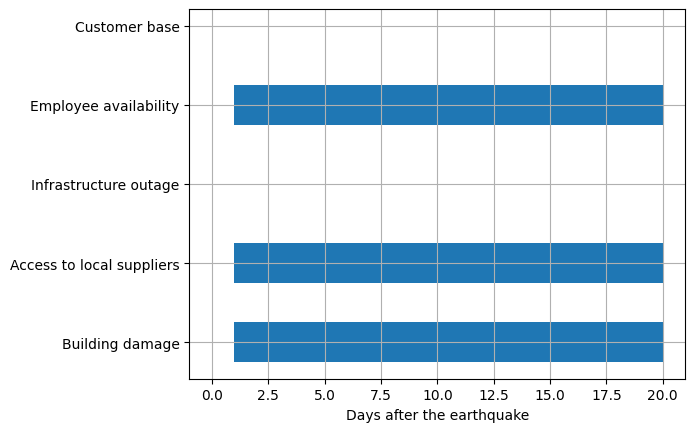

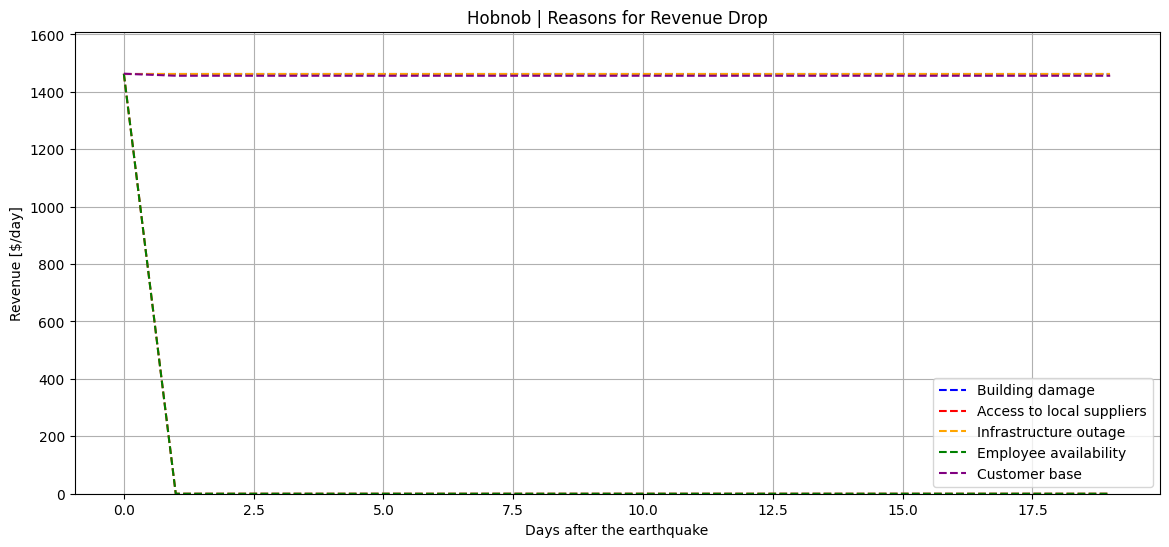

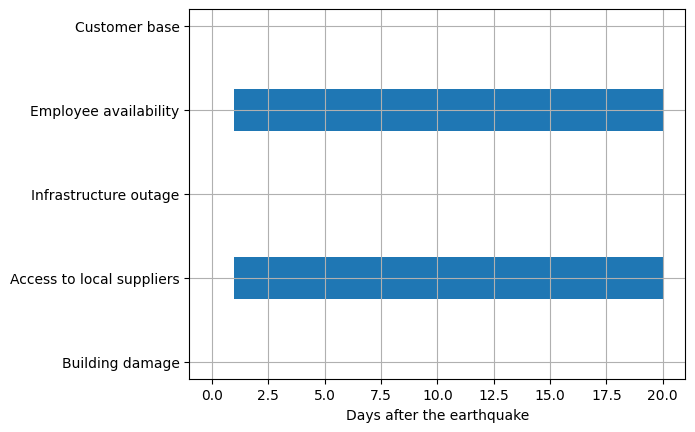

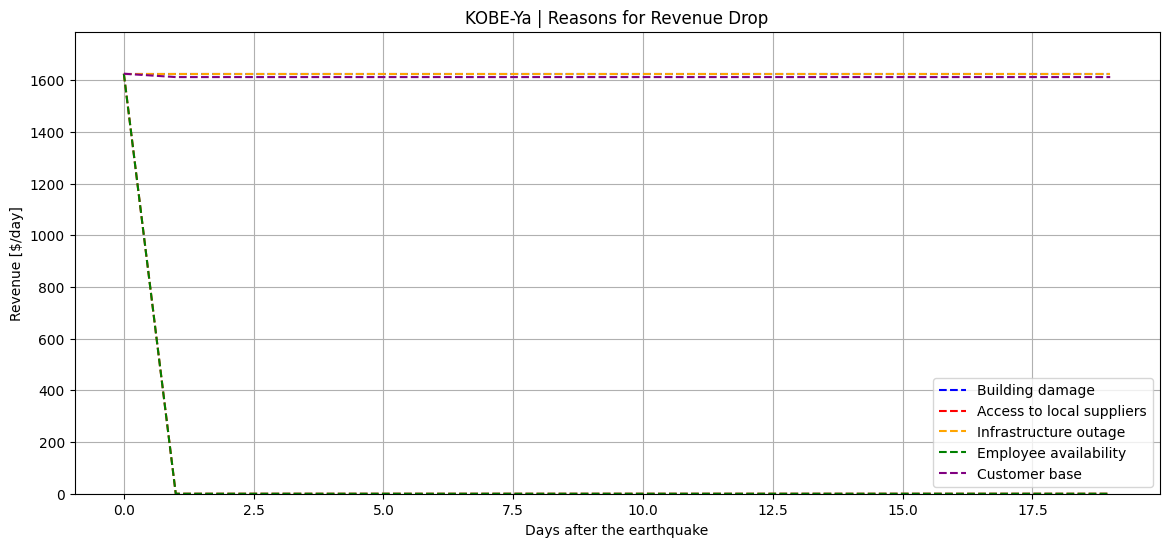

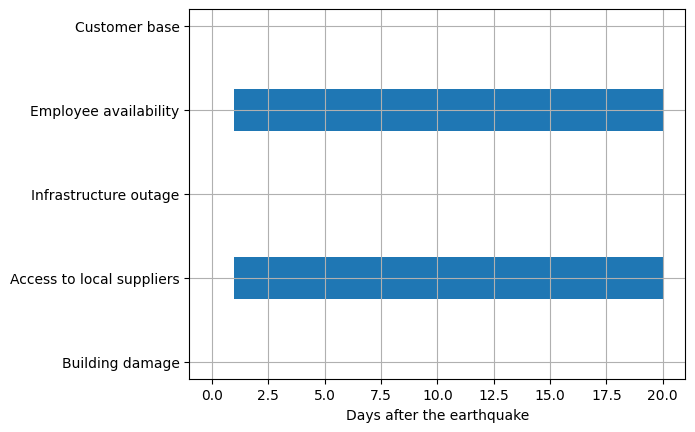

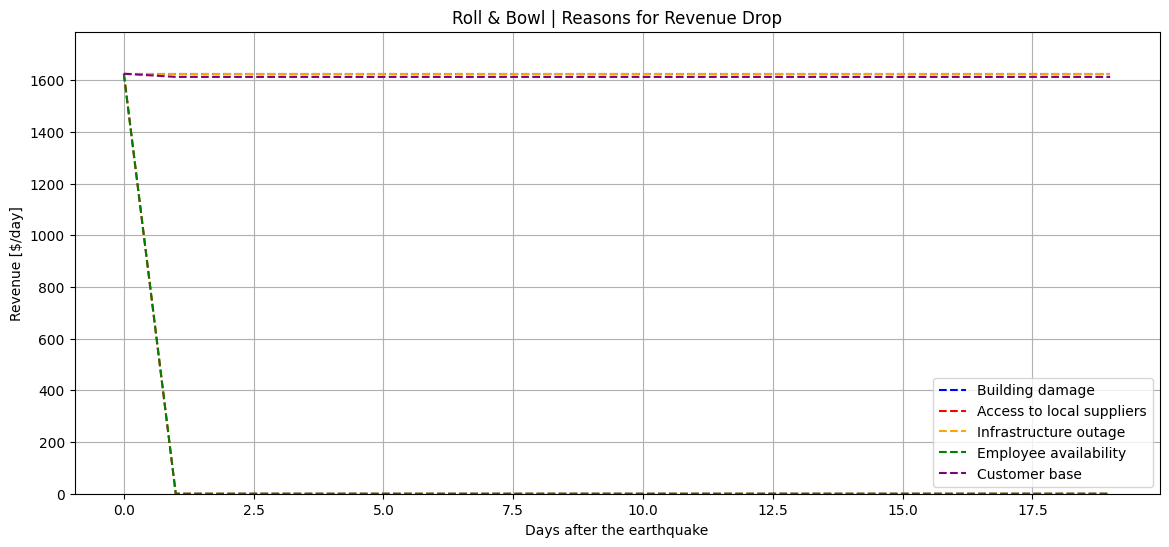

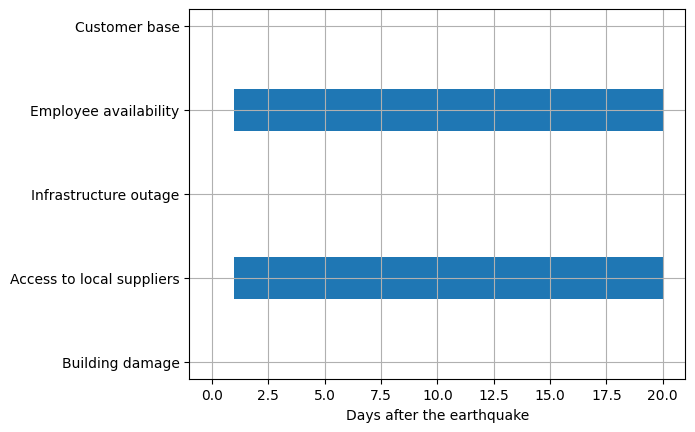

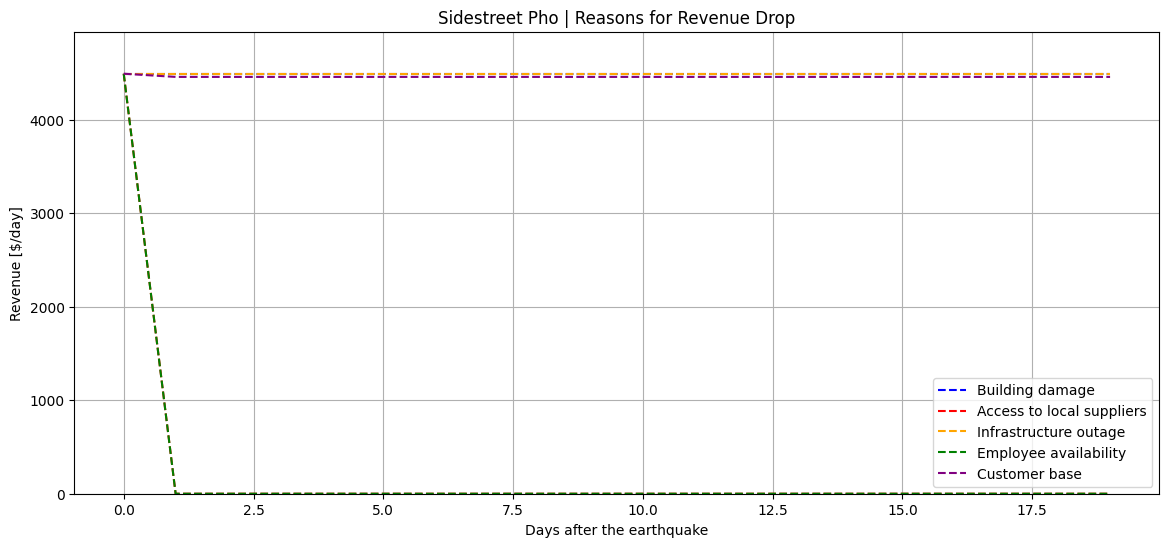

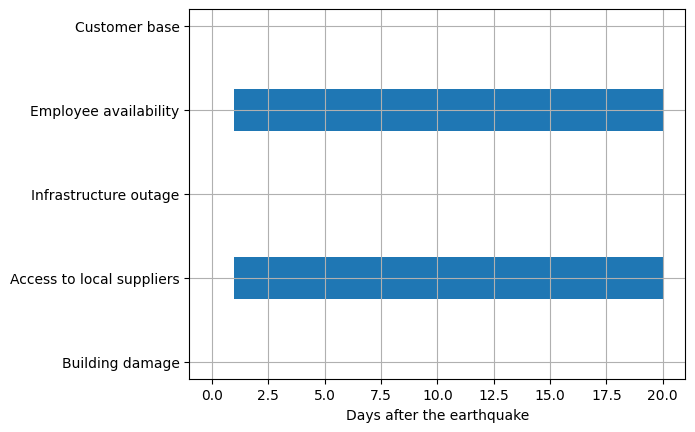

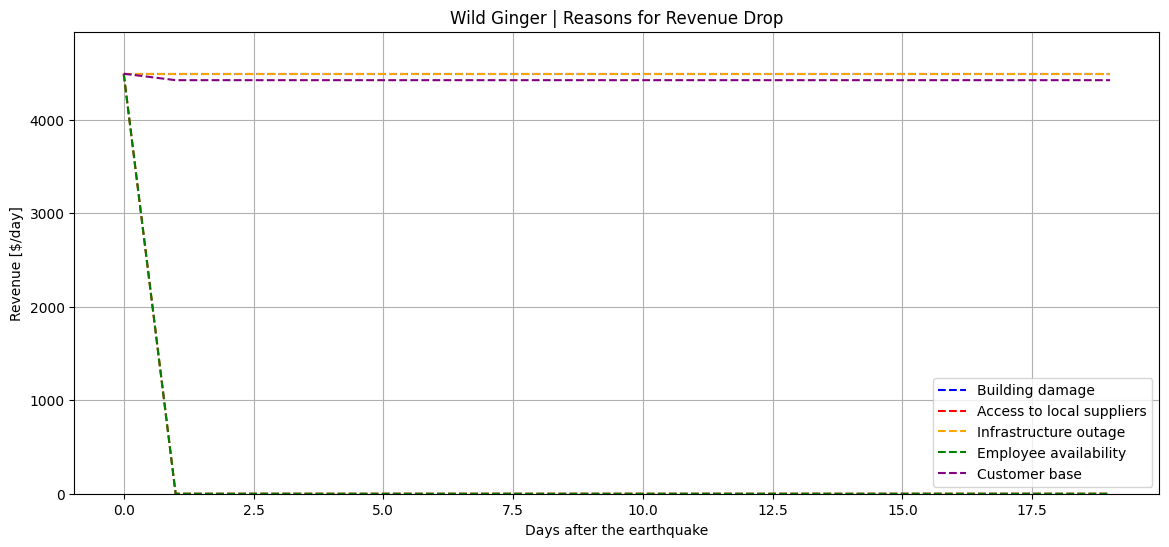

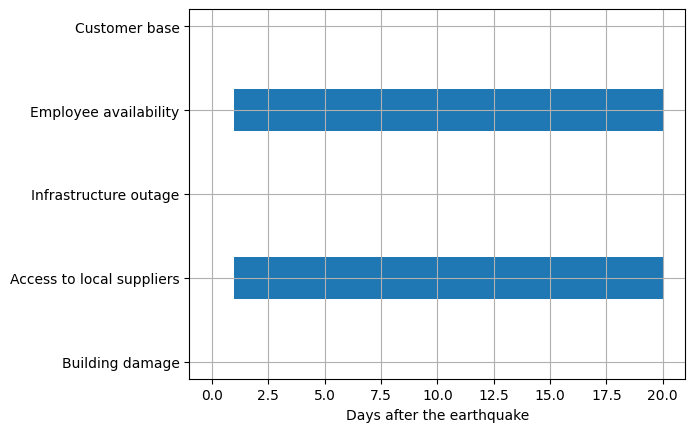

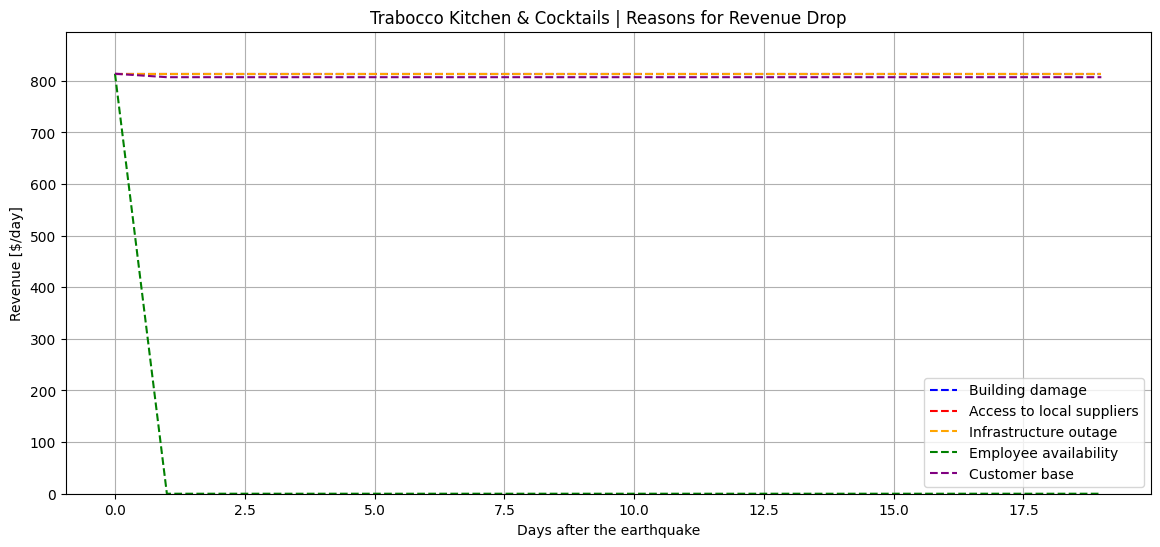

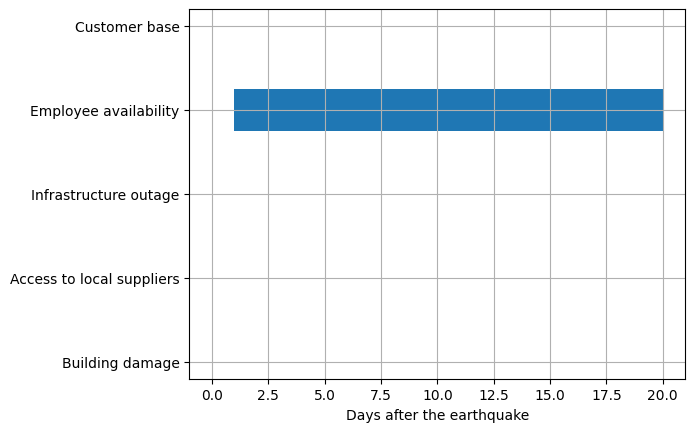

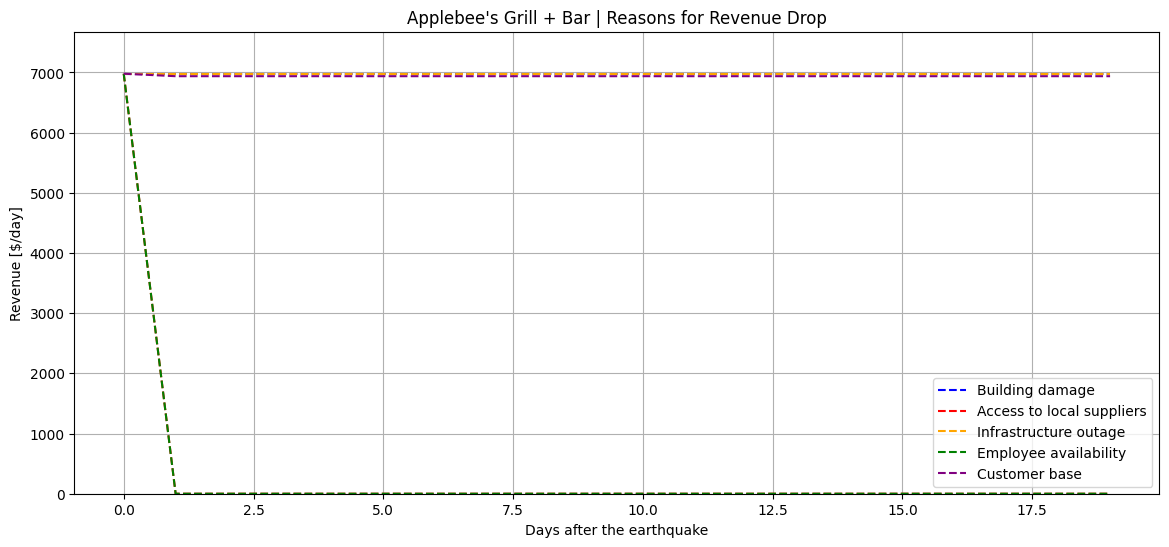

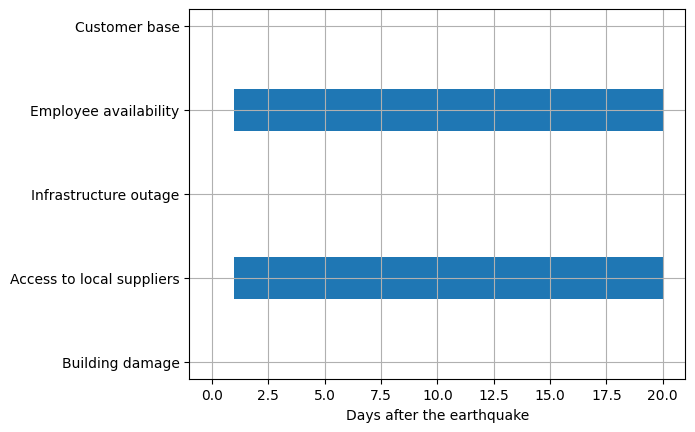

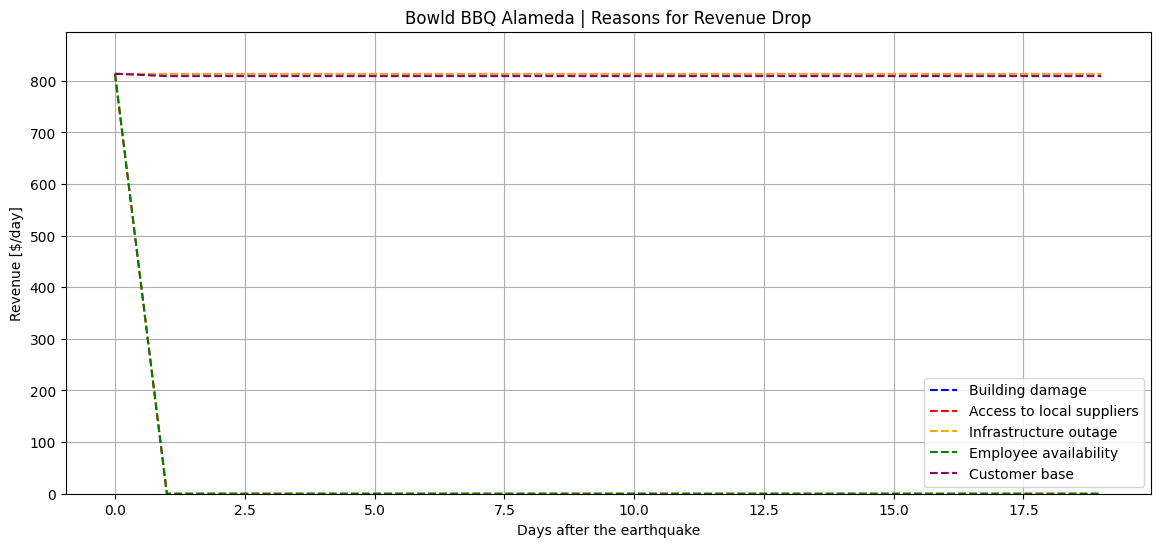

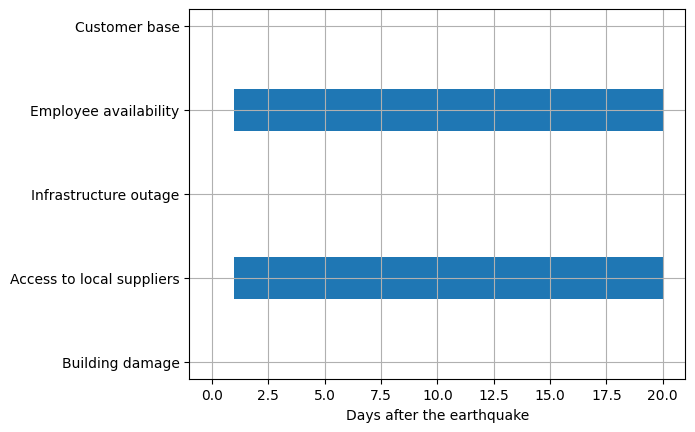

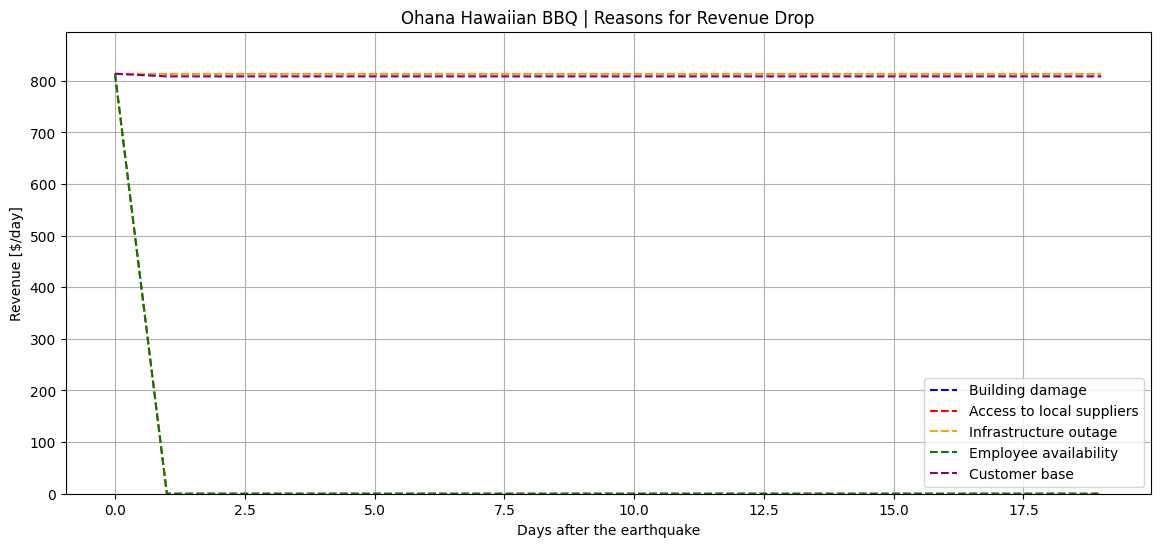

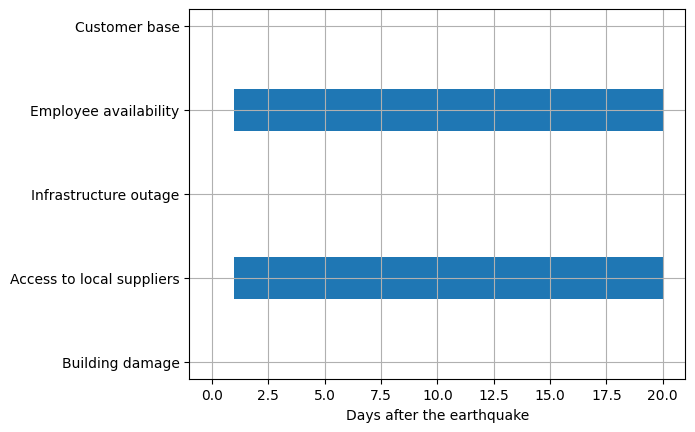

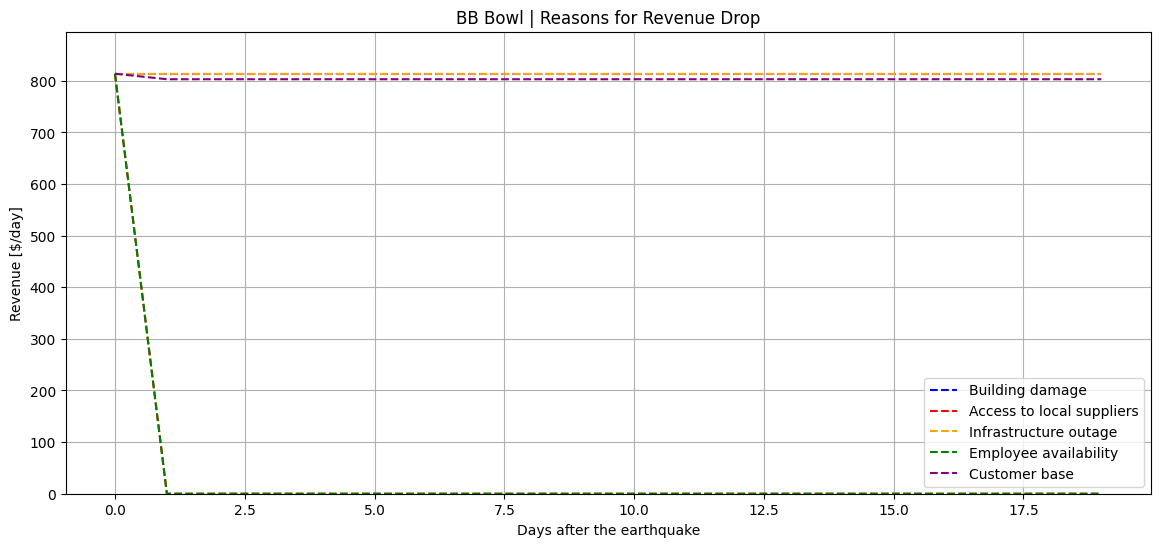

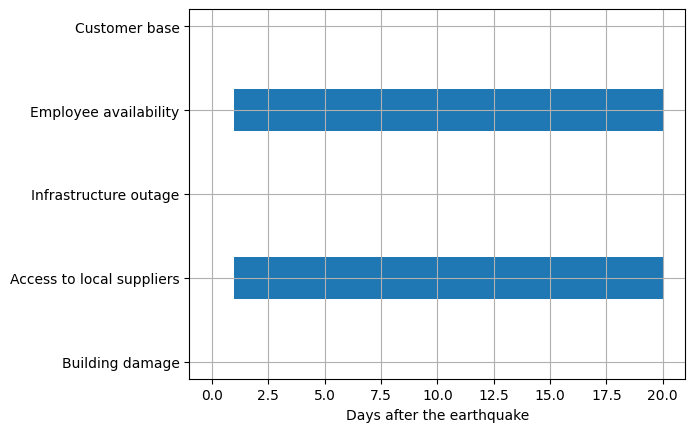

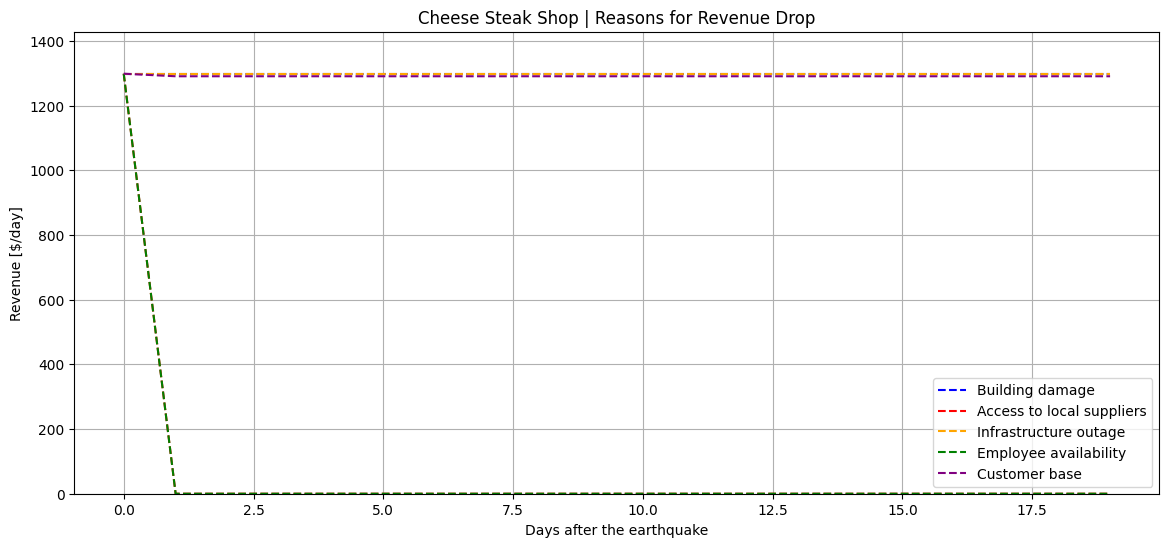

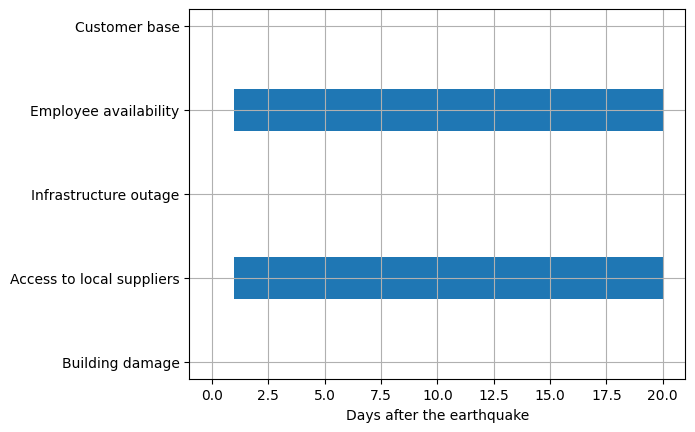

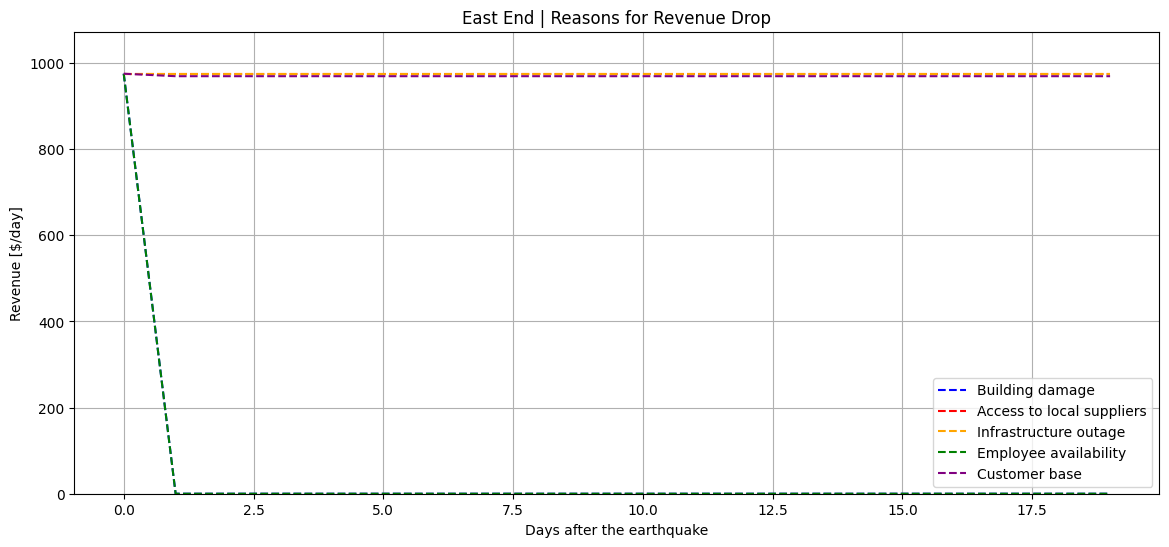

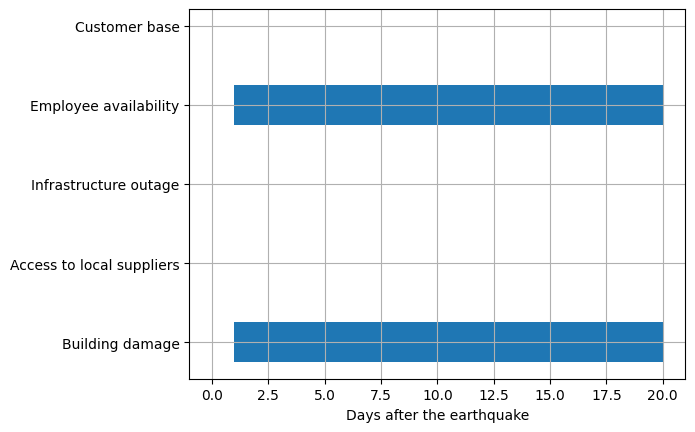

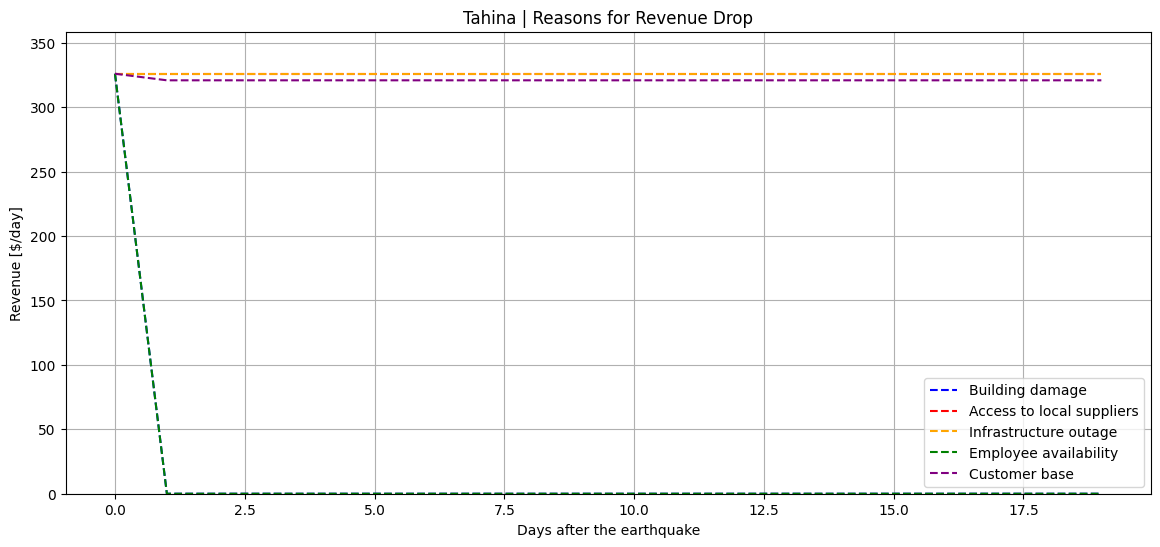

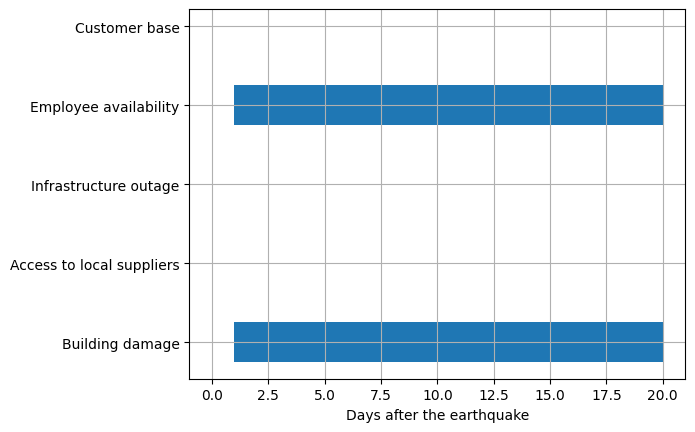

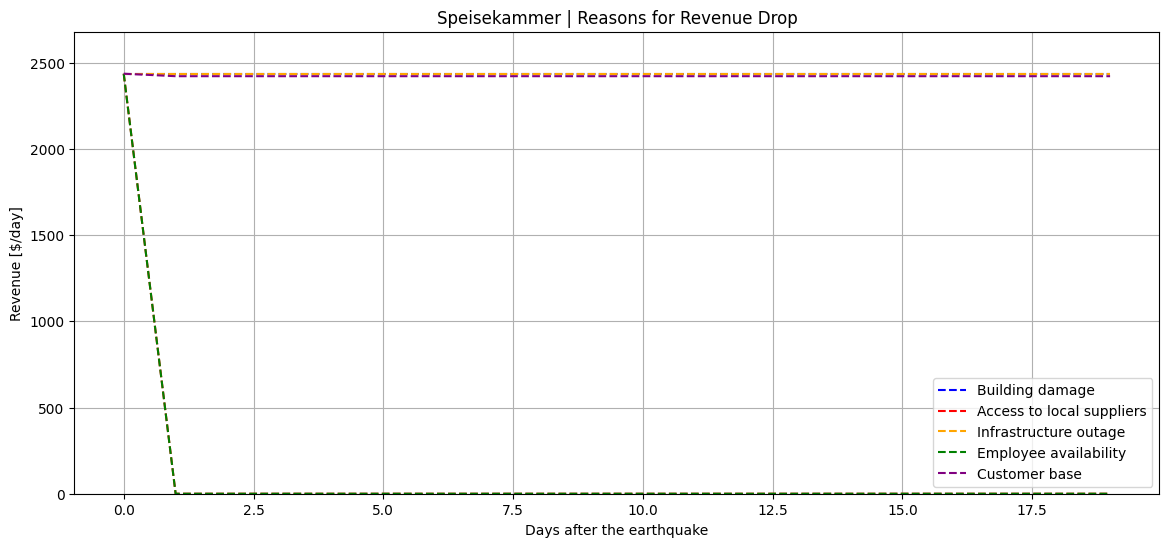

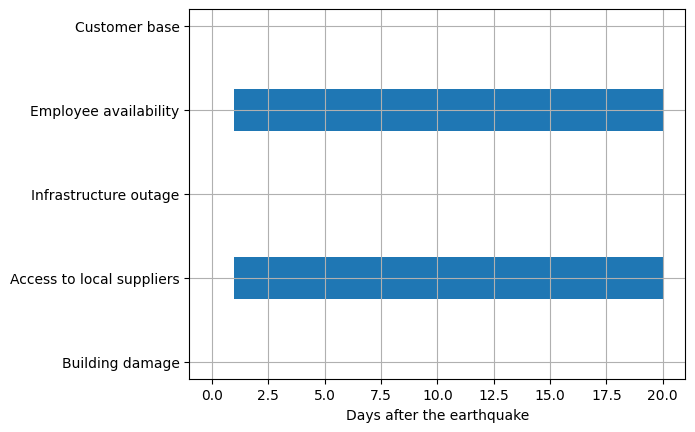

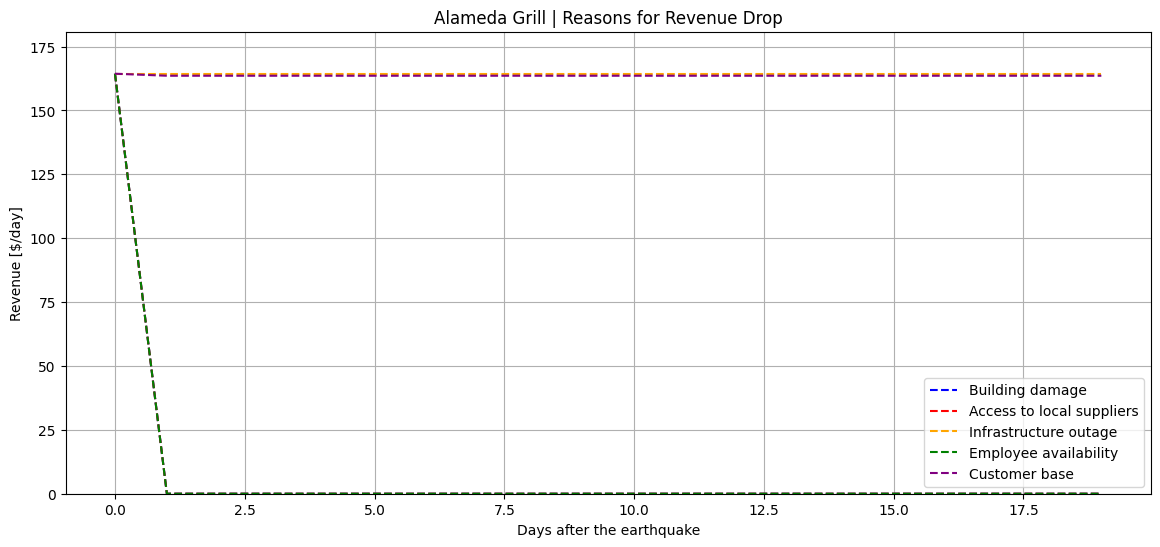

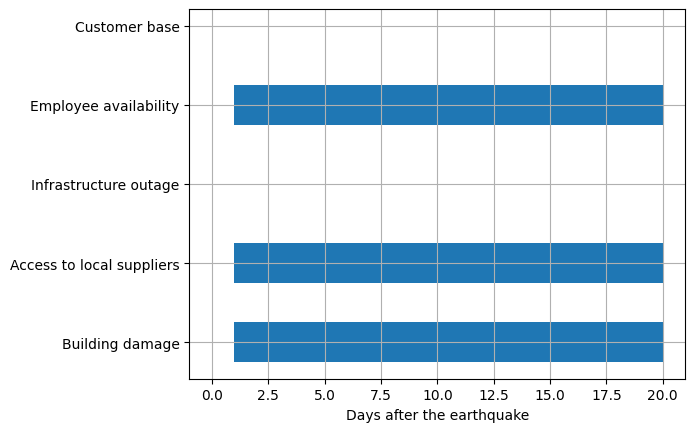

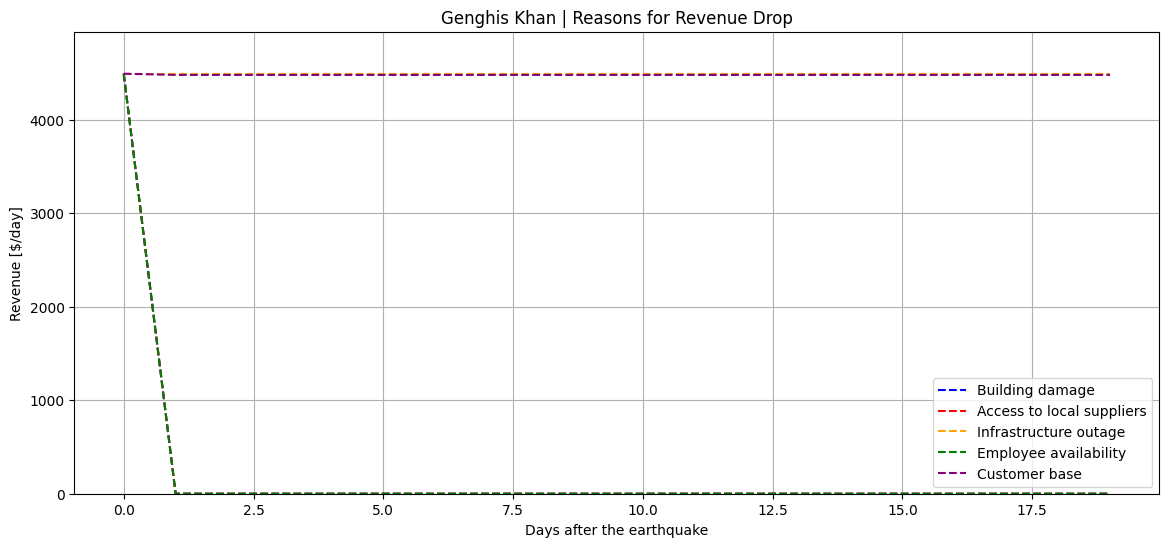

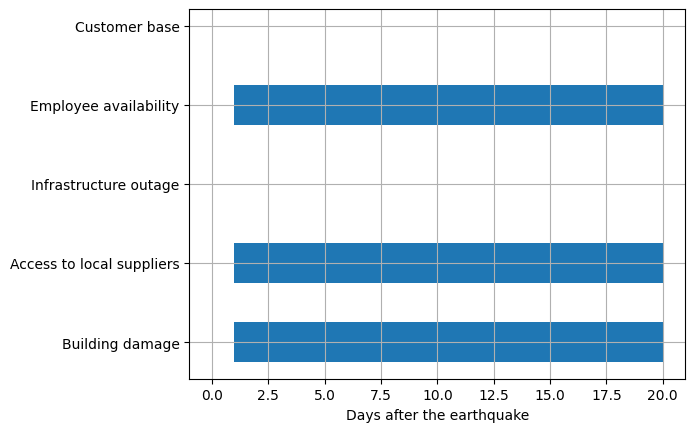

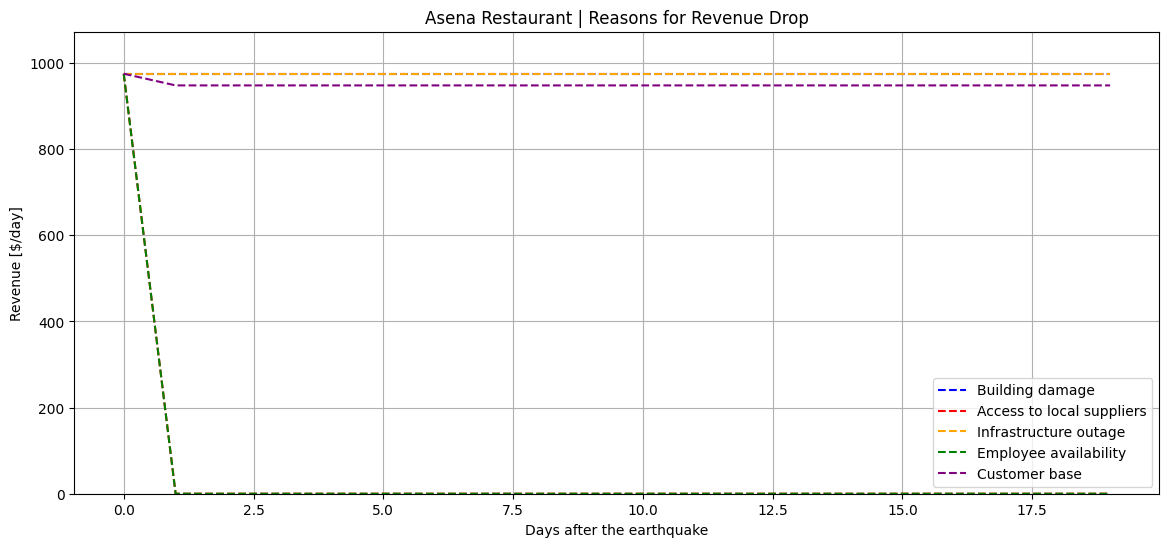

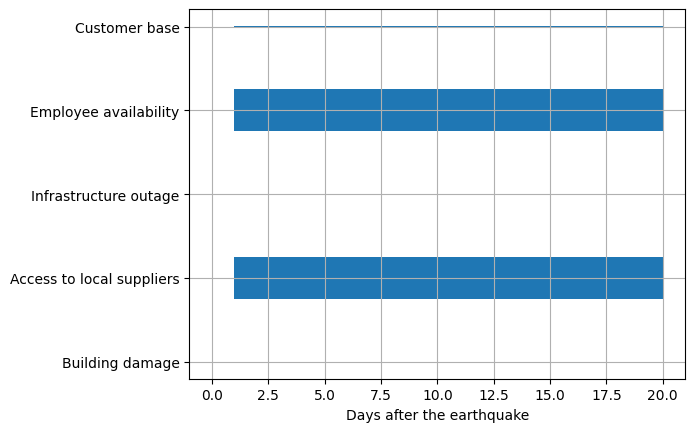

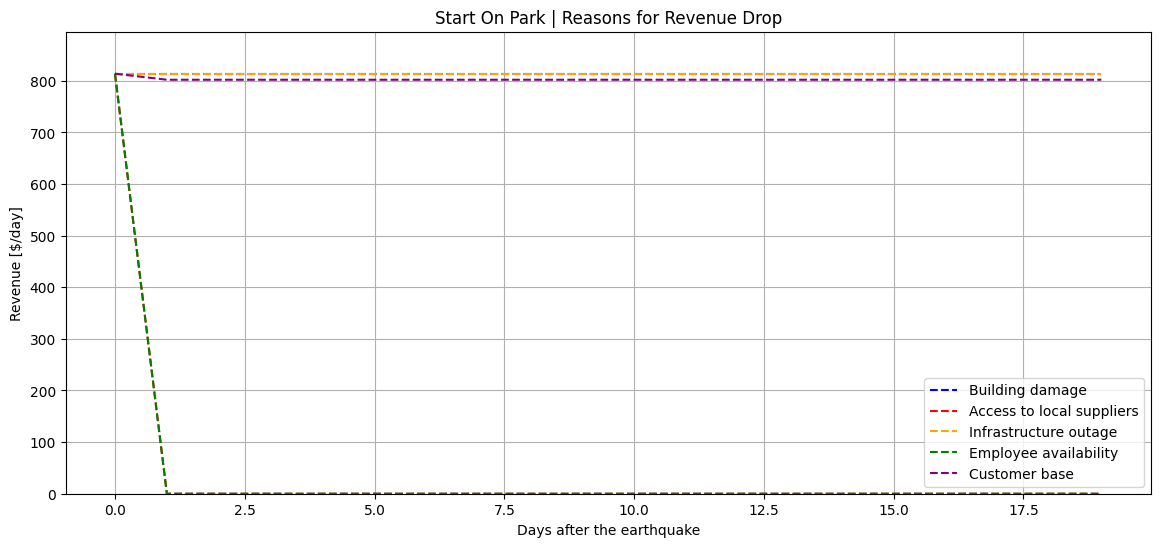

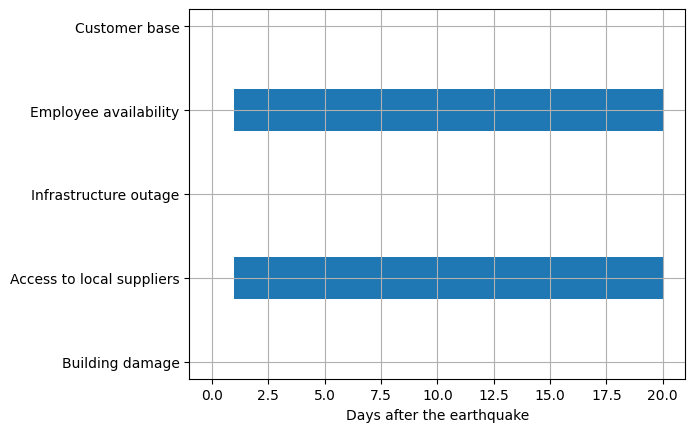

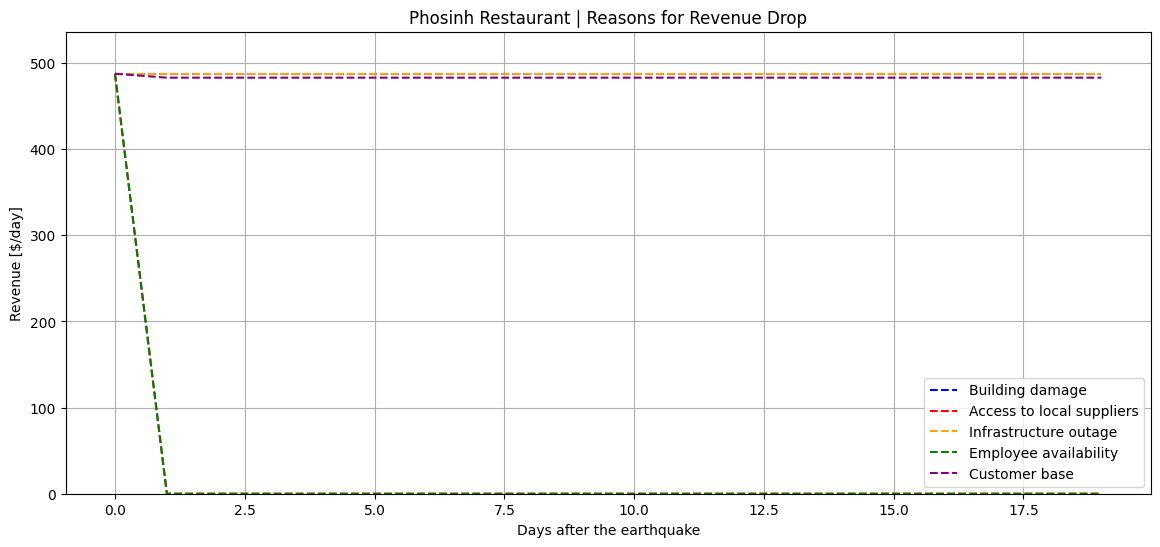

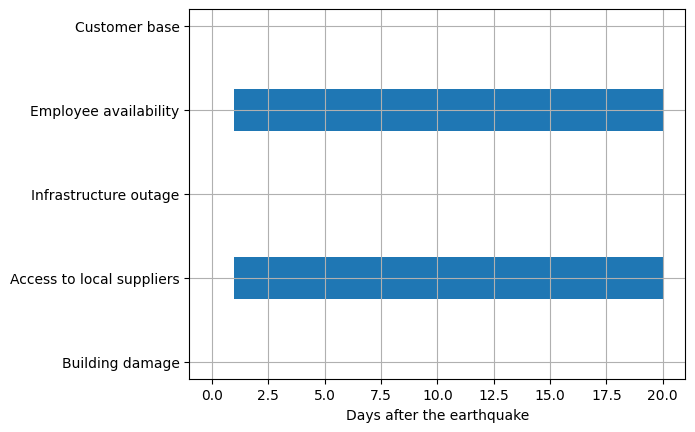

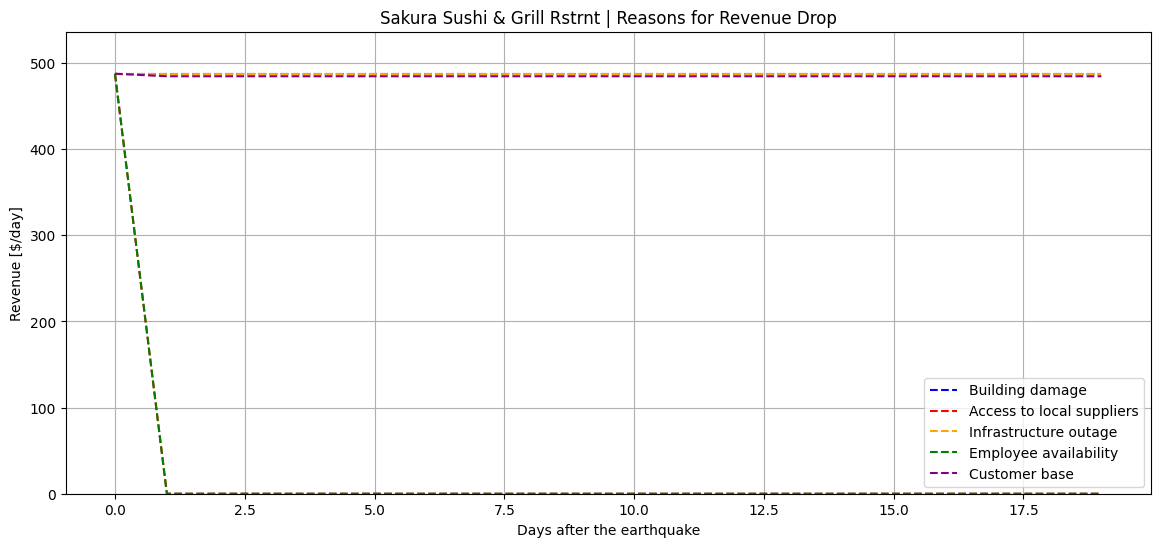

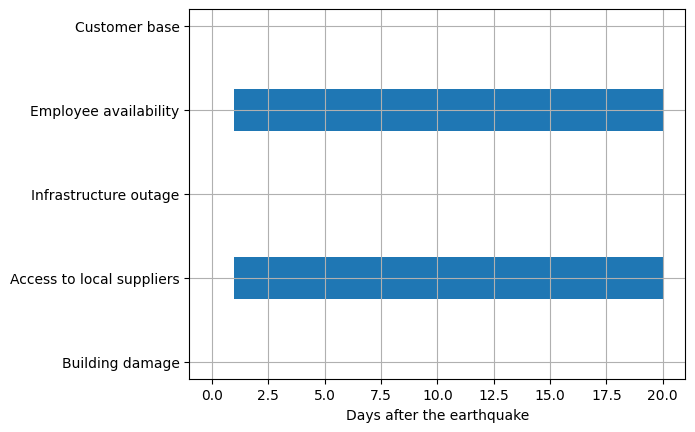

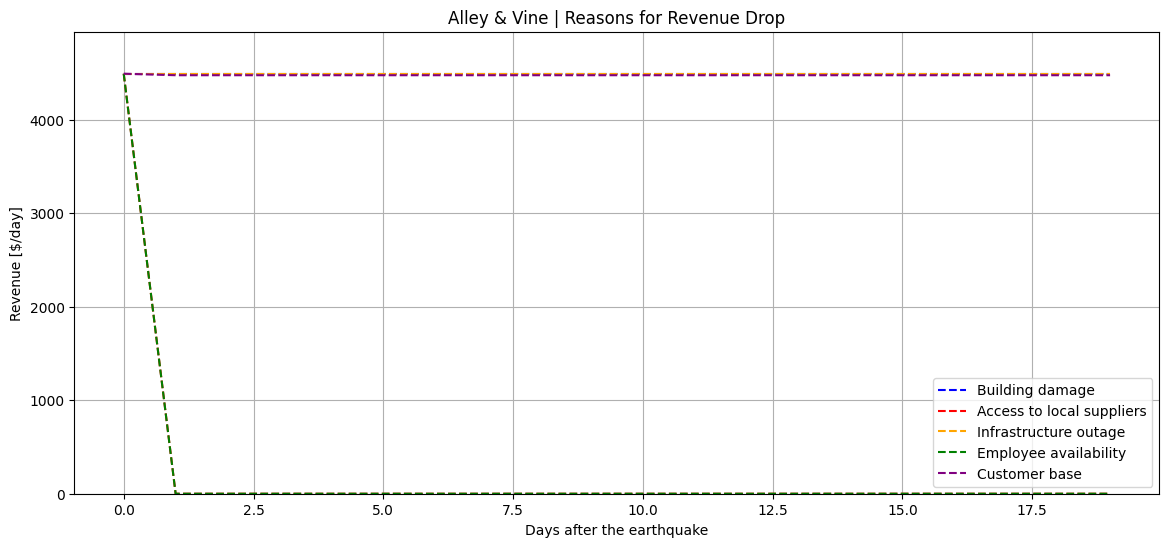

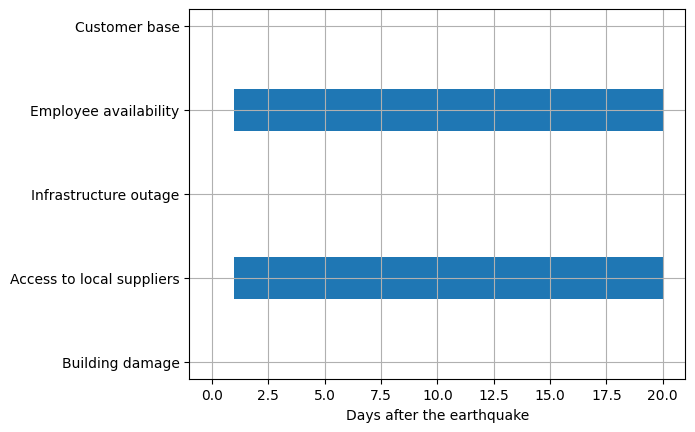

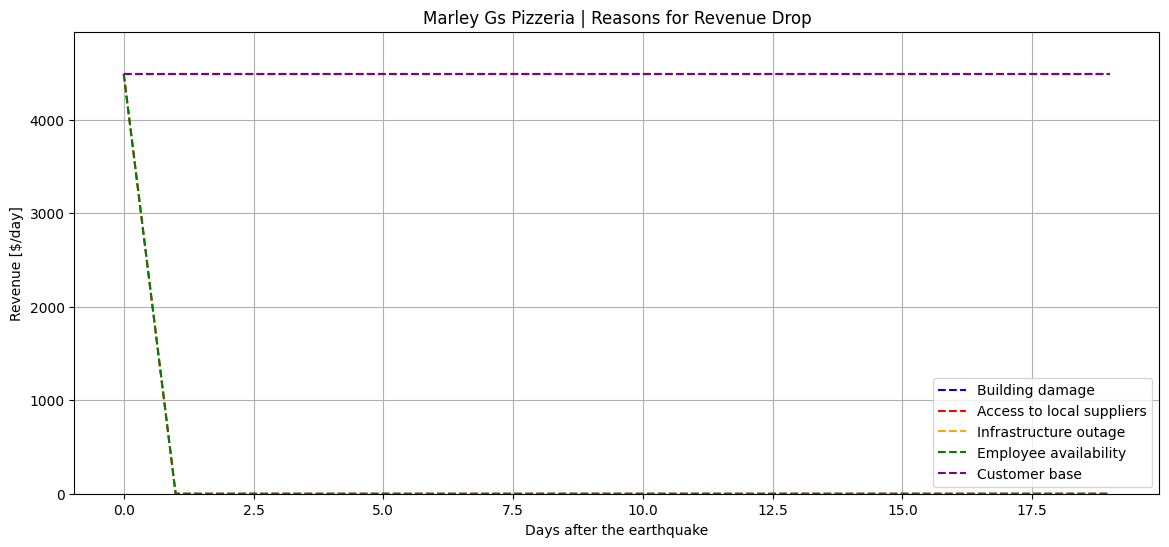

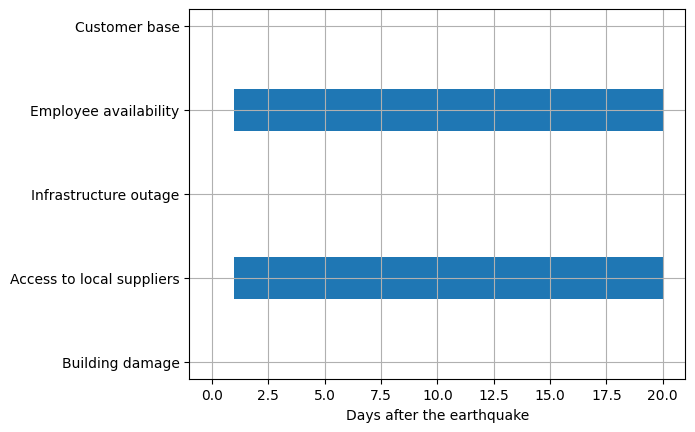

c:\Users\zhut\OneDrive - Stanford\Research\02 Work\05 Commercial downtime\Pyrecodes\20260312\pyrecodes_business\pyrecodes\plotter\business_plotter.py:53: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(bottom=0, top=max(max(data['Revenue']) for data in reasons_as_lines.values()) * 1.1)


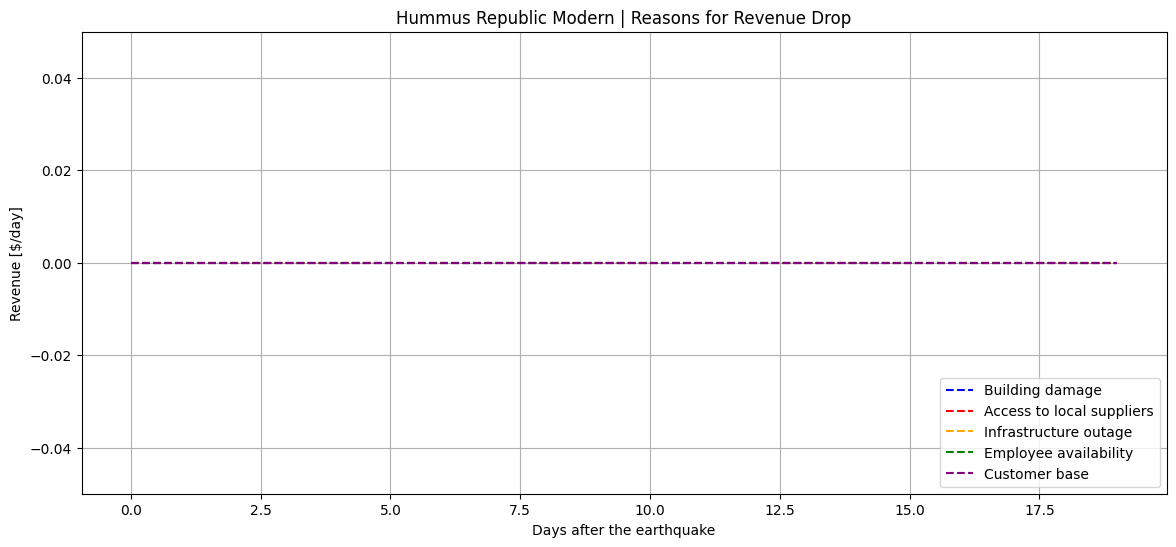

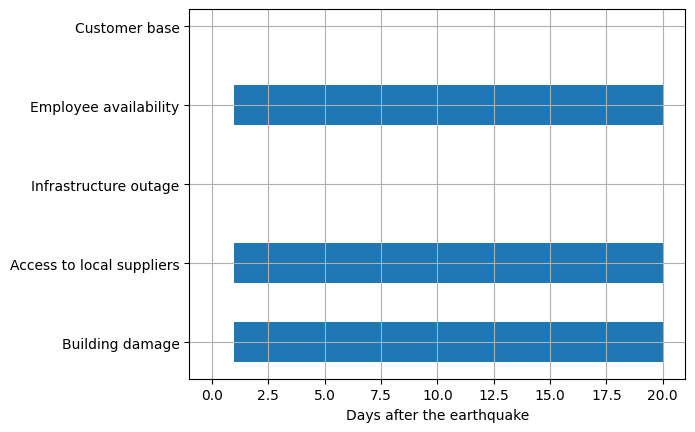

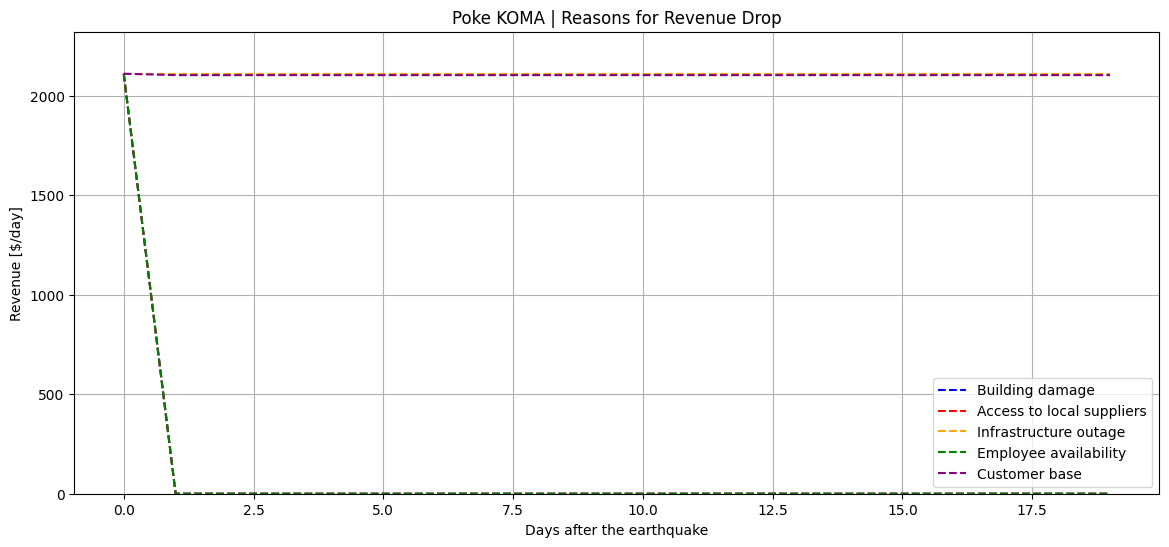

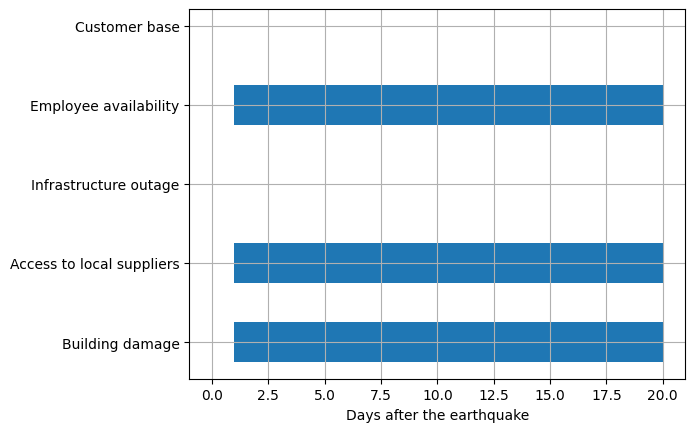

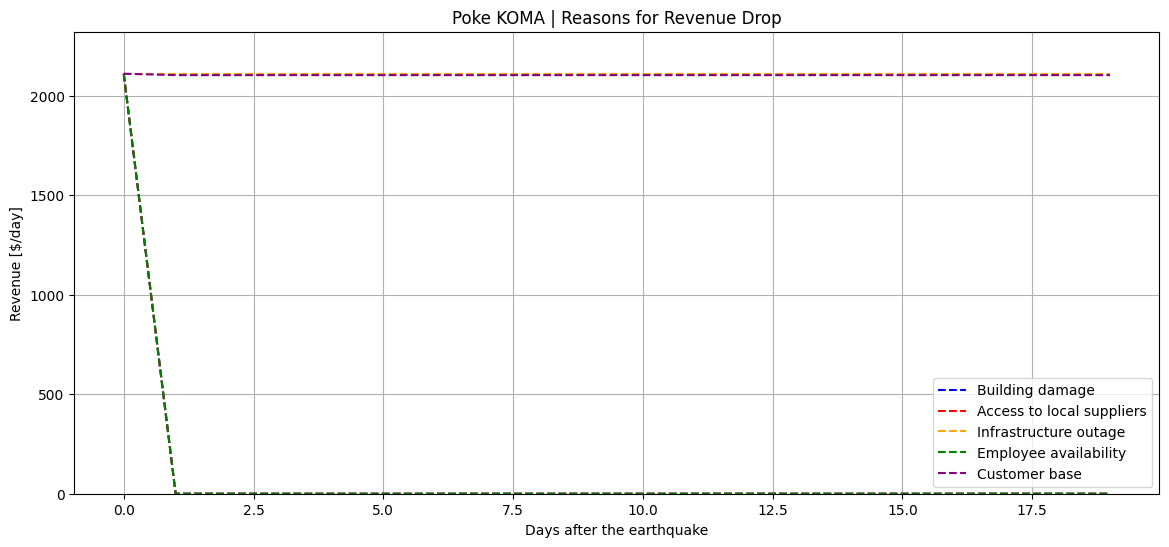

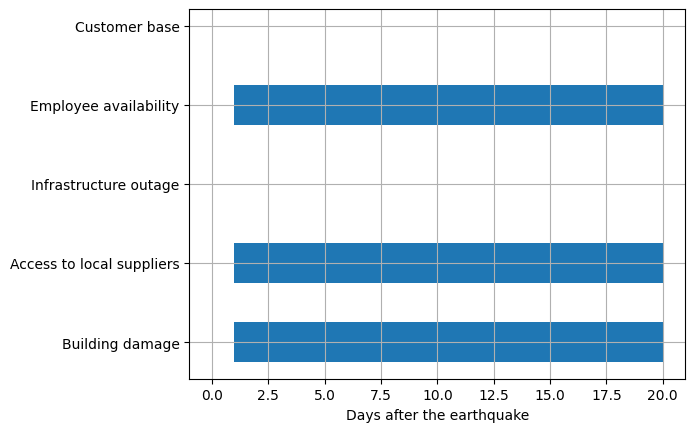

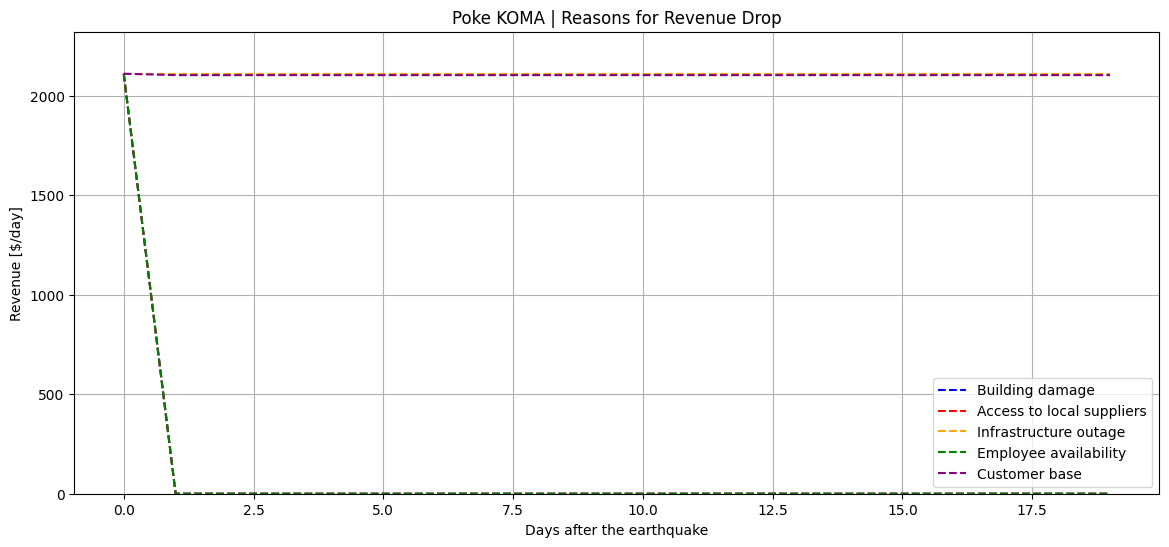

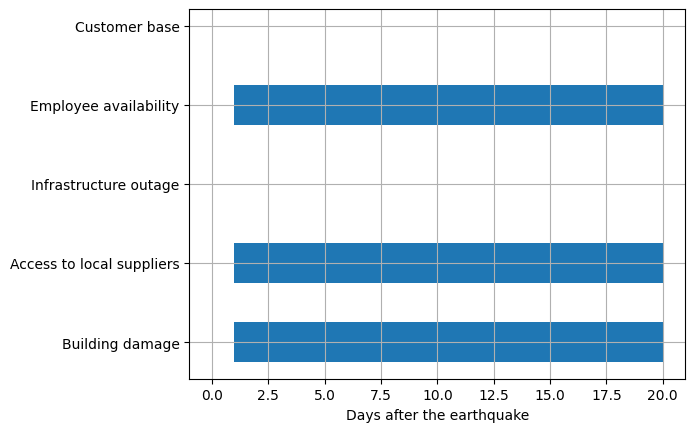

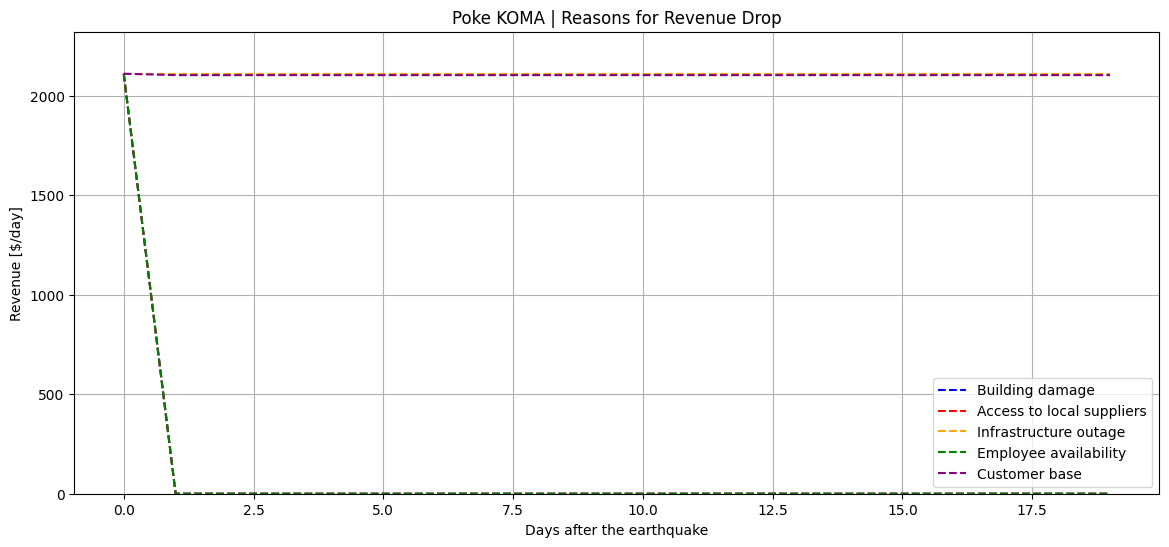

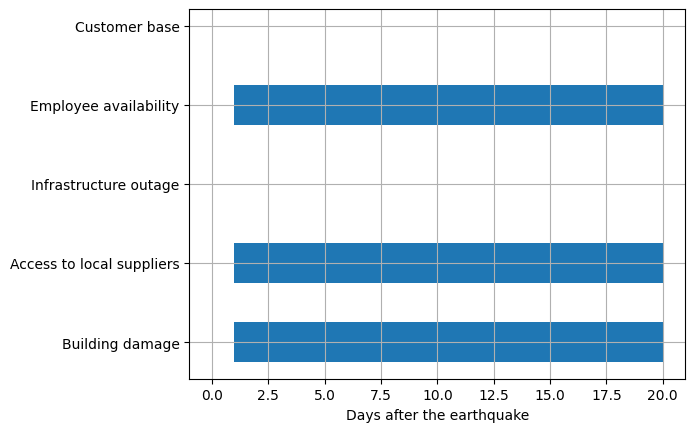

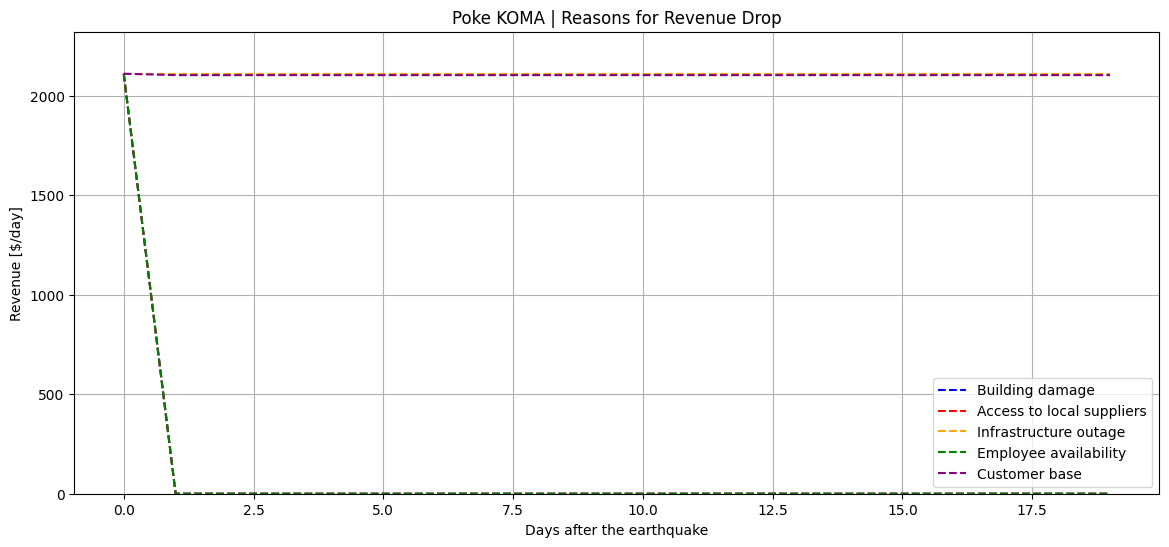

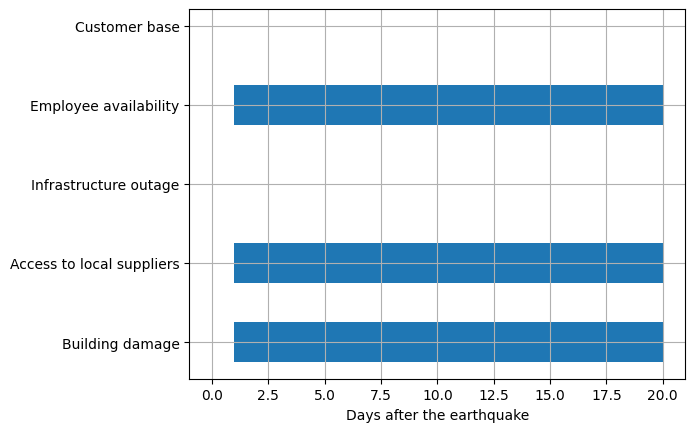

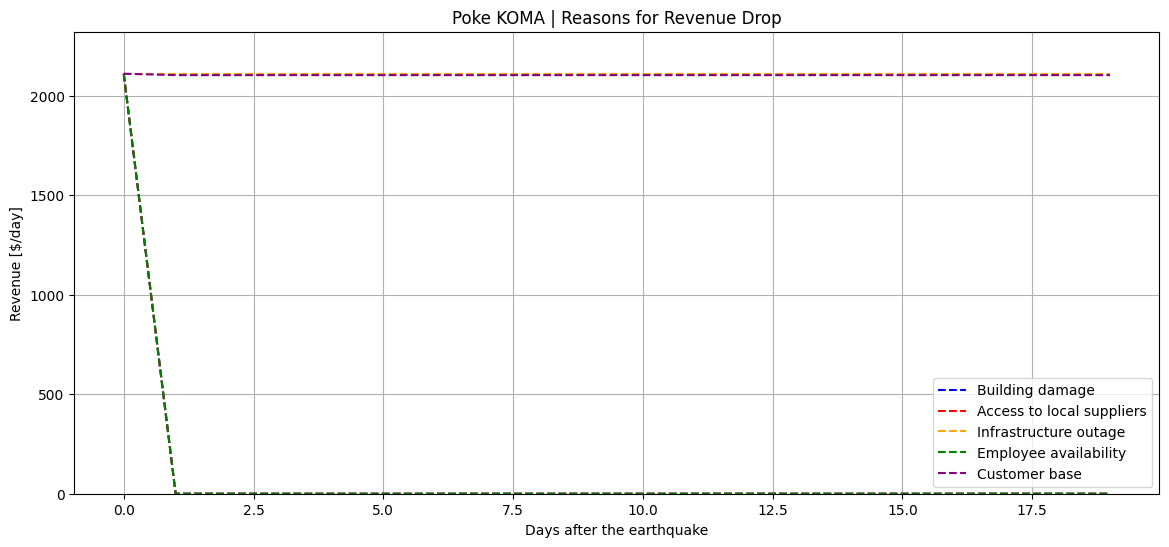

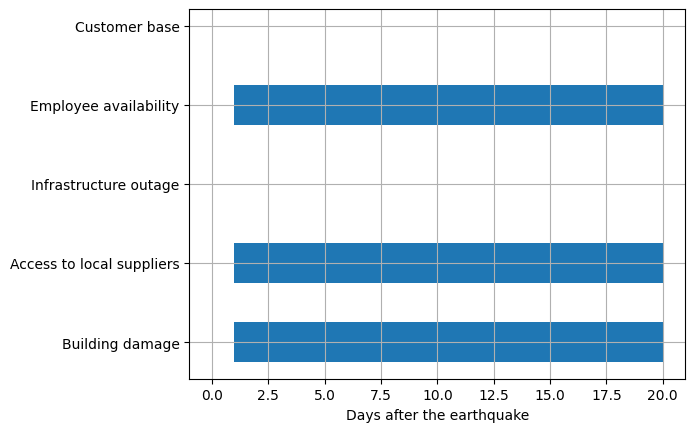

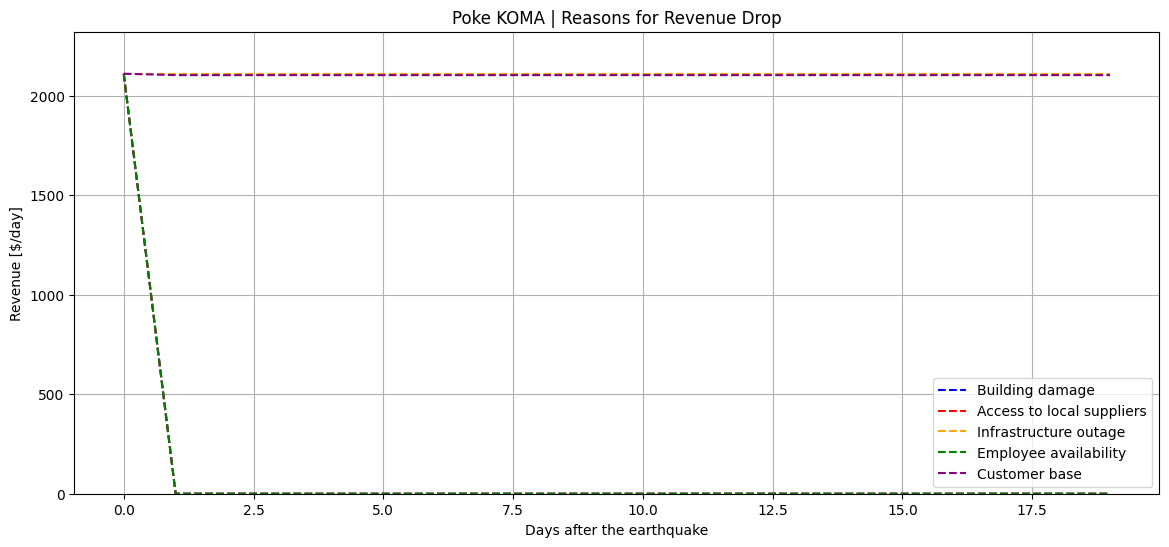

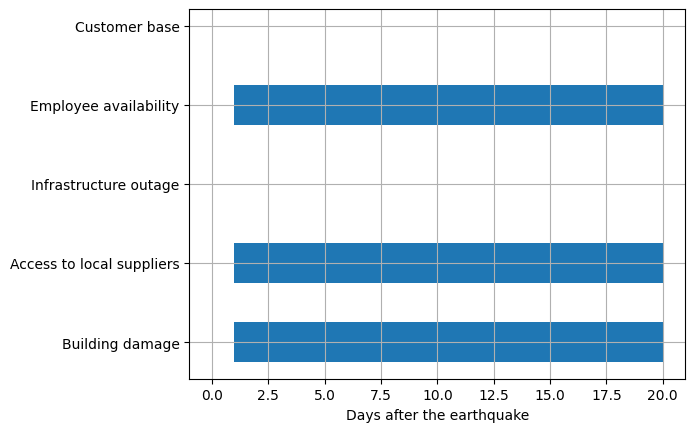

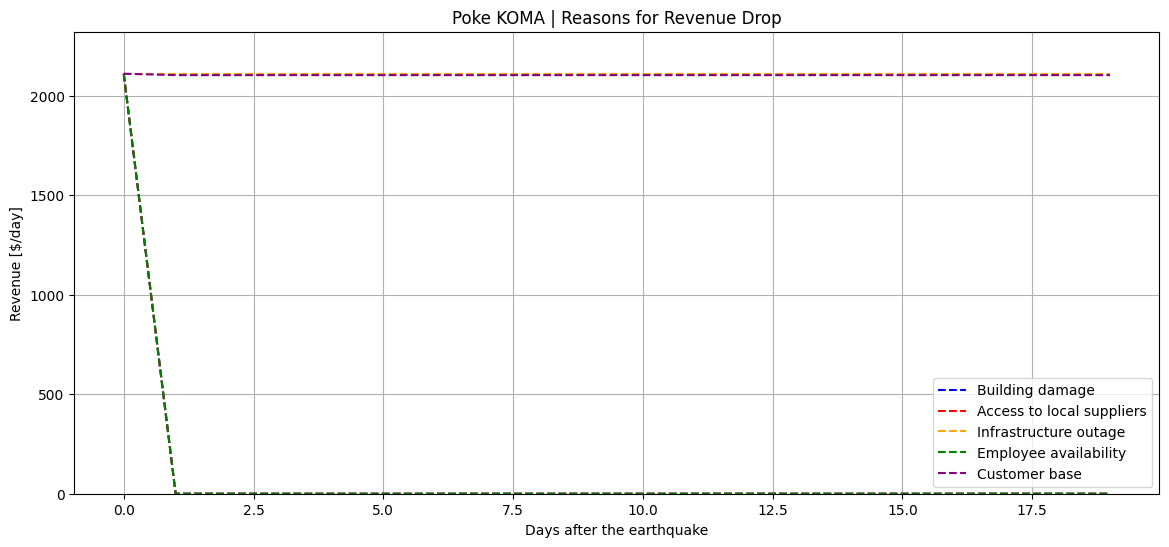

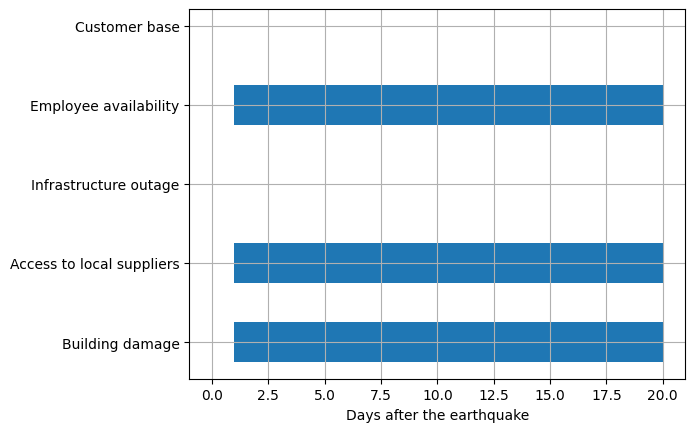

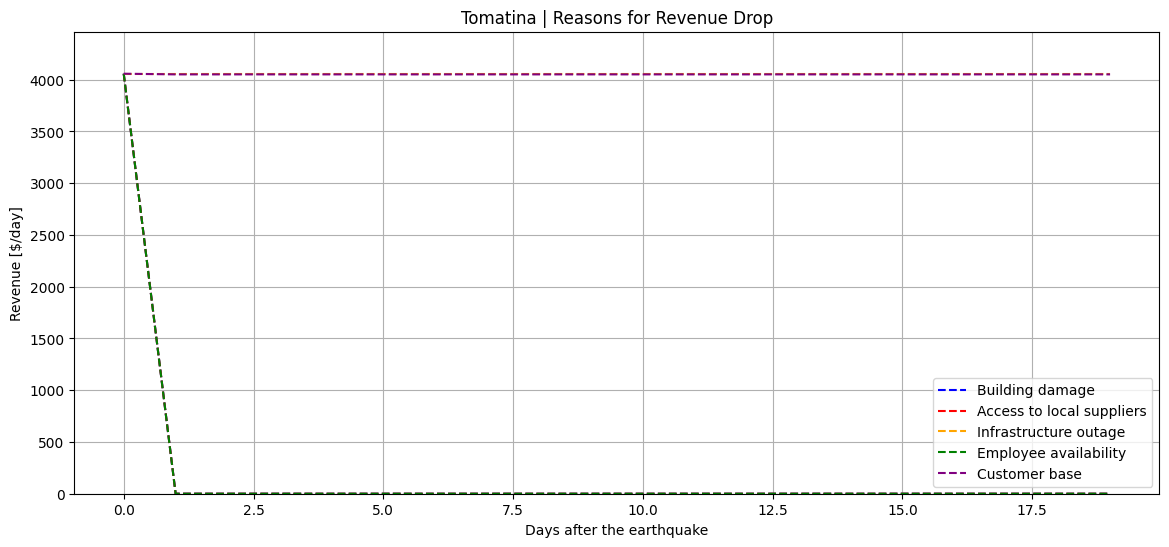

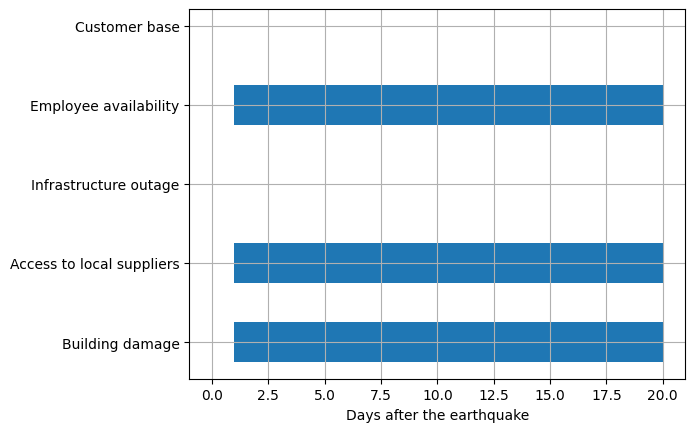

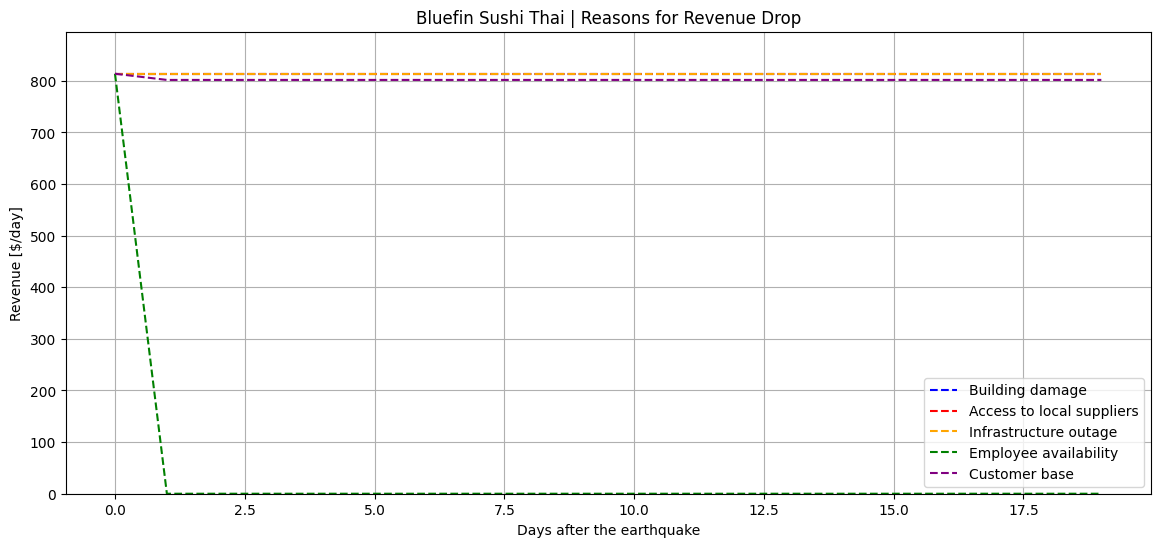

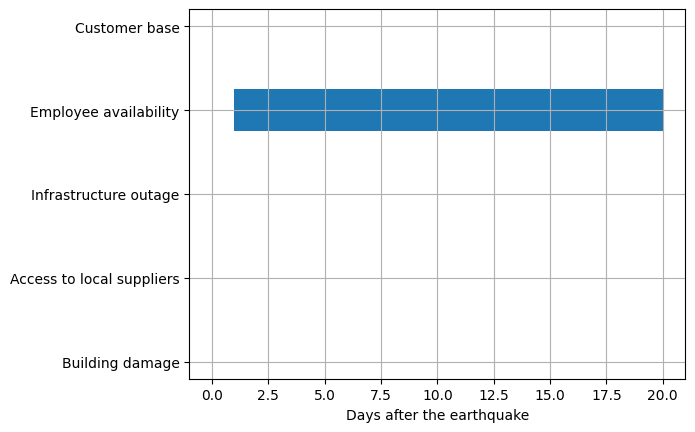

In [2]:
import random

from pyrecodes.plotter.business_plotter import BusinessPlotter

business_plotter = BusinessPlotter()
business_resilience_calculator = system.resilience_calculators[-1]

for business_to_plot in business_resilience_calculator.businesses:
    reasons_for_drop = business_plotter.get_reasons_for_drop(business_to_plot)
    reasons_as_lines = business_plotter.get_reasons_for_drop_as_lines(reasons_for_drop)
    # business_plotter.plot_business_revenue(business_resilience_calculator.business_revenue[business_to_plot], business_to_plot, save_fig=False, show_fig=True)
    # business_plotter.plot_business_revenue_reasons_for_drop_lines(business_to_plot, reasons_as_lines, reasons_to_plot=['Home Component Functionality'], save_fig=False, show_fig=True)
    # business_plotter.plot_business_revenue_reasons_for_drop_lines(business_to_plot, reasons_as_lines, reasons_to_plot=['Home Component Functionality', 'Customer Base'], save_fig=False, show_fig=True)
    # business_plotter.plot_business_revenue_reasons_for_drop_lines(business_to_plot, reasons_as_lines, reasons_to_plot=['Home Component Functionality', 'Customer Base', 'LocalSuppliers'], save_fig=False, show_fig=True)
    # business_plotter.plot_business_revenue_reasons_for_drop_lines(business_to_plot, reasons_as_lines, reasons_to_plot=['Home Component Functionality', 'Customer Base', 'LocalSuppliers', 'Labor'], save_fig=False, show_fig=True)
    # business_plotter.plot_business_revenue_reasons_for_drop_lines(business_to_plot, reasons_as_lines, reasons_to_plot=['Home Component Functionality', 'Customer Base', 'LocalSuppliers', 'Labor', 'Infrastructure'], save_fig=False, show_fig=True)
    business_plotter.plot_business_revenue_reasons_for_drop_lines(business_to_plot, reasons_as_lines, save_fig=False, show_fig=True)
    business_plotter.plot_business_gantt_chart(business_to_plot, save_fig=False, show_fig=True)

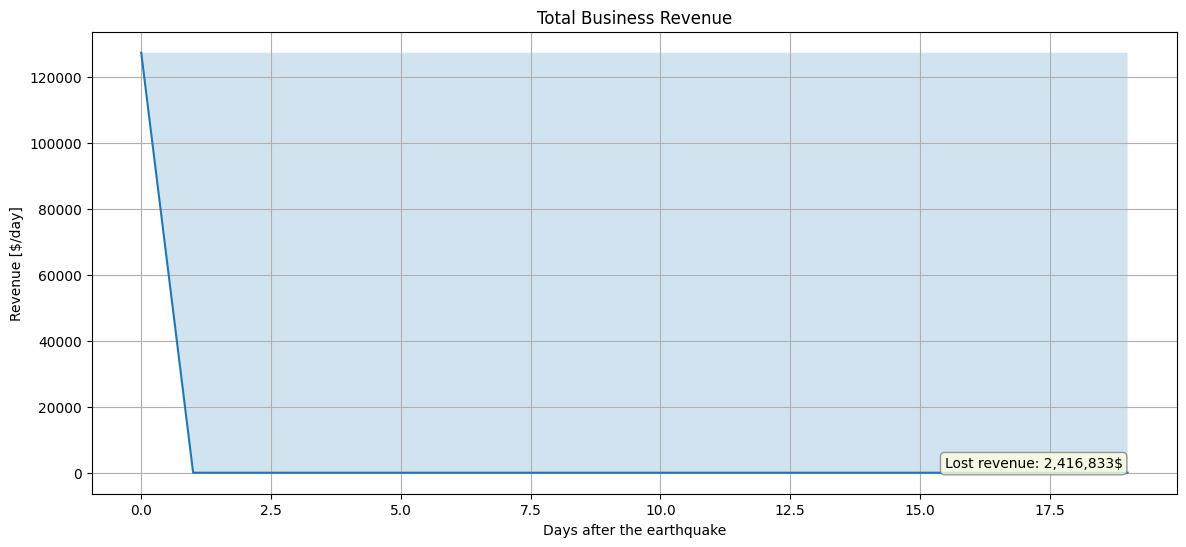

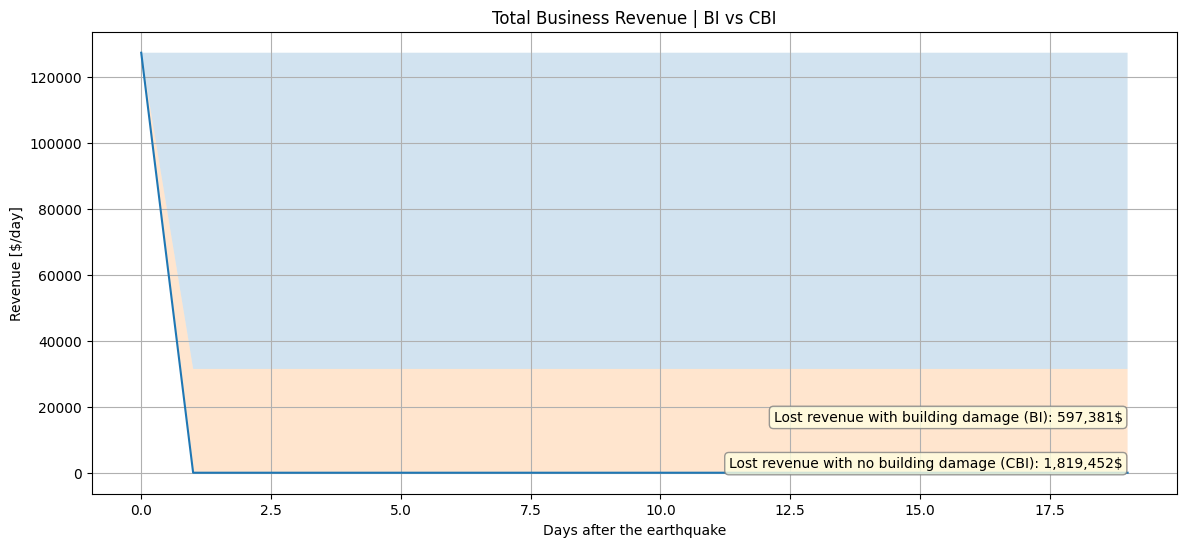

In [3]:
total_revenue = business_plotter.calculate_total_revenue(business_resilience_calculator)
total_revenue_no_building_damage = business_plotter.calculate_total_revenue_no_building_damage(business_resilience_calculator)
business_plotter.plot_total_revenue(total_revenue, show_fig=True, save_fig=False)
business_plotter.plot_total_revenue_BI_CBI(total_revenue, total_revenue_no_building_damage, show_fig=True, save_fig=False)


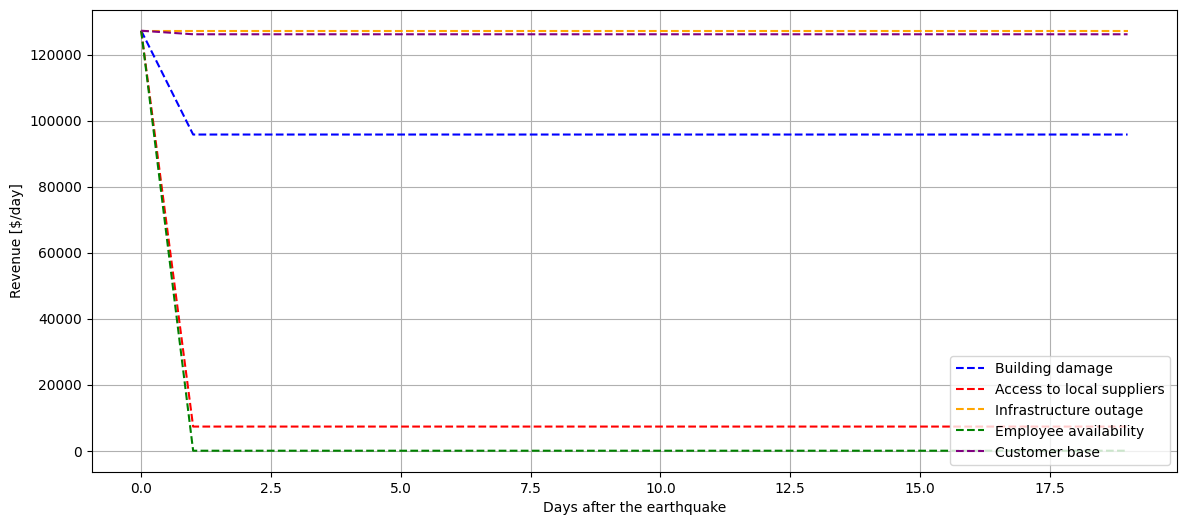

In [4]:
total_reasons_for_drop = business_plotter.get_total_reasons_for_drop(business_resilience_calculator.businesses)
total_reasons_as_lines = business_plotter.get_total_reasons_for_drop_as_lines(total_reasons_for_drop)

business_plotter.plot_total_revenue_reasons_for_drop_lines(total_reasons_as_lines, save_fig=False, show_fig=True)

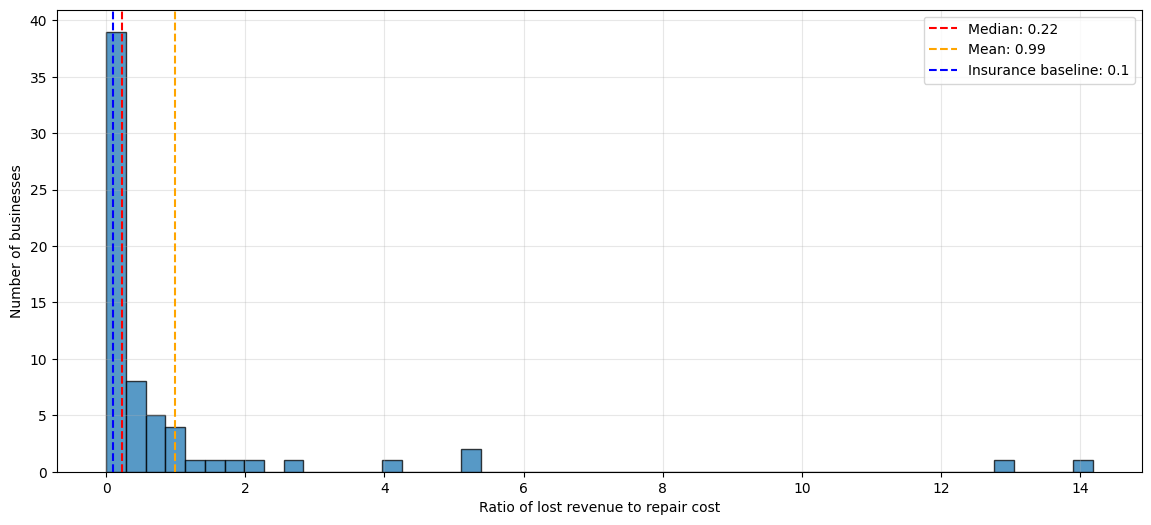

In [5]:
business_plotter.plot_lost_revenue_to_repair_cost_histogram(
    business_resilience_calculator.lost_revenue_to_repair_cost_ratio, bins=50, show_fig=True, save_fig=False
)